
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis

NI continuous (absolute): 15.569667 → 1077.636300 s
NP continuous (absolute): 15.555373 → 1077.622525 s

Canonical t0 = NP stream start = 15.555373 s (absolute)
NI stream starts +0.014294 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI sync pulses (bit 3): 1062
NP sync pulses (bit 0): 1062

Linear fit: t_NI = 1.000000009 * t_NP + -0.000001405
Residuals  mean=0.0000 ms  std=0.0327 ms  max=0.1348 ms

Saved alignment metadata.

Recording duration (canonical): 1062.067 s

===== SPIKE TIME ANCHOR DIAGNOSTIC =====
NI stream offset from NP start: +0.014294 s
First 5 spike times (raw, seconds from sample 0): [3.33333333e-05 6.66666667e-05 6.66666667e-05 1.00000000e-04
 1.33333333e-04]
Last  5 spike times (raw, seconds from sample 0): [1061.9585     1061.9595     1061.99856667 1061.99926667

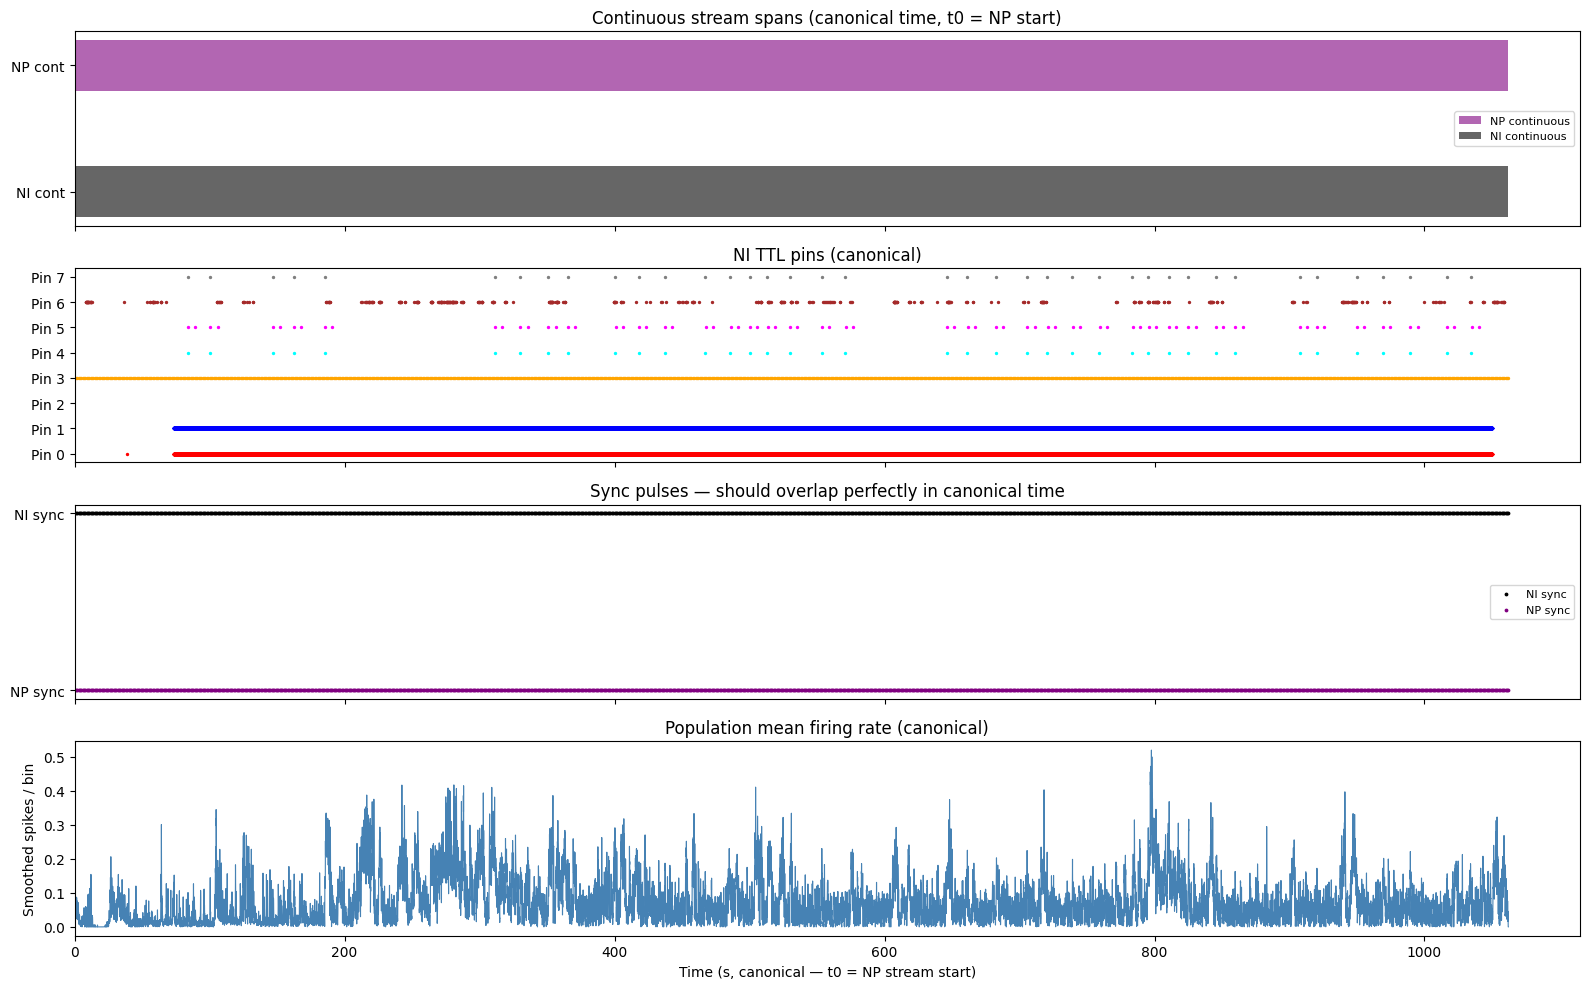

===== CELL A COMPLETE =====



In [16]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

SESSION_FOLDER = r"D:\Kevin\17032026"

NI_TTL_FOLDER = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\events\NI-DAQmx-106.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 1
EXPECTED_RATE_HZ = 60
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 3
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name            # NI-DAQmx-106.PXIe-6341
recording_root   = ni_ttl_folder.parents[2]             # .../experiment2/recording1
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent            # .../Neuropix-PXI-107.ProbeA

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================
# We use the NP continuous start as t0 (our ground truth).
# Everything — spikes, TTLs, DLC — will be expressed as seconds
# elapsed since the NP recording began.
#
# Why NP and not NI?
#   - Kilosort spike_times.npy is in NP samples from NP stream start.
#   - The NP stream is always the longest / most complete signal.
#   - All other signals get mapped into this frame.
# ============================================================

t0 = np_start_abs   # canonical zero = NP stream start (absolute clock)

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")
# Positive → NI started after NP (common if NP armed first)

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

np_ttl_folder     = recording_root / "events" / "Neuropix-PXI-107.ProbeA" / "TTL"
timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

# With a≈1 and b≈0 (same clock), the fit confirms the two streams share
# the OpenEphys master clock.  We still apply it for correctness in case
# there is any tiny drift.

# Save alignment metadata
align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================
# All downstream code should use these — never subtract t0 manually.

def np_samples_to_canonical(samples):
    """Kilosort spike_times (NP samples) → canonical seconds."""
    # samples / sample_rate  → seconds from NP stream start (already = t0)
    # No further offset needed because t0 IS np_start_abs and
    # OpenEphys sample indices start at the stream start.
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    """NP absolute time → canonical seconds."""
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    """NI absolute time → canonical seconds."""
    return t_ni_abs - t0

# Canonical duration = full NP recording
recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================
# Load spike_times.npy and check that the first and last spikes
# fall within [0, recording_duration].  If they fall within
# [-ni_start_rel, recording_duration - ni_start_rel] instead,
# that means Kilosort spike_times are in NI-absolute samples,
# and you need to subtract the NP stream start offset.
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0   # typically a small positive number

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

if abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif abs(spike_min - ni_start_rel) < 5.0:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
else:
    print(f"\n→ WARNING: spike anchor unclear. "
          f"spike_min={spike_min:.3f}, ni_start_rel={ni_start_rel:.6f}. "
          f"Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    """Full pipeline: NP samples → canonical seconds."""
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}   # canonical seconds

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{b_idx}", block_times)
    print(f"  Block {b_idx}: {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)  # canonical seconds

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

# Sample noise units matched to the number of good units
# (so downstream noise-vs-real comparisons have equal sample sizes)
    noise_units_all = df_info[df_info["group"] == "noise"]["id"].values
    print(f"Total noise units available: {len(noise_units_all)}")

# Filter noise units by minimum firing rate, same way good units would be
# filtered downstream. This ensures the noise pool we sample from is
# comparable in firing-rate distribution to the good pool.
    noise_rates = np.array([
        (spike_clusters == u).sum() / recording_duration
        for u in noise_units_all
    ])
    NOISE_MIN_RATE_HZ = 0.5  # matches a permissive floor; tightened downstream
    eligible_noise = noise_units_all[noise_rates >= NOISE_MIN_RATE_HZ]
    print(f"Noise units with ≥{NOISE_MIN_RATE_HZ} Hz: {len(eligible_noise)}")

# Sample N_target noise units matched to good unit count
    N_target = len(good_units)
    np.random.seed(0)
    if len(eligible_noise) >= N_target:
        sampled_noise = np.random.choice(eligible_noise, size=N_target, replace=False)
        print(f"Sampled {N_target} noise units (matched to good unit count).")
    else:
        sampled_noise = eligible_noise
        print(f"WARNING: only {len(eligible_noise)} eligible noise units available "
              f"(wanted {N_target}). Using all available.")

    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)
    print(f"Saved {len(sampled_noise)} noise unit spike trains to disk.")

    # Save spike anchor for downstream cells
    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    # Time bins over full NP recording
    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    # Rate matrices
    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Row 0: NP and NI continuous spans
for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pins
colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

# Row 2: sync pulses overlap check
ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

# Row 3: spike density
ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [17]:
# ============================================================
# CELL B — FRAME ALIGNMENT (RIG-ONLY) — CORRECTED
# ============================================================
# Camera behavior assumed (confirmed by Kevin):
#   - frame_idx resets to 0 each block; contiguous (no gaps)
#   - first saved frame == TTL #0 of the block
#   - cnt is a free-running counter (offset is arbitrary).
#     Drops show up as gaps in cnt.
#
# Mapping: saved frame at position p
#          → ttl_index_in_block = cnt[p] - cnt[0]
#          → canonical_time     = ttl_times_block[cnt[p] - cnt[0]]
# ============================================================
import os, re, json
import numpy as np
from pathlib import Path

print("\n===== CELL B — FRAME ALIGNMENT (RIG) =====")

required_vars = ["analysis_folder", "ttl_blocks", "FILENAME_PATTERN"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"'{v}' missing — run Cell A first.")

# ------------------------------------------------------------
# USER EDIT — camera folder per block
# ------------------------------------------------------------
CAM_FOLDERS = {
    0: r"D:\Kevin\17032026\17032026-4\cam2",
}
# ------------------------------------------------------------

if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError(f"CAM_FOLDERS has {len(CAM_FOLDERS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(CAM_FOLDERS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"CAM_FOLDERS keys must be {set(range(len(ttl_blocks)))}.")
for b, p in CAM_FOLDERS.items():
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Camera folder for block {b} missing: {p}")

PATTERN = re.compile(FILENAME_PATTERN)
cam_align_dir = analysis_folder / "camera_alignment"
cam_align_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# PROCESS EACH BLOCK
# ------------------------------------------------------------
for block_index, ttl_times_block in enumerate(ttl_blocks):

    print(f"\n--- Block {block_index} ---")
    cam_folder = CAM_FOLDERS[block_index]
    n_ttls = len(ttl_times_block)
    print(f"TTLs in block: {n_ttls}")
    print(f"Camera folder: {cam_folder}")

    # Scan filenames
    entries = []
    for fname in os.listdir(cam_folder):
        m = PATTERN.match(fname)
        if m:
            entries.append((int(m.group(1)), int(m.group(2)), fname))
    if not entries:
        raise RuntimeError(f"No matching files in {cam_folder}")

    entries.sort(key=lambda e: e[1])  # sort by cnt
    frame_idx_arr = np.array([e[0] for e in entries], dtype=np.int64)
    cnt_arr       = np.array([e[1] for e in entries], dtype=np.int64)

    n_saved   = len(entries)
    first_cnt = int(cnt_arr[0])
    last_cnt  = int(cnt_arr[-1])
    cnt_span  = last_cnt - first_cnt + 1   # TTLs covered by camera save window

    print(f"Saved frames: {n_saved}")
    print(f"frame_idx range: {int(frame_idx_arr[0])} → {int(frame_idx_arr[-1])}")
    print(f"cnt range: {first_cnt} → {last_cnt}")
    print(f"cnt span (TTLs covered by camera): {cnt_span}")
    print(f"Implied drops within camera window: {cnt_span - n_saved}")

    # ----- Invariant 1: first frame_idx must be 0 -----
    if int(frame_idx_arr[0]) != 0:
        raise RuntimeError(
            f"Block {block_index}: first saved frame has frame_idx="
            f"{int(frame_idx_arr[0])}, expected 0. Camera should reset "
            f"frame_idx to 0 at block start."
        )

    # ----- Invariant 2: frame_idx contiguous (no gaps) -----
    fidx_gaps = np.where(np.diff(frame_idx_arr) != 1)[0]
    if len(fidx_gaps) > 0:
        raise RuntimeError(
            f"Block {block_index}: frame_idx has gaps at positions "
            f"{fidx_gaps[:5].tolist()}{'...' if len(fidx_gaps) > 5 else ''}. "
            f"frame_idx should be contiguous; drops live in cnt only."
        )

    # ----- Invariant 3: cnt span fits within TTL block -----
    # The camera can stop saving before the last TTL (trailing TTLs are
    # benign). It must NOT extend past the TTL block.
    if cnt_span > n_ttls:
        raise RuntimeError(
            f"Block {block_index}: cnt span ({cnt_span}) exceeds TTL count "
            f"({n_ttls}). The camera appears to have received more TTLs "
            f"than the TTL detector found, which means the block "
            f"boundaries are wrong."
        )

    # ----- Invariant 4: how much TTL hangs off the end? Report it. -----
    trailing_ttls = n_ttls - cnt_span
    trailing_secs = (ttl_times_block[-1] - ttl_times_block[cnt_span - 1]
                     if cnt_span > 0 else 0.0)
    print(f"Trailing TTLs after camera stopped: {trailing_ttls} "
          f"(~{trailing_secs:.2f} s)")
    if trailing_ttls > n_ttls * 0.1:
        print(f"  WARNING: more than 10% of TTLs are trailing. "
              f"Check that you didn't stop the camera way before "
              f"stopping OpenEphys.")

    # ------------------------------------------------------------
    # CORE MAPPING
    # ------------------------------------------------------------
    # For each saved frame, compute its TTL index in the block
    # and look up the canonical time.
    # ------------------------------------------------------------
    ttl_idx_in_block = cnt_arr - first_cnt          # shape (n_saved,)
    frame_canonical_times = ttl_times_block[ttl_idx_in_block]

    # Sanity: monotonic increasing
    if not np.all(np.diff(frame_canonical_times) > 0):
        raise RuntimeError(
            f"Block {block_index}: frame canonical times are not strictly "
            f"increasing. This indicates a sorting or cnt error."
        )

    # ------------------------------------------------------------
    # SAVE PORTABLE ARRAYS
    # ------------------------------------------------------------
    np.save(cam_align_dir / f"frame_cnt_block{block_index}.npy", cnt_arr)
    np.save(cam_align_dir / f"frame_canonical_times_block{block_index}.npy",
            frame_canonical_times)

    print(f"Wrote frame_cnt_block{block_index}.npy "
          f"and frame_canonical_times_block{block_index}.npy")
    print(f"Frame canonical time range: "
          f"{frame_canonical_times[0]:.3f} → {frame_canonical_times[-1]:.3f} s")

# ------------------------------------------------------------
# Save frame-alignment metadata
# ------------------------------------------------------------
frame_meta = {
    str(b): {
        "cam_folder": CAM_FOLDERS[b],
        "n_saved_frames": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy").size),
        "n_ttls": int(len(ttl_blocks[b])),
        "first_cnt": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[0]),
        "last_cnt":  int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[-1]),
    }
    for b in range(len(ttl_blocks))
}
with open(analysis_folder / "metadata" / "frame_alignment.json", "w") as f:
    json.dump(frame_meta, f, indent=2)

print("\n===== CELL B COMPLETE — RIG WORK DONE =====")
print("Everything below this point is portable.\n")


===== CELL B — FRAME ALIGNMENT (RIG) =====

--- Block 0 ---
TTLs in block: 58547
Camera folder: D:\Kevin\17032026\17032026-4\cam2
Saved frames: 53839
frame_idx range: 0 → 53838
cnt range: 60712 → 119257
cnt span (TTLs covered by camera): 58546
Implied drops within camera window: 4707
Trailing TTLs after camera stopped: 1 (~0.02 s)
Wrote frame_cnt_block0.npy and frame_canonical_times_block0.npy
Frame canonical time range: 73.526 → 1049.861 s

===== CELL B COMPLETE — RIG WORK DONE =====
Everything below this point is portable.



In [3]:
# ============================================================
# OPTO ARTIFACT BLANKING USING VIDEO LED DETECTION
# ============================================================
# Standalone version: doesn't require Cell B (camera alignment).
# Uses raw camera TTLs directly to map video frame → canonical time.
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import json

print("\n===== OPTO ARTIFACT BLANKING (VIDEO LED DETECTION) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
RESULTS_CSV = r"C:\Users\kkost\Downloads\Results.csv"

# Continuous.dat to blank
CONTINUOUS_DAT_PATH = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\continuous.dat"

# Analysis folder (has TTL files from Cell A)
ANALYSIS_FOLDER = r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis"

# Camera TTL pin used during this session
CAMERA_TTL_PIN = 0

# Opto detection threshold
LED_THRESHOLD = 200

# Safety padding around each transition
SAFETY_PAD_MS = 25

# Whether to blank the sustained light-on period too
BLANK_SUSTAINED = False  # True = blanks light delivery window; False = preserves it

# Neuropixels params
N_CHANNELS = 384
NP_SAMPLE_RATE = 30000.0

BLANKING_METHOD = 'zero'
# ------------------------------------------------------------

dat_path = Path(CONTINUOUS_DAT_PATH)
analysis_folder = Path(ANALYSIS_FOLDER)
out_path = dat_path.parent / "continuous_blanked.dat"

# ============================================================
# 1. DETECT OPTO-ON FRAMES FROM CSV
# ============================================================
print(f"\nLoading LED fluorescence from {Path(RESULTS_CSV).name}...")
df = pd.read_csv(RESULTS_CSV)
fluor = df['Mean1'].values
print(f"Total video frames: {len(fluor)}")

opto_on = fluor > LED_THRESHOLD
transitions = np.diff(opto_on.astype(int))
onset_frames_video = np.where(transitions == 1)[0] + 1
offset_frames_video = np.where(transitions == -1)[0] + 1

print(f"\nDetected {len(onset_frames_video)} opto onsets, "
      f"{len(offset_frames_video)} offsets")
for i, (on, off) in enumerate(zip(onset_frames_video, offset_frames_video)):
    print(f"  Pulse {i+1}: video frames {on} → {off} ({off-on} frames)")

# ============================================================
# 2. LOAD CAMERA TTLs (canonical time per camera frame)
# ============================================================
print(f"\nLoading camera TTLs from pin {CAMERA_TTL_PIN}...")
camera_ttls_path = analysis_folder / "ttls" / f"TTL_Pin_{CAMERA_TTL_PIN}.npy"
camera_ttls = np.load(camera_ttls_path)
print(f"  Loaded {len(camera_ttls)} camera TTLs")
print(f"  Range: {camera_ttls[0]:.3f} → {camera_ttls[-1]:.3f} s (canonical)")

# Cell A reported "Skipping block 0 (too short: 1)" — the first TTL is a stray.
# So camera frame N corresponds to camera_ttls[N+1] if we skip the stray.
# Let's verify by checking inter-TTL intervals.
ipi = np.diff(camera_ttls[:5])
print(f"  First few IPIs (ms): {ipi*1000}")

# The stray TTL at index 0 has a huge gap before the real block starts.
# Find the first "real" TTL (large gap before it = end of stray, start of block)
ipi_all = np.diff(camera_ttls)
gap_threshold = 1.0  # 1 second gap = block boundary
first_block_idx = np.argmax(ipi_all > gap_threshold) + 1 if (ipi_all > gap_threshold).any() else 0
print(f"  Skipping {first_block_idx} stray TTL(s) before main block")

# Camera TTLs in the main block
camera_ttls_block = camera_ttls[first_block_idx:]
print(f"  Main block: {len(camera_ttls_block)} TTLs, "
      f"{camera_ttls_block[0]:.3f} → {camera_ttls_block[-1]:.3f} s")

# ============================================================
# 3. MAP VIDEO FRAMES → CANONICAL TIME
# ============================================================
n_video_frames = len(fluor)
n_camera_ttls = len(camera_ttls_block)
print(f"\nVideo frames: {n_video_frames}, camera TTLs in block: {n_camera_ttls}")

if n_video_frames != n_camera_ttls:
    print(f"  ⚠ Mismatch. Likely camera-dropped frames or video has extra frames.")
    n_use = min(n_video_frames, n_camera_ttls)
    print(f"  Using first {n_use} frames for alignment.")
else:
    n_use = n_video_frames
    print(f"  ✓ Counts match exactly.")

# Validate opto frames are within usable range
onset_frames_valid = [f for f in onset_frames_video if f < n_use]
offset_frames_valid = [f for f in offset_frames_video if f < n_use]
n_valid = min(len(onset_frames_valid), len(offset_frames_valid))
onset_frames_valid = onset_frames_valid[:n_valid]
offset_frames_valid = offset_frames_valid[:n_valid]

# Map to canonical time
onset_times_can = camera_ttls_block[onset_frames_valid]
offset_times_can = camera_ttls_block[offset_frames_valid]

print(f"\nOpto pulse canonical times:")
for i, (t_on, t_off) in enumerate(zip(onset_times_can, offset_times_can)):
    print(f"  Pulse {i+1}: {t_on:.3f}s → {t_off:.3f}s "
          f"(duration {t_off - t_on:.3f}s)")

# ============================================================
# 4. CANONICAL TIME → DAT SAMPLE INDICES
# ============================================================
probe_cont = dat_path.parent
timestamps = np.load(probe_cont / "timestamps.npy")
dat_first_sample_time = timestamps[0]

with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
t0_abs = ttl_meta["t0_abs"]

print(f"\nDat file sample 0 absolute time: {dat_first_sample_time:.6f}s")
print(f"Canonical t0 absolute time:      {t0_abs:.6f}s")
offset_samples = (t0_abs - dat_first_sample_time) * NP_SAMPLE_RATE
print(f"Offset (samples): {offset_samples:.0f}")

def canonical_to_sample(t_can):
    t_abs = t_can + t0_abs
    return int(round((t_abs - dat_first_sample_time) * NP_SAMPLE_RATE))

pad_samples = int(SAFETY_PAD_MS / 1000 * NP_SAMPLE_RATE)
n_samples_total = len(timestamps)

blank_windows = []
for t_on, t_off in zip(onset_times_can, offset_times_can):
    on_sample = canonical_to_sample(t_on)
    off_sample = canonical_to_sample(t_off)

    # Onset transient
    blank_windows.append((max(0, on_sample - pad_samples),
                          min(n_samples_total, on_sample + pad_samples)))
    # Offset transient
    blank_windows.append((max(0, off_sample - pad_samples),
                          min(n_samples_total, off_sample + pad_samples)))

    if BLANK_SUSTAINED:
        blank_windows.append((on_sample, off_sample))

# Merge overlapping
blank_windows.sort()
merged = [blank_windows[0]]
for s, e in blank_windows[1:]:
    if s <= merged[-1][1]:
        merged[-1] = (merged[-1][0], max(merged[-1][1], e))
    else:
        merged.append((s, e))
blank_windows = merged

print(f"\nFinal blanking windows: {len(blank_windows)}")
total_blanked = sum(e - s for s, e in blank_windows)
print(f"Total samples to blank: {total_blanked:,} "
      f"({total_blanked / n_samples_total * 100:.2f}% of recording)")
print(f"Total time blanked: {total_blanked / NP_SAMPLE_RATE:.3f}s")
print(f"Sustained light period: {'BLANKED' if BLANK_SUSTAINED else 'PRESERVED'}")

print("\nWindows (canonical time):")
for s, e in blank_windows:
    t_s = timestamps[s] - t0_abs if s < n_samples_total else None
    t_e = timestamps[e-1] - t0_abs if e-1 < n_samples_total else None
    print(f"  samples {s} → {e}  =  canonical {t_s:.3f}s → {t_e:.3f}s "
          f"(dur {(e-s)/NP_SAMPLE_RATE*1000:.1f} ms)")

# ============================================================
# 5. APPLY BLANKING TO COPY OF DAT FILE
# ============================================================
print(f"\nCopying {dat_path.name} → {out_path.name}...")
print(f"  Size: {dat_path.stat().st_size / 1e9:.2f} GB")
shutil.copy2(dat_path, out_path)
print("Copy complete.")

print(f"\nApplying blanking ({BLANKING_METHOD})...")
data = np.memmap(out_path, dtype=np.int16, mode='r+',
                  shape=(n_samples_total, N_CHANNELS))

for s, e in blank_windows:
    if BLANKING_METHOD == 'zero':
        data[s:e, :] = 0
    elif BLANKING_METHOD == 'noise':
        ref_start = max(0, s - 30000)
        ref_data = data[ref_start:s, :]
        ch_std = np.clip(ref_data.std(axis=0).astype(np.float32), 1, None)
        noise = (np.random.randn(e - s, N_CHANNELS) * ch_std).astype(np.int16)
        data[s:e, :] = noise

data.flush()
del data

print(f"\nDone. Blanked file: {out_path}")
print(f"\nNext steps:")
print(f"  1. Verify blanking visually (use the verification cell)")
print(f"  2. Backup original: rename {dat_path.name} → continuous_original.dat")
print(f"  3. Rename {out_path.name} → continuous.dat")
print(f"  4. Re-run Kilosort on the blanked file")
print(f"  5. Curate in Phy")
print(f"  6. Re-run the full pipeline from Cell A")


===== OPTO ARTIFACT BLANKING (VIDEO LED DETECTION) =====

Loading LED fluorescence from Results.csv...
Total video frames: 53839

Detected 5 opto onsets, 5 offsets
  Pulse 1: video frames 21816 → 22117 (301 frames)
  Pulse 2: video frames 26394 → 26695 (301 frames)
  Pulse 3: video frames 32485 → 32786 (301 frames)
  Pulse 4: video frames 33399 → 33700 (301 frames)
  Pulse 5: video frames 49480 → 49780 (300 frames)

Loading camera TTLs from pin 0...
  Loaded 58549 camera TTLs
  Range: 38.663 → 1049.895 s (canonical)
  First few IPIs (ms): [3.48623667e+04 1.67000000e+01 1.66666667e+01 1.66666667e+01]
  Skipping 1 stray TTL(s) before main block
  Main block: 58548 TTLs, 73.526 → 1049.895 s

Video frames: 53839, camera TTLs in block: 58548
  ⚠ Mismatch. Likely camera-dropped frames or video has extra frames.
  Using first 53839 frames for alignment.

Opto pulse canonical times:
  Pulse 1: 437.344s → 442.364s (duration 5.020s)
  Pulse 2: 513.690s → 518.709s (duration 5.020s)
  Pulse 3: 61

In [18]:
# ============================================================
# CELL C — SESSION BUILDER (PORTABLE)
# ============================================================
# First cell after the rig/home line. Defines DLC paths and
# writes session.json with all metadata needed for downstream
# analysis. Loads ttl_blocks etc. from disk if not in kernel.
# ============================================================
import os, json
import numpy as np
from pathlib import Path

print("\n===== CELL C — SESSION BUILDER (PORTABLE) =====")

# ------------------------------------------------------------
# USER EDIT — set analysis_folder if running on home machine
# ------------------------------------------------------------
# If you've just opened this notebook fresh on your home laptop,
# uncomment and edit this line:
#analysis_folder = Path(r")
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set `analysis_folder` (Path to the analysis folder).")
analysis_folder = Path(analysis_folder)

# ------------------------------------------------------------
# USER EDIT — DLC outputs per block
# ------------------------------------------------------------
DLC_OUTPUTS = {
    0: r"F:\031726-cam1-Kevin-2026-05-26\031726_cam2-Kevin-2026-05-26\videos\17032026-4_cam2DLC_Resnet50_031726_cam2May26shuffle1_snapshot_200.h5",
}
# ------------------------------------------------------------

# Pin labels — bake into session so downstream plots auto-label
PIN_LABELS = {
    0: "camera1",
    1: "camera2",
    3: "sync_pulse",   # 2 turns/trial: expose + retract
    4: "tone_cue",
    5: "motor",
    6: "reach_ir_beam",
    7: "manual_pellet_button",
}
CAMERA_TTL_PIN = 1  # this session uses cam1 #####################################################################################################################################

# ------------------------------------------------------------
# LOAD CELL A METADATA FROM DISK
# ------------------------------------------------------------
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)
with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
with open(analysis_folder / "metadata" / "block_info.json") as f:
    block_info = json.load(f)
with open(analysis_folder / "metadata" / "frame_alignment.json") as f:
    frame_meta = json.load(f)

# ------------------------------------------------------------
# RELOAD ttl_blocks AND all_pin_ttls FROM DISK IF NEEDED
# ------------------------------------------------------------
cam_align_dir = analysis_folder / "camera_alignment"
ttls_dir = analysis_folder / "ttls"

ttl_blocks = []
for bi in block_info:
    idx = bi["block_index"]
    ttl_blocks.append(np.load(cam_align_dir / f"ttl_times_block{idx}.npy"))

all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# ------------------------------------------------------------
# VALIDATE DLC MAPPING
# ------------------------------------------------------------
if len(DLC_OUTPUTS) != len(ttl_blocks):
    raise ValueError(f"DLC_OUTPUTS has {len(DLC_OUTPUTS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(DLC_OUTPUTS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"DLC_OUTPUTS keys must be {set(range(len(ttl_blocks)))}.")
for b, path in DLC_OUTPUTS.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(f"DLC file for block {b} missing: {path}")

# ------------------------------------------------------------
# BUILD SESSION OBJECT
# ------------------------------------------------------------
session = {
    "canonical_t0_abs":         align_meta["t0_abs"],
    "canonical_t0_description": "NP stream start (absolute OpenEphys clock seconds)",
    "recording_duration_s":     ttl_meta["recording_duration"],
    "spike_anchor_offset_s":    ttl_meta["spike_anchor_offset_s"],
    "np_to_ni_a":               align_meta["np_to_ni_a"],
    "np_to_ni_b":               align_meta["np_to_ni_b"],
    "camera_ttl_pin":           CAMERA_TTL_PIN,
    "pin_labels":               PIN_LABELS,
    "blocks": []
}

for block_index, ttl_times_block in enumerate(ttl_blocks):
    fm = frame_meta[str(block_index)]
    session["blocks"].append({
        "block_index":              block_index,
        "n_ttls":                   int(len(ttl_times_block)),
        "n_saved_frames":           int(fm["n_saved_frames"]),
        "start_canonical":          float(ttl_times_block[0]),
        "end_canonical":            float(ttl_times_block[-1]),
        "ttl_times_path":           str(cam_align_dir / f"ttl_times_block{block_index}.npy"),
        "frame_cnt_path":           str(cam_align_dir / f"frame_cnt_block{block_index}.npy"),
        "frame_canonical_times_path": str(cam_align_dir / f"frame_canonical_times_block{block_index}.npy"),
        "dlc_path":                 DLC_OUTPUTS[block_index],
        "dlc_canonical_path":       str(analysis_folder / "dlc_alignment" / f"dlc_canonical_block{block_index}.npz"),
    })

session_path = analysis_folder / "metadata" / "session.json"
with open(session_path, "w") as f:
    json.dump(session, f, indent=2)

print(f"Saved session.json → {session_path}")
print(f"\nSession summary:")
print(f"  canonical t0 (abs):  {session['canonical_t0_abs']:.6f} s")
print(f"  recording duration:  {session['recording_duration_s']:.3f} s")
print(f"  spike_anchor_offset: {session['spike_anchor_offset_s']:.6f} s")
print(f"  camera TTL pin:      {session['camera_ttl_pin']}")
for b in session["blocks"]:
    print(f"  Block {b['block_index']}: {b['n_ttls']} TTLs, "
          f"{b['n_saved_frames']} saved frames, "
          f"{b['start_canonical']:.3f} → {b['end_canonical']:.3f} s")

print("\n===== CELL C COMPLETE =====\n")


===== CELL C — SESSION BUILDER (PORTABLE) =====
Saved session.json → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\metadata\session.json

Session summary:
  canonical t0 (abs):  15.555373 s
  recording duration:  1062.067 s
  spike_anchor_offset: 0.000000 s
  camera TTL pin:      1
  Block 0: 58547 TTLs, 53839 saved frames, 73.526 → 1049.878 s

===== CELL C COMPLETE =====



In [19]:
# ============================================================
# CELL D — DLC ↔ CANONICAL ALIGNMENT (PORTABLE)
# ============================================================
# For each block, reads the DLC .h5 (one row per saved frame in
# MP4 order, matches frame_idx because frame_idx is contiguous)
# and writes dlc_canonical_block{N}.npz containing:
#   canonical_time   : (n_saved,) float64
#   bodyparts        : list of bodypart names
#   {bp}_x, {bp}_y, {bp}_likelihood : (n_saved,) float32 each
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("\n===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Run Cell C first (or set analysis_folder).")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

dlc_dir = analysis_folder / "dlc_alignment"
dlc_dir.mkdir(exist_ok=True)

for block in session["blocks"]:
    b = block["block_index"]
    print(f"\n--- Block {b} ---")

    frame_can_times = np.load(block["frame_canonical_times_path"])
    n_saved = len(frame_can_times)
    print(f"Saved frames (from frame_canonical_times): {n_saved}")

    dlc_path = Path(block["dlc_path"])
    print(f"Loading DLC: {dlc_path.name}")
    df = pd.read_hdf(dlc_path)
    n_rows = len(df)
    print(f"DLC rows: {n_rows}")

    if n_rows != n_saved:
        raise RuntimeError(
            f"Block {b}: DLC has {n_rows} rows but {n_saved} frames were "
            f"saved. They must match (DLC processes saved frames in order). "
            f"Common causes: DLC was run on a different video, or some "
            f"frames were trimmed before DLC."
        )

    # MultiIndex: (scorer, bodypart, coord). Pull bodyparts list.
    bodyparts = list(dict.fromkeys(df.columns.get_level_values("bodyparts")))
    print(f"Bodyparts found: {bodyparts}")

    out = {"canonical_time": frame_can_times.astype(np.float64),
           "bodyparts": np.array(bodyparts)}

    scorer = df.columns.get_level_values("scorer")[0]
    for bp in bodyparts:
        out[f"{bp}_x"]          = df[(scorer, bp, "x")].to_numpy(dtype=np.float32)
        out[f"{bp}_y"]          = df[(scorer, bp, "y")].to_numpy(dtype=np.float32)
        out[f"{bp}_likelihood"] = df[(scorer, bp, "likelihood")].to_numpy(dtype=np.float32)

    out_path = Path(block["dlc_canonical_path"])
    np.savez(out_path, **out)
    print(f"Saved → {out_path.name}")
    print(f"Time range: {frame_can_times[0]:.3f} → {frame_can_times[-1]:.3f} s")

print("\n===== CELL D COMPLETE =====\n")


===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====

--- Block 0 ---
Saved frames (from frame_canonical_times): 53839
Loading DLC: 17032026-4_cam2DLC_Resnet50_031726_cam2May26shuffle1_snapshot_200.h5
DLC rows: 53839
Bodyparts found: ['paw', 'digit1', 'digit2', 'nose']
Saved → dlc_canonical_block0.npz
Time range: 73.526 → 1049.861 s

===== CELL D COMPLETE =====



In [20]:
# ============================================================
# CELL E — FULL-SESSION DLC TRAJECTORY BUILDER (PORTABLE)
# ============================================================
# Concatenates per-block DLC into one full-session .npz:
#   full_session_dlc.npz
#     canonical_time   : (n_total_saved,)
#     block_index      : (n_total_saved,)
#     {bp}_x, {bp}_y, {bp}_likelihood for each bodypart
#
# After this, NO downstream cell needs to touch DLC .h5 files
# or per-block .npz files. Everything loads from this one file.
# ============================================================
import json
import numpy as np
from pathlib import Path

print("\n===== CELL E — FULL-SESSION DLC BUILDER =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# Load block 0 first to learn the bodypart list
b0 = session["blocks"][0]
d0 = np.load(b0["dlc_canonical_path"], allow_pickle=True)
bodyparts = [str(x) for x in d0["bodyparts"]]
print(f"Bodyparts: {bodyparts}")

# Concatenate
all_t      = []
all_block  = []
all_data   = {f"{bp}_{coord}": []
              for bp in bodyparts
              for coord in ["x", "y", "likelihood"]}

for block in session["blocks"]:
    b = block["block_index"]
    d = np.load(block["dlc_canonical_path"], allow_pickle=True)
    n = len(d["canonical_time"])
    print(f"  Block {b}: {n} frames, "
          f"{d['canonical_time'][0]:.3f} → {d['canonical_time'][-1]:.3f} s")

    all_t.append(d["canonical_time"])
    all_block.append(np.full(n, b, dtype=np.int16))
    for bp in bodyparts:
        for coord in ["x", "y", "likelihood"]:
            all_data[f"{bp}_{coord}"].append(d[f"{bp}_{coord}"])

out = {
    "canonical_time": np.concatenate(all_t),
    "block_index":    np.concatenate(all_block),
    "bodyparts":      np.array(bodyparts),
}
for k, v in all_data.items():
    out[k] = np.concatenate(v)

out_path = analysis_folder / "dlc_alignment" / "full_session_dlc.npz"
np.savez(out_path, **out)
print(f"\nSaved → {out_path}")
print(f"Total frames: {len(out['canonical_time'])}")
print(f"Time range: {out['canonical_time'][0]:.3f} → {out['canonical_time'][-1]:.3f} s")
print("\n===== CELL E COMPLETE =====\n")


===== CELL E — FULL-SESSION DLC BUILDER =====
Bodyparts: ['paw', 'digit1', 'digit2', 'nose']
  Block 0: 53839 frames, 73.526 → 1049.861 s

Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\dlc_alignment\full_session_dlc.npz
Total frames: 53839
Time range: 73.526 → 1049.861 s

===== CELL E COMPLETE =====




===== CELL F — SANITY PLOTS =====


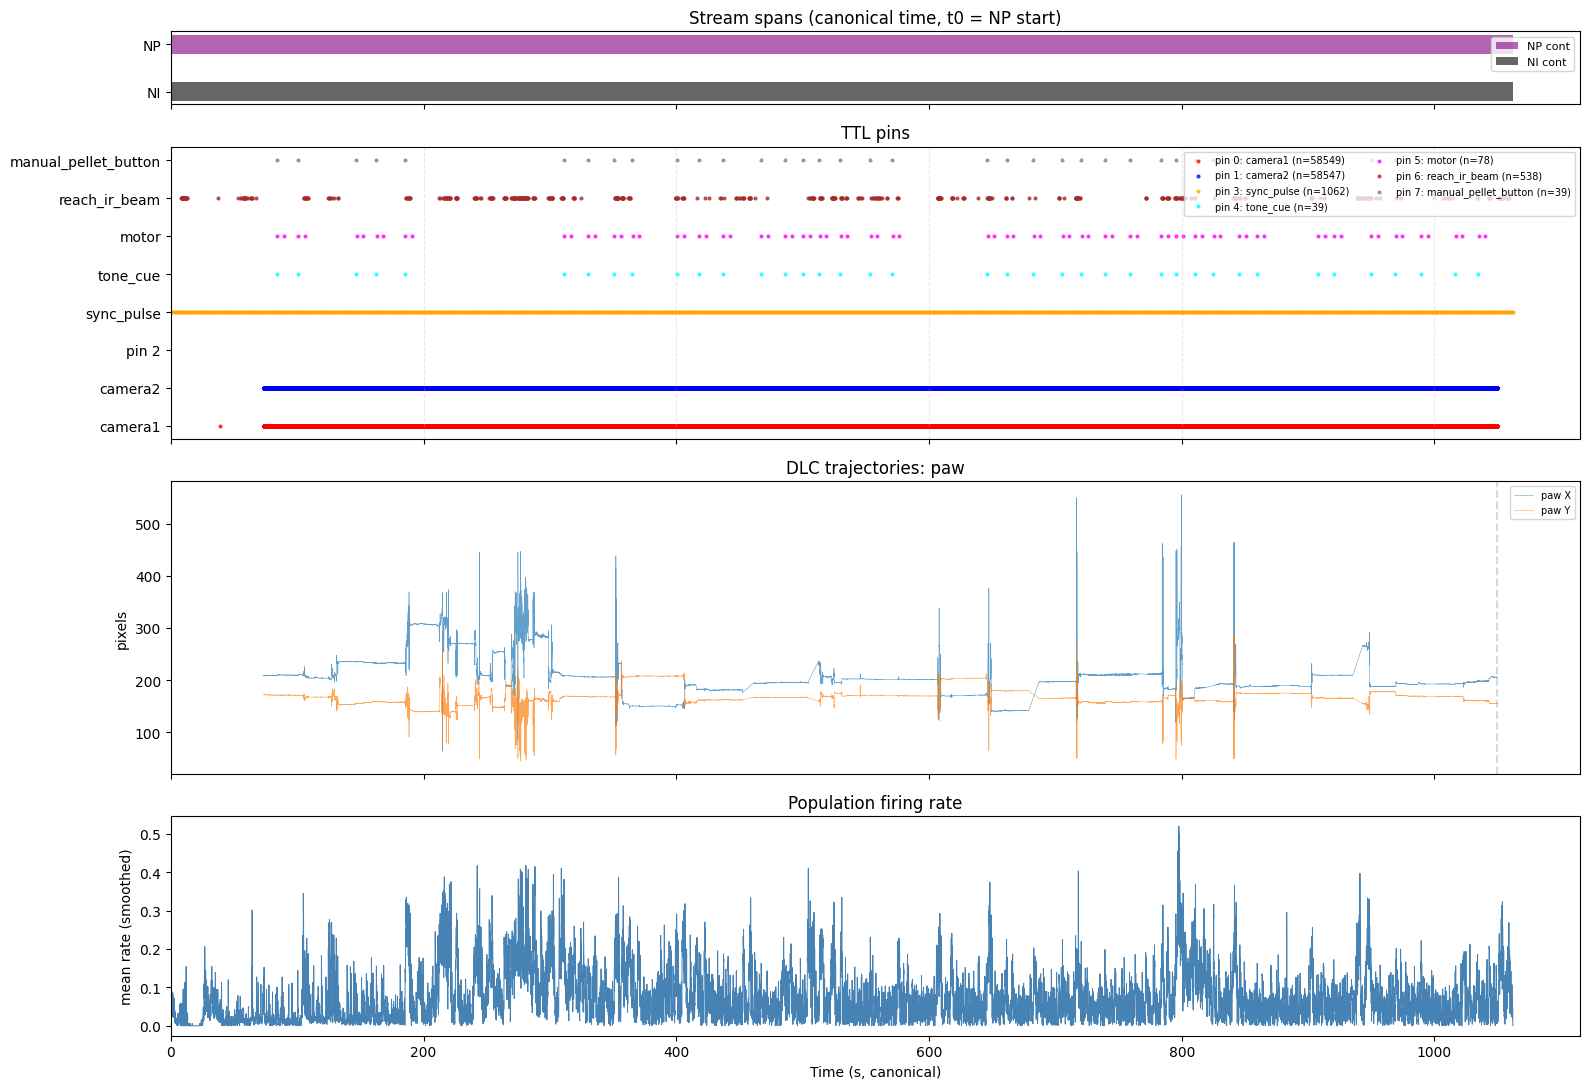


Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\camera_alignment\sanity_overview_1.png

===== CELL F COMPLETE =====



In [21]:
# ============================================================
# CELL F — SANITY PLOTS (PORTABLE)
# ============================================================
# One figure with: TTL pins raster, frame saved/dropped bar,
# DLC trajectory for selected bodyparts, NP/NI spans.
# Loads only from analysis_folder/ — no raw data needed.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL F — SANITY PLOTS =====")

# ------------------------------------------------------------
# USER EDIT — which bodyparts to overlay
# ------------------------------------------------------------
PLOT_BODYPARTS = ["paw"]
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)

pin_labels = session["pin_labels"]
rec_dur    = session["recording_duration_s"]
ni_start   = align_meta["ni_start_rel"]
ni_end     = align_meta["ni_end_rel"]

# Load all TTL pins
ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# Load full-session DLC
dlc_npz = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc_npz["canonical_time"]

# Load population firing-rate trace
centers = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
pop_rate = rate_matrix.mean(axis=0)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={"height_ratios": [0.5, 2, 2, 1.5]})

# Row 0: NP / NI stream spans
ax = axes[0]
ax.barh(1, rec_dur, left=0, height=0.4, color="purple", alpha=0.6, label="NP cont")
ax.barh(0, ni_end - ni_start, left=ni_start, height=0.4, color="black", alpha=0.6, label="NI cont")
ax.set_yticks([0, 1]); ax.set_yticklabels(["NI", "NP"])
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pin raster, color-coded with labels
ax = axes[1]
colors = ['red','blue','green','orange','cyan','magenta','brown','gray']
for pin in range(8):
    t = all_pin_ttls[pin]
    if len(t) == 0:
        continue
    label = pin_labels.get(str(pin), pin_labels.get(pin, f"pin {pin}"))
    ax.scatter(t, np.full_like(t, pin), s=4, color=colors[pin], alpha=0.7,
               label=f"pin {pin}: {label} (n={len(t)})")
ax.set_yticks(range(8))
ax.set_yticklabels([pin_labels.get(str(p), pin_labels.get(p, f"pin {p}"))
                    for p in range(8)])
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.set_title("TTL pins")
ax.grid(True, axis="x", linestyle="--", alpha=0.3)

# Row 2: DLC traces
ax = axes[2]
for bp in PLOT_BODYPARTS:
    if f"{bp}_x" not in dlc_npz.files:
        print(f"  WARNING: bodypart '{bp}' not in DLC file.")
        continue
    ax.plot(dlc_t, dlc_npz[f"{bp}_x"], lw=0.4, alpha=0.7, label=f"{bp} X")
    ax.plot(dlc_t, dlc_npz[f"{bp}_y"], lw=0.4, alpha=0.7, label=f"{bp} Y")
# block boundaries
for block in session["blocks"]:
    ax.axvline(block["end_canonical"], color="gray", linestyle="--", alpha=0.3)
ax.set_ylabel("pixels")
ax.legend(fontsize=7, loc="upper right")
ax.set_title(f"DLC trajectories: {', '.join(PLOT_BODYPARTS)}")

# Row 3: population firing rate
ax = axes[3]
ax.plot(centers, pop_rate, color="steelblue", lw=0.7)
ax.set_ylabel("mean rate (smoothed)")
ax.set_title("Population firing rate")
ax.set_xlabel("Time (s, canonical)")

plt.tight_layout()

# Save
save_dir = analysis_folder / "camera_alignment"
save_path = save_dir / "sanity_overview.png"
i = 1
while save_path.exists():
    save_path = save_dir / f"sanity_overview_{i}.png"; i += 1
fig.savefig(save_path, dpi=200)
plt.show()
print(f"\nSaved → {save_path}")
print("\n===== CELL F COMPLETE =====\n")


===== CELL G — PERI-EVENT DIAGNOSTIC =====
Event pin 4 (tone_cue): 39 TTLs

===== EVENT REFERENCE TABLE =====
  # |  canonical (s) | block | video frame | video time (s) | lookup err (ms)
--------------------------------------------------------------------------------
  1 |         83.919 |     0 |         623 |         10.383 |             3.9
  2 |        100.341 |     0 |        1608 |         26.800 |             0.3
  3 |        146.765 |     0 |        4392 |         73.200 |             4.5
  4 |        162.547 |     0 |        5338 |         88.967 |             1.3
  5 |        185.364 |     0 |        6706 |        111.767 |             4.8
  6 |        311.070 |     0 |       14244 |        237.400 |             2.2
  7 |        330.005 |     0 |       15380 |        256.333 |             7.8
  8 |        350.792 |     0 |       16626 |        277.100 |             0.6



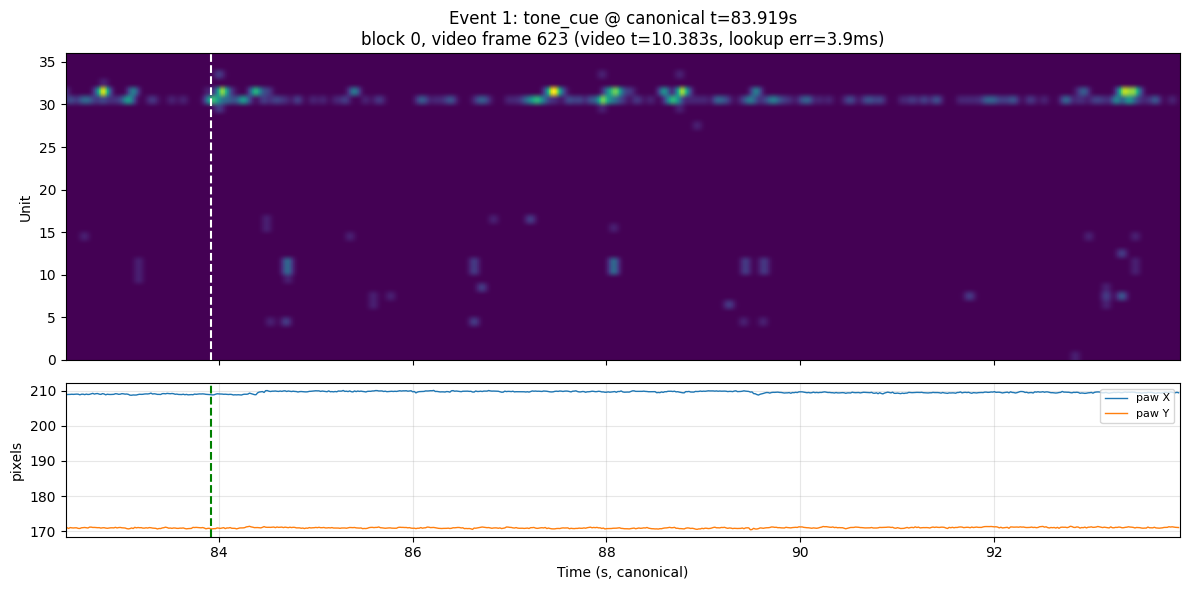

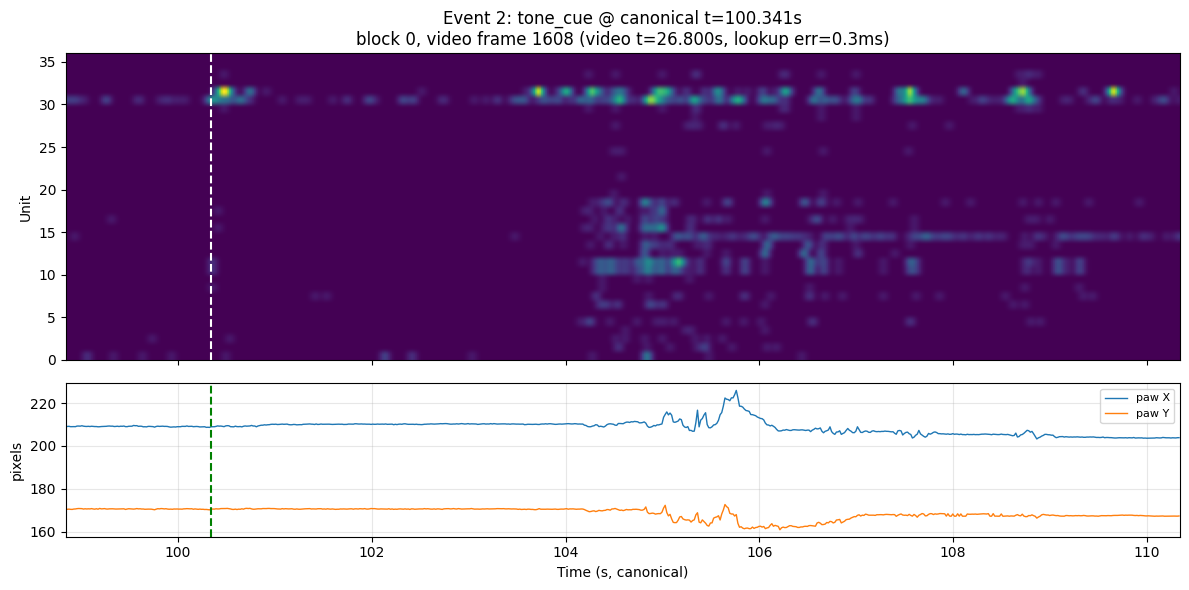

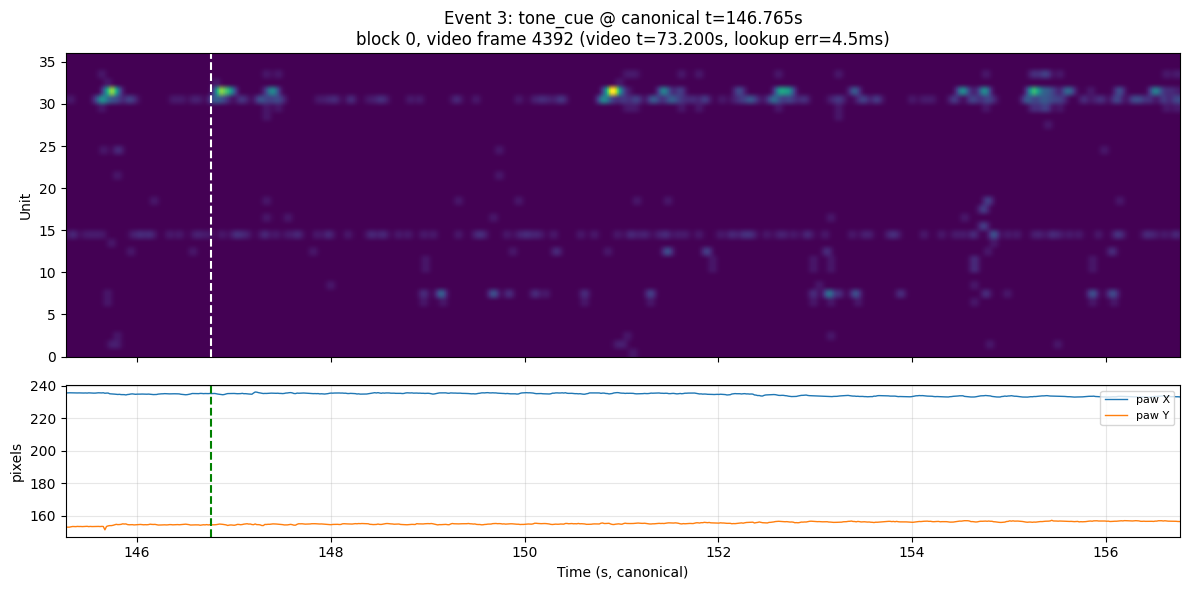

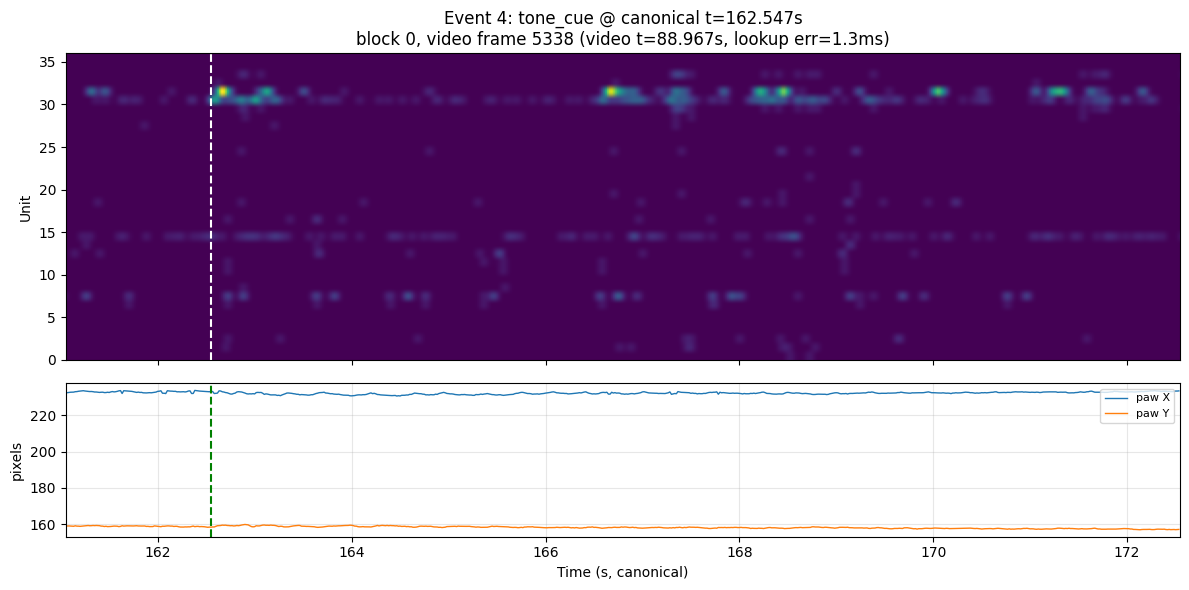

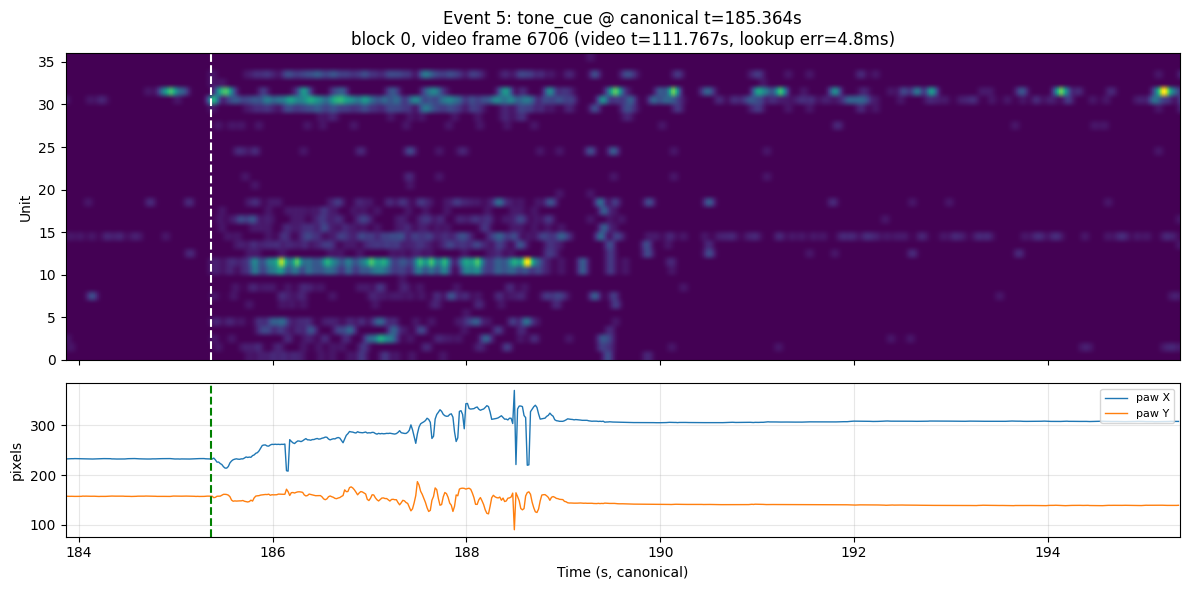

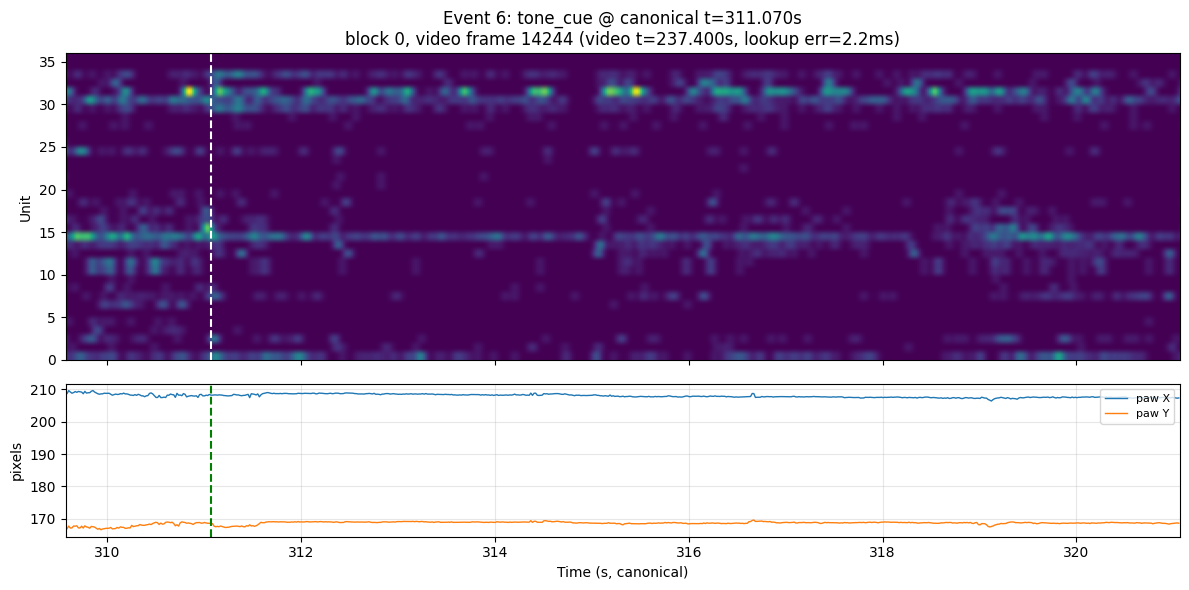

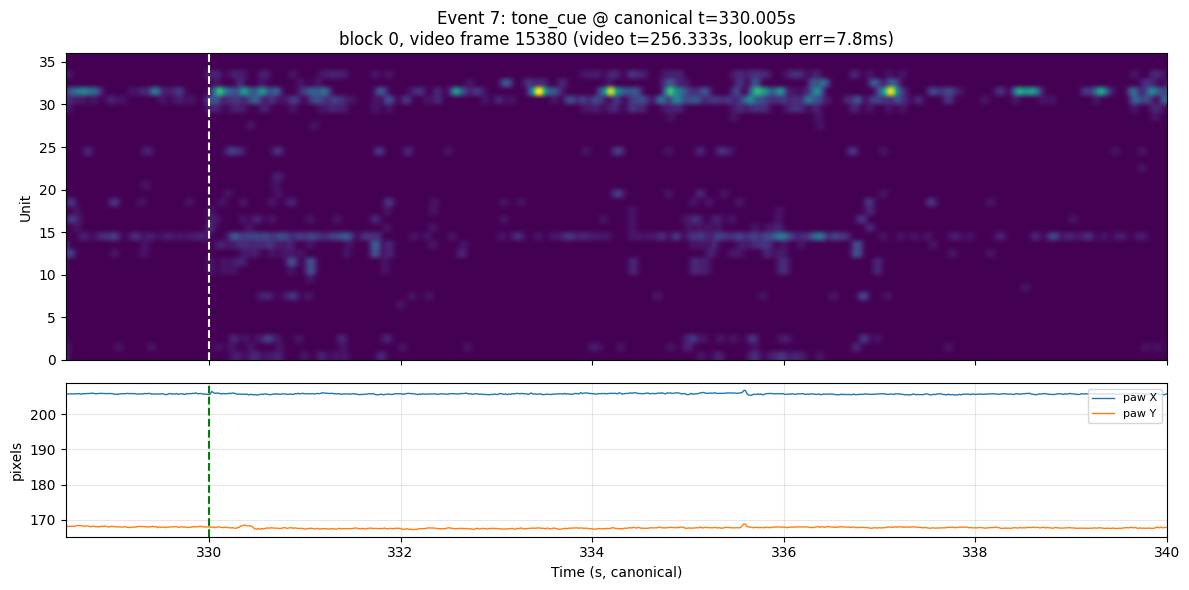

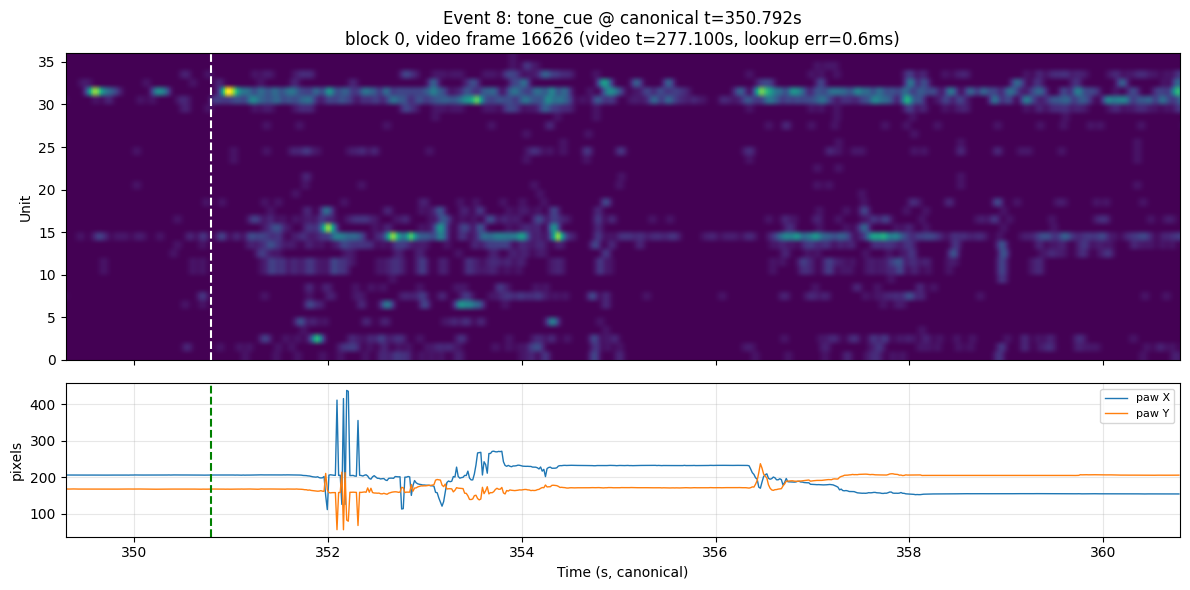


===== CELL G COMPLETE =====



In [22]:
# ============================================================
# CELL G — PERI-EVENT DIAGNOSTIC (PORTABLE)
# ============================================================
# For each event time on a chosen behavioral pin:
#   - shows firing-rate heatmap windowed around the event
#   - overlays DLC trace(s) for selected bodyparts
#   - marks the event with a vertical line
#   - PRINTS canonical time, video frame, and video time
#     so events can be cross-referenced in Fiji/VLC
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL G — PERI-EVENT DIAGNOSTIC =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN       = 4              # 6 = reach, 4 = tone, 3 = motor, etc.
PLOT_BODYPARTS  = ["paw"]
WIN_PRE         = 1.5            # seconds before event
WIN_POST        = 10.0           # seconds after event
MAX_EVENTS_PLOT = 8
ONE_PER_TRIAL   = False          # collapse multi-events per trial to first
TRIAL_PIN       = 4              # trial reference for "one per trial"
VIDEO_FPS       = 60.0           # for video time-from-frame conversion
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]

# ------------------------------------------------------------
# HELPER: canonical time → video frame number (per block)
# ------------------------------------------------------------
# Each block has its own frame_canonical_times array — element i
# is the canonical time of saved frame i (= MP4 frame i, = DLC row i).
# To go canonical→video, find the saved frame whose canonical time
# is closest to the event. This automatically handles per-session
# offsets (NI-to-camera delay) without needing a stored constant.
# ------------------------------------------------------------

# Pre-load per-block frame canonical times for lookups
block_frame_times = {}
for blk in session["blocks"]:
    b = blk["block_index"]
    block_frame_times[b] = np.load(blk["frame_canonical_times_path"])

def canonical_to_video(t_canonical):
    """Return (block_index, video_frame_number, video_time_s, lookup_error_s).

    video_frame_number = MP4 row that DLC sees as row N
    video_time_s       = seconds from start of MP4 (= frame / fps)
    lookup_error_s     = |canonical time of returned frame - requested t|.
                         Small (< ~17 ms) if the event falls during a saved
                         frame. Larger if the event is in a dropped-frame
                         window — in that case the returned frame is the
                         nearest neighbor, and Fiji will show a frame off
                         by lookup_error_s from the real event.
    Returns (None, None, None, None) if the event is outside all blocks.
    """
    for b, frame_t in block_frame_times.items():
        if frame_t[0] <= t_canonical <= frame_t[-1]:
            # bisect for nearest frame
            idx = np.searchsorted(frame_t, t_canonical)
            # check neighbor on the left in case it's closer
            candidates = []
            if idx < len(frame_t):
                candidates.append(idx)
            if idx > 0:
                candidates.append(idx - 1)
            best = min(candidates, key=lambda i: abs(frame_t[i] - t_canonical))
            err = abs(frame_t[best] - t_canonical)
            video_time = best / VIDEO_FPS
            return b, int(best), float(video_time), float(err)
    return None, None, None, None

# ------------------------------------------------------------
# LOAD EVENT TIMES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
print(f"Event pin {EVENT_PIN} ({event_label}): {len(event_times)} TTLs")

if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)
    print(f"After 'first per trial' filter: {len(event_times)} events")

event_times = event_times[:MAX_EVENTS_PLOT]

# ------------------------------------------------------------
# PRINT REFERENCE TABLE (BEFORE PLOTTING)
# ------------------------------------------------------------
print(f"\n===== EVENT REFERENCE TABLE =====")
print(f"{'#':>3} | {'canonical (s)':>14} | {'block':>5} | "
      f"{'video frame':>11} | {'video time (s)':>14} | {'lookup err (ms)':>15}")
print("-" * 80)
for i, t_evt in enumerate(event_times):
    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is None:
        print(f"{i+1:>3} | {t_evt:>14.3f} | {'OOB':>5} | "
              f"{'—':>11} | {'—':>14} | {'—':>15}")
    else:
        flag = " ⚠ in drop?" if err is not None and err > 0.030 else ""
        print(f"{i+1:>3} | {t_evt:>14.3f} | {b:>5} | "
              f"{vframe:>11} | {vtime:>14.3f} | {err*1000:>15.1f}{flag}")
print()

# ------------------------------------------------------------
# LOAD PHYSIOLOGY + DLC
# ------------------------------------------------------------
centers     = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
good_units  = np.load(analysis_folder / "qc" / "good_units.npy")

dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc["canonical_time"]

# ------------------------------------------------------------
# PLOT EACH EVENT
# ------------------------------------------------------------
for i, t_evt in enumerate(event_times):
    t0, t1 = t_evt - WIN_PRE, t_evt + WIN_POST
    mask_fr  = (centers >= t0) & (centers <= t1)
    mask_dlc = (dlc_t   >= t0) & (dlc_t   <= t1)

    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is not None:
        video_str = (f"block {b}, video frame {vframe} "
                     f"(video t={vtime:.3f}s, lookup err={err*1000:.1f}ms)")
    else:
        video_str = "outside any block"

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    # Firing rate
    ax = axes[0]
    ax.imshow(rate_matrix[:, mask_fr], aspect="auto",
              extent=[t0, t1, 0, len(good_units)], origin="lower")
    ax.axvline(t_evt, color="white", linestyle="--", lw=1.5)
    ax.set_ylabel("Unit")
    ax.set_title(f"Event {i+1}: {event_label} @ canonical t={t_evt:.3f}s\n"
                 f"{video_str}")

    # DLC
    ax = axes[1]
    for bp in PLOT_BODYPARTS:
        if f"{bp}_x" not in dlc.files:
            continue
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_x"][mask_dlc], lw=1.0, label=f"{bp} X")
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_y"][mask_dlc], lw=1.0, label=f"{bp} Y")
    ax.axvline(t_evt, color="green", linestyle="--", lw=1.5)
    ax.set_xlabel("Time (s, canonical)")
    ax.set_ylabel("pixels")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n===== CELL G COMPLETE =====\n")


===== CELL H — UNIT MODULATION + LATENCY SORT =====
Aligning to: tone_cue (pin 4), 39 events
Computing PSTHs for 36 units × 39 events × 300 bins...

Modulated units (|z|>2.5 for ≥60 ms in 0.0–2.0s post-event): 25 / 36


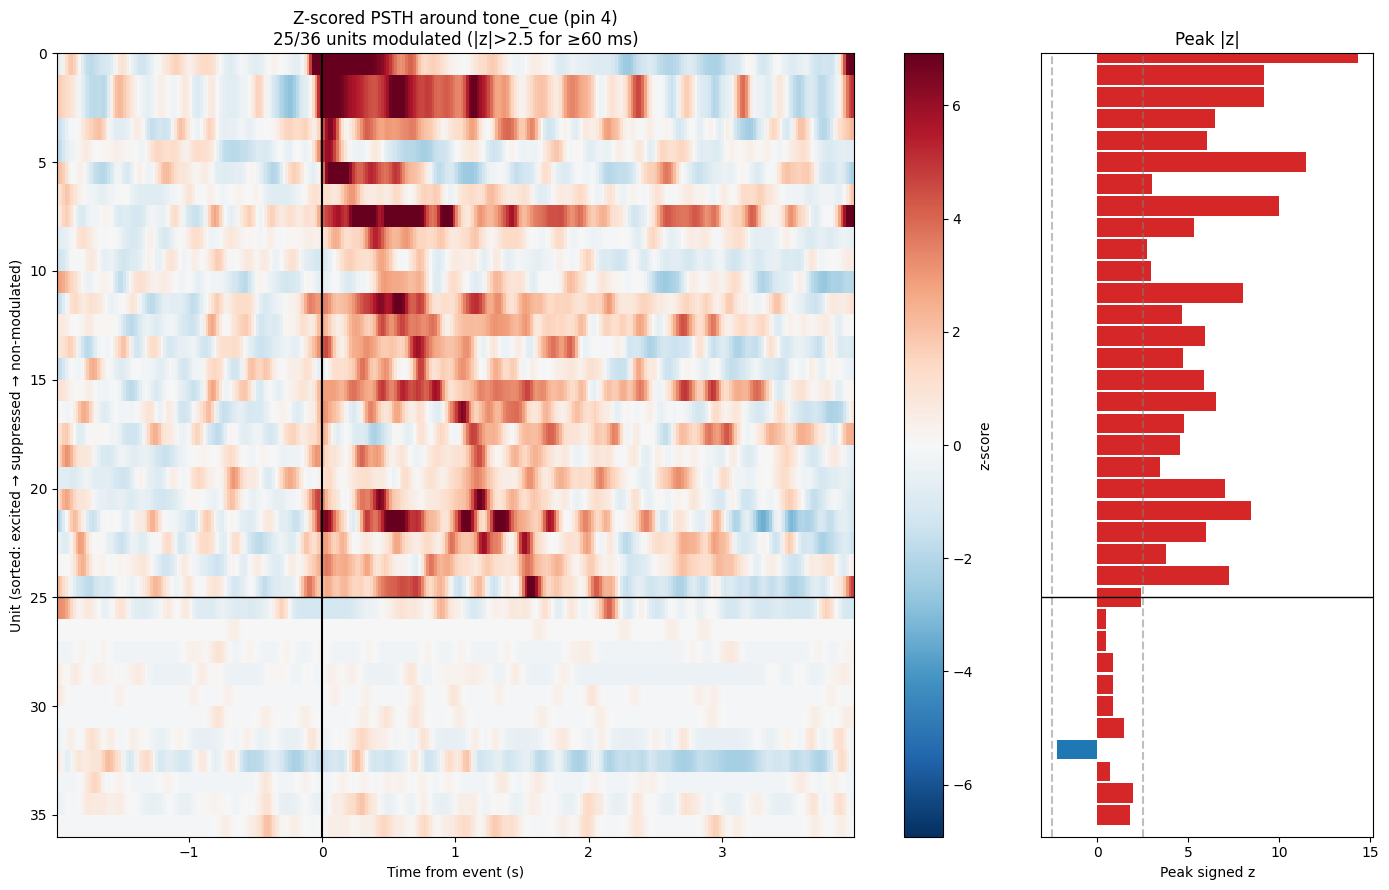


Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\modulation_pin4_tone_cue_1.png
Saved arrays → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\modulation_pin4_tone_cue_arrays.npz

===== CELL H COMPLETE =====



In [23]:
# ============================================================
# CELL H — UNIT MODULATION DETECTION + LATENCY SORT (PORTABLE)
# ============================================================
# For each good unit, build a peri-event PSTH around the chosen
# TTL pin. Z-score against a pre-event baseline, flag units that
# cross a threshold, sort by peak latency, plot as heatmap.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL H — UNIT MODULATION + LATENCY SORT =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN          = 4          # 4 = tone, 3 = motor (use [0::2] for expose),
                                # 6 = reach, 7 = button
EVENT_LABEL_FOR_3  = None       # if EVENT_PIN==3, set to "expose" or "retract"
                                # (uses [0::2] or [1::2])
WIN_PRE            = 2.0        # seconds before event (for plotting and baseline)
WIN_POST           = 4.0        # seconds after event
BASELINE_WIN       = (-2.0, -0.5)  # baseline window (relative to event) for z-scoring
RESPONSE_WIN       = ( 0.0, 2.0)   # window in which to look for modulation
BIN_SIZE           = 0.020      # seconds (20 ms)
SMOOTH_SIGMA_BINS  = 2          # Gaussian smoothing, in bins (40 ms σ for 20 ms bins)
Z_THRESHOLD        = 2.5        # |z| crossing threshold for "modulated"
MIN_CONSECUTIVE_MS = 60         # must be |z|>threshold for at least this long
ONE_PER_TRIAL      = False
TRIAL_PIN          = 4
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")

# ------------------------------------------------------------
# LOAD EVENT TIMES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
if EVENT_PIN == 3 and EVENT_LABEL_FOR_3 is not None:
    if EVENT_LABEL_FOR_3 == "expose":
        event_times = event_times[0::2]
        event_label = "pellet_expose"
    elif EVENT_LABEL_FOR_3 == "retract":
        event_times = event_times[1::2]
        event_label = "pellet_retract"
    else:
        raise ValueError("EVENT_LABEL_FOR_3 must be 'expose' or 'retract'")

if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)

print(f"Aligning to: {event_label} (pin {EVENT_PIN}), {len(event_times)} events")

# ------------------------------------------------------------
# BIN EDGES (in PERI-EVENT TIME, not canonical)
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)

baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])

# ------------------------------------------------------------
# COMPUTE PSTH PER UNIT
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"

psth        = np.zeros((len(good_units), n_bins), dtype=np.float64)  # mean rate
psth_per_trial = np.zeros((len(good_units), len(event_times), n_bins))

print(f"Computing PSTHs for {len(good_units)} units × {len(event_times)} events × {n_bins} bins...")

for u_i, unit in enumerate(good_units):
    spk = np.load(spikes_dir / f"unit_{unit}.npy")
    for e_i, t_evt in enumerate(event_times):
        # spikes in the peri-event window, expressed as time-from-event
        rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
        h, _ = np.histogram(rel, bins=edges)
        psth_per_trial[u_i, e_i] = h / BIN_SIZE  # convert to Hz

# trial-averaged PSTH per unit
psth = psth_per_trial.mean(axis=1)

# smooth
psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)

# ------------------------------------------------------------
# Z-SCORE EACH UNIT AGAINST ITS OWN BASELINE
# ------------------------------------------------------------
baseline_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
baseline_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
baseline_std[baseline_std < 0.5] = 0.5   # floor to avoid div-by-near-zero
                                          # for very quiet baselines (0.5 Hz)

z = (psth_smooth - baseline_mean) / baseline_std   # (n_units, n_bins)

# ------------------------------------------------------------
# MODULATION DETECTION
# ------------------------------------------------------------
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
z_response = z[:, response_mask]

def has_consecutive_crossing(z_row, thresh, min_consec):
    """True if z_row has min_consec consecutive bins with |z|>thresh of same sign."""
    pos = z_row > thresh
    neg = z_row < -thresh
    # run-length detection
    for arr in (pos, neg):
        # find runs of True
        if not arr.any():
            continue
        # quick run-length: pad with False, find rising/falling edges
        padded = np.concatenate([[False], arr, [False]])
        diffs = np.diff(padded.astype(int))
        starts = np.where(diffs == 1)[0]
        ends   = np.where(diffs == -1)[0]
        if (ends - starts).max() >= min_consec:
            return True
    return False

modulated = np.array([
    has_consecutive_crossing(z_response[i], Z_THRESHOLD, min_consec_bins)
    for i in range(len(good_units))
])

n_modulated = int(modulated.sum())
print(f"\nModulated units (|z|>{Z_THRESHOLD} for ≥{MIN_CONSECUTIVE_MS} ms in "
      f"{RESPONSE_WIN[0]}–{RESPONSE_WIN[1]}s post-event): "
      f"{n_modulated} / {len(good_units)}")

# ------------------------------------------------------------
# LATENCY = time of peak signed z within response window
# ------------------------------------------------------------
response_centers = centers[response_mask]
# argmax of absolute z, but keep the sign
peak_idx  = np.argmax(np.abs(z_response), axis=1)
peak_lat  = response_centers[peak_idx]                        # signed latency
peak_z    = z_response[np.arange(len(good_units)), peak_idx]  # signed magnitude

# Among modulated units, sort by latency (excited first, then suppressed,
# each sorted by peak time)
mod_idx       = np.where(modulated)[0]
mod_peak_lat  = peak_lat[mod_idx]
mod_peak_z    = peak_z[mod_idx]

# Sort: excited (peak_z>0) by ascending latency, then suppressed (peak_z<0) by ascending latency
excited_mask  = mod_peak_z > 0
sup_mask      = ~excited_mask

excited_order = mod_idx[excited_mask][np.argsort(mod_peak_lat[excited_mask])]
suppressed_order = mod_idx[sup_mask][np.argsort(mod_peak_lat[sup_mask])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])

# Non-modulated units at the bottom, unsorted
non_mod_idx = np.where(~modulated)[0]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_idx])

# ------------------------------------------------------------
# PLOT: SORTED Z-SCORE HEATMAP
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 9),
                          gridspec_kw={"width_ratios": [3, 1]})

ax = axes[0]
vmax = max(3.0, np.percentile(np.abs(z), 99))
im = ax.imshow(z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(good_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax,
               interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (sorted: excited → suppressed → non-modulated)")
ax.set_title(f"Z-scored PSTH around {event_label} (pin {EVENT_PIN})\n"
             f"{n_modulated}/{len(good_units)} units modulated "
             f"(|z|>{Z_THRESHOLD} for ≥{MIN_CONSECUTIVE_MS} ms)")
plt.colorbar(im, ax=ax, label="z-score")

# Side panel: signed peak z for each unit (in same sort order)
ax = axes[1]
y = np.arange(len(good_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(good_units), 0)
ax.set_xlabel("Peak signed z")
ax.set_yticks([])
ax.set_title("Peak |z|")

plt.tight_layout()

# Save
out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE RESULTS TO DISK
# ------------------------------------------------------------
results = {
    "event_pin": int(EVENT_PIN),
    "event_label": event_label,
    "n_events": int(len(event_times)),
    "bin_size_s": float(BIN_SIZE),
    "win_pre_s":  float(WIN_PRE),
    "win_post_s": float(WIN_POST),
    "baseline_win_s": list(BASELINE_WIN),
    "response_win_s": list(RESPONSE_WIN),
    "z_threshold": float(Z_THRESHOLD),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "n_units": int(len(good_units)),
    "n_modulated": int(n_modulated),
}
results_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_summary.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

# Save per-unit arrays
np.savez(out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_arrays.npz",
         good_units=good_units,
         psth_smooth=psth_smooth,
         z=z,
         modulated=modulated,
         peak_latency=peak_lat,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers)
print(f"Saved arrays → {out_dir / f'modulation_pin{EVENT_PIN}_{event_label}_arrays.npz'}")

print("\n===== CELL H COMPLETE =====\n")


===== CELL I — SHUFFLED CONTROLS =====
Real events (tone_cue, pin 4): 39
Loaded spike times for 36 units

Computing real-data PSTHs...
Real data: 25 / 36 modulated (69.4%)

--- Test 1: shuffling event times (100 iterations) ---
  10/100 done. Running mean modulated (shuffled): 11.7
  20/100 done. Running mean modulated (shuffled): 12.9
  30/100 done. Running mean modulated (shuffled): 12.5
  40/100 done. Running mean modulated (shuffled): 12.4
  50/100 done. Running mean modulated (shuffled): 12.9
  60/100 done. Running mean modulated (shuffled): 12.5
  70/100 done. Running mean modulated (shuffled): 12.4
  80/100 done. Running mean modulated (shuffled): 12.1
  90/100 done. Running mean modulated (shuffled): 12.2
  100/100 done. Running mean modulated (shuffled): 12.5

Test 1 results:
  Real:           25 modulated units
  Shuffled mean:  12.5 ± 4.5
  Shuffled 95th:  20
  Real / shuffled-mean ratio: 2.0×
  p-value (real ≥ shuffled):  0.0000

--- Test 2: shuffling PSTH bins within each

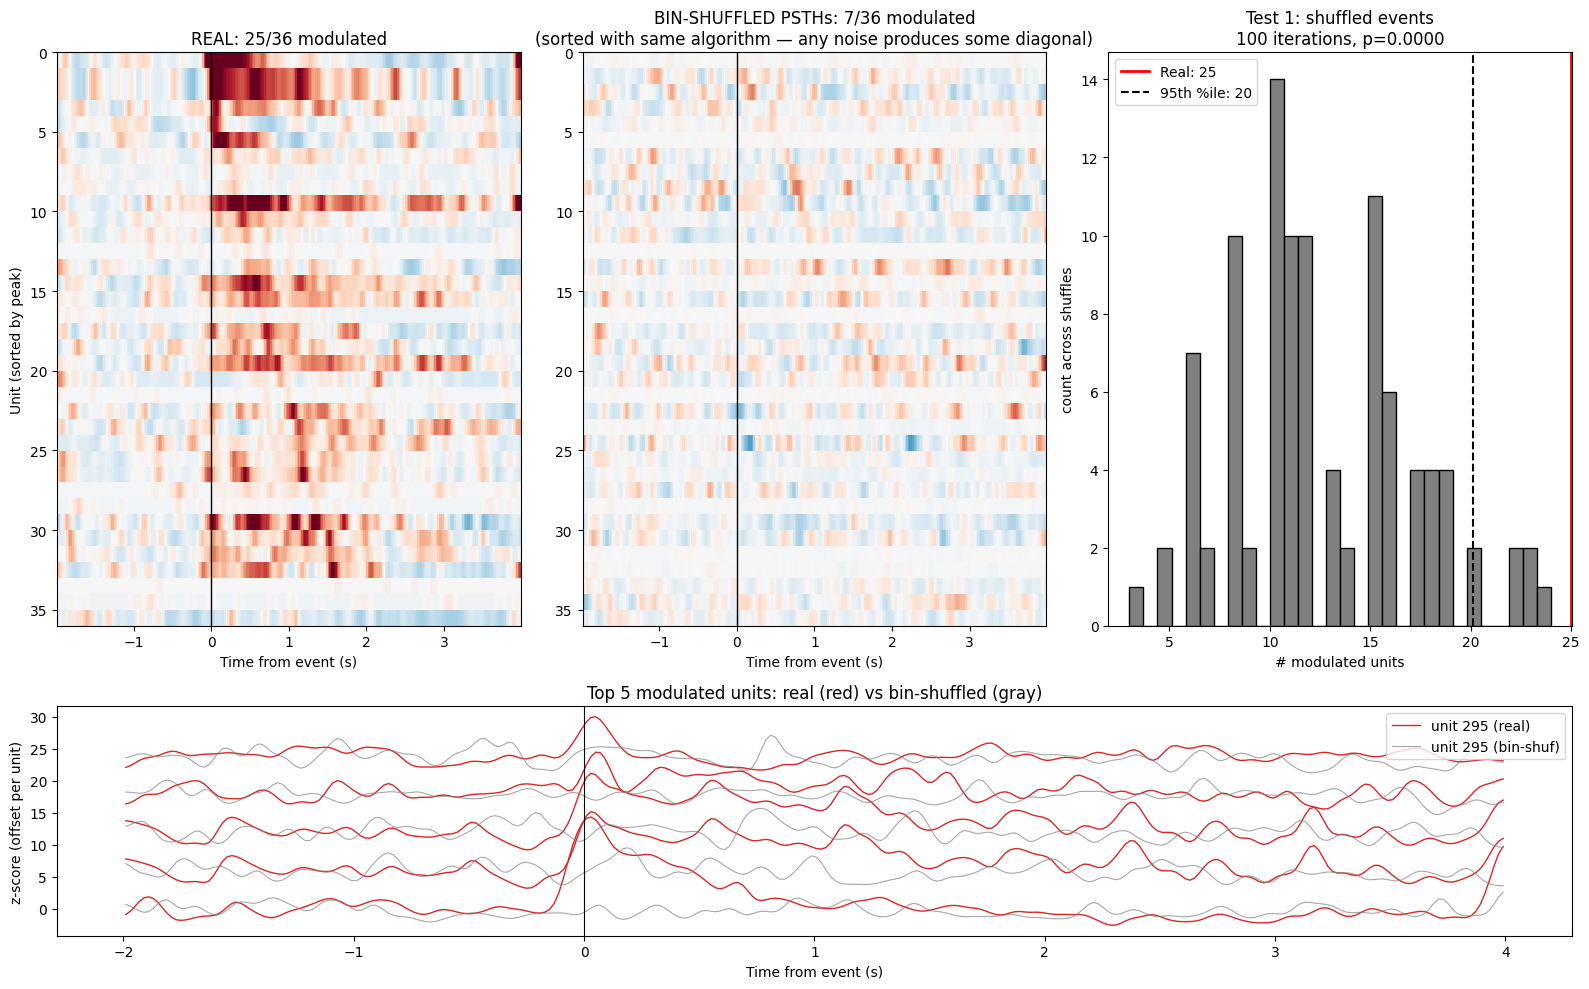


Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\falsification_pin4_tone_cue_1.png

===== INTERPRETATION =====

Test 1 (shuffled event times):
  ~ MARGINAL. Real exceeds shuffled (p=0.0000) but ratio (2.0×) is modest. Some signal, but weaker than the plot suggests.

Test 2 (bin-shuffled PSTHs):
  ✓ PASSED. Real (25) vs bin-shuffled (7): real shows much more modulation than randomly-permuted bins. Real structure is in the temporal pattern, not just in the sorting.

===== CELL I COMPLETE =====



In [24]:
# ============================================================
# CELL I — FALSIFICATION TESTS: SHUFFLED CONTROLS
# ============================================================
# Two independent null distributions to test whether the
# modulation pattern in Cell H is real signal or analysis artifact.
#
# Test 1: SHUFFLED EVENT TIMES
#   Replace the 48 real event times with 48 random times drawn
#   from the recording, run the full Cell H analysis, count
#   modulated units. Repeat N_SHUFFLES times.
#   → Tests: is the population response time-locked to the actual
#     events, or would *any* set of events produce this pattern?
#
# Test 2: PER-BIN SHUFFLED PSTHs
#   Take the real PSTHs and shuffle each unit's bins independently.
#   Re-detect modulation and re-sort. The resulting heatmap will
#   look superficially similar (any sorted-by-argmax data forms a
#   diagonal) but the # of "modulated" units and the strength of
#   the diagonal should be much lower.
#   → Tests: is the sort doing the work, or is there real structure?
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL I — SHUFFLED CONTROLS =====")

# ------------------------------------------------------------
# USER EDIT — must match Cell H parameters exactly
# ------------------------------------------------------------
EVENT_PIN          = 4
WIN_PRE            = 2.0
WIN_POST           = 4.0
BASELINE_WIN       = (-2.0, -0.5)
RESPONSE_WIN       = ( 0.0,  2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
Z_THRESHOLD        = 2.5
MIN_CONSECUTIVE_MS = 60
N_SHUFFLES         = 100      # 100 is enough for a strong test; 1000 for publication
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD EVENT TIMES + UNITS
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
real_events = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
print(f"Real events ({event_label}, pin {EVENT_PIN}): {len(real_events)}")

good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"

# Pre-load all spike trains
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"Loaded spike times for {len(good_units)} units")

# ------------------------------------------------------------
# SHARED HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)

baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

def compute_psth_zscore(events):
    """Returns (psth_smooth, z) given a set of event times."""
    psth_per_trial = np.zeros((len(good_units), len(events), n_bins))
    for u_i, u in enumerate(good_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    psth = psth_per_trial.mean(axis=1)
    psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
    base_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
    base_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
    base_std[base_std < 0.5] = 0.5
    z = (psth_smooth - base_mean) / base_std
    return psth_smooth, z

def count_modulated(z):
    """Returns number of units with |z|>thresh for ≥min_consec_bins in response window."""
    z_resp = z[:, response_mask]
    count = 0
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > Z_THRESHOLD, z_resp[i] < -Z_THRESHOLD):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                count += 1
                break
    return count

# ------------------------------------------------------------
# REAL DATA — recompute for comparison
# ------------------------------------------------------------
print("\nComputing real-data PSTHs...")
real_psth, real_z = compute_psth_zscore(real_events)
real_n_modulated = count_modulated(real_z)
print(f"Real data: {real_n_modulated} / {len(good_units)} modulated "
      f"({100*real_n_modulated/len(good_units):.1f}%)")

# ============================================================
# TEST 1: SHUFFLED EVENT TIMES
# ============================================================
print(f"\n--- Test 1: shuffling event times ({N_SHUFFLES} iterations) ---")

rng = np.random.default_rng(RANDOM_SEED)

# Constrain shuffled events to leave room for WIN_PRE / WIN_POST
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

shuffled_n_modulated = np.zeros(N_SHUFFLES, dtype=int)
for s in range(N_SHUFFLES):
    fake_events = rng.uniform(t_min, t_max, size=len(real_events))
    fake_events.sort()
    _, fake_z = compute_psth_zscore(fake_events)
    shuffled_n_modulated[s] = count_modulated(fake_z)
    if (s + 1) % 10 == 0:
        print(f"  {s+1}/{N_SHUFFLES} done. "
              f"Running mean modulated (shuffled): "
              f"{shuffled_n_modulated[:s+1].mean():.1f}")

shuffled_mean = shuffled_n_modulated.mean()
shuffled_std  = shuffled_n_modulated.std()
shuffled_95   = np.percentile(shuffled_n_modulated, 95)
p_value       = (shuffled_n_modulated >= real_n_modulated).sum() / N_SHUFFLES

print(f"\nTest 1 results:")
print(f"  Real:           {real_n_modulated} modulated units")
print(f"  Shuffled mean:  {shuffled_mean:.1f} ± {shuffled_std:.1f}")
print(f"  Shuffled 95th:  {shuffled_95:.0f}")
print(f"  Real / shuffled-mean ratio: {real_n_modulated / max(shuffled_mean, 1):.1f}×")
print(f"  p-value (real ≥ shuffled):  {p_value:.4f}")

# ============================================================
# TEST 2: PER-BIN SHUFFLED PSTHs (sort-order falsification)
# ============================================================
print(f"\n--- Test 2: shuffling PSTH bins within each unit ---")

# Take the real PSTH, shuffle each row's bins independently
shuffled_psth = real_psth.copy()
for i in range(shuffled_psth.shape[0]):
    rng.shuffle(shuffled_psth[i])

# Re-smooth (since smoothing assumed temporal structure)
shuffled_psth_smooth = gaussian_filter1d(shuffled_psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
base_m = shuffled_psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
base_s = shuffled_psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
base_s[base_s < 0.5] = 0.5
shuffled_z = (shuffled_psth_smooth - base_m) / base_s

# Modulation count
binshuf_n_modulated = count_modulated(shuffled_z)
print(f"  Bin-shuffled modulated: {binshuf_n_modulated}")

# Sort by peak latency in response window (same algorithm as Cell H)
def sort_by_peak(z_mat):
    z_resp = z_mat[:, response_mask]
    response_centers = centers[response_mask]
    peak_idx = np.argmax(np.abs(z_resp), axis=1)
    peak_lat = response_centers[peak_idx]
    peak_z   = z_resp[np.arange(z_resp.shape[0]), peak_idx]
    excited  = peak_z > 0
    order    = np.concatenate([
        np.where(excited)[0][np.argsort(peak_lat[excited])],
        np.where(~excited)[0][np.argsort(peak_lat[~excited])],
    ])
    return order

real_order   = sort_by_peak(real_z)
shuf_order   = sort_by_peak(shuffled_z)

# ============================================================
# FIGURE: SIDE-BY-SIDE HEATMAPS + HISTOGRAM
# ============================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[2.5, 1])

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = fig.add_subplot(gs[0, 0])
ax.imshow(real_z[real_order], aspect="auto",
          extent=[centers[0], centers[-1], len(good_units), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (sorted by peak)")
ax.set_title(f"REAL: {real_n_modulated}/{len(good_units)} modulated")

ax = fig.add_subplot(gs[0, 1])
ax.imshow(shuffled_z[shuf_order], aspect="auto",
          extent=[centers[0], centers[-1], len(good_units), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_title(f"BIN-SHUFFLED PSTHs: {binshuf_n_modulated}/{len(good_units)} modulated\n"
             "(sorted with same algorithm — any noise produces some diagonal)")

# Histogram of shuffled-events modulated counts
ax = fig.add_subplot(gs[0, 2])
ax.hist(shuffled_n_modulated, bins=30, color="gray", edgecolor="black")
ax.axvline(real_n_modulated, color="red", lw=2,
           label=f"Real: {real_n_modulated}")
ax.axvline(shuffled_95, color="black", linestyle="--",
           label=f"95th %ile: {shuffled_95:.0f}")
ax.set_xlabel("# modulated units")
ax.set_ylabel("count across shuffles")
ax.set_title(f"Test 1: shuffled events\n{N_SHUFFLES} iterations, p={p_value:.4f}")
ax.legend()

# Bottom row: example PSTHs to compare
ax = fig.add_subplot(gs[1, :])
# Show real vs shuffled for a few top-modulated units
top_units_idx = real_order[:5]
for k, u_i in enumerate(top_units_idx):
    ax.plot(centers, real_z[u_i] + k * 6, color="C3", lw=1.0,
            label=f"unit {good_units[u_i]} (real)" if k == 0 else None)
    ax.plot(centers, shuffled_z[u_i] + k * 6, color="gray", lw=0.8, alpha=0.7,
            label=f"unit {good_units[u_i]} (bin-shuf)" if k == 0 else None)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("z-score (offset per unit)")
ax.set_title("Top 5 modulated units: real (red) vs bin-shuffled (gray)")
ax.legend(loc="upper right")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"falsification_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"falsification_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ============================================================
# INTERPRETATION
# ============================================================
print("\n===== INTERPRETATION =====")

print(f"\nTest 1 (shuffled event times):")
if p_value < 0.01 and real_n_modulated > shuffled_mean * 3:
    print(f"  ✓ PASSED. Real modulation count ({real_n_modulated}) is "
          f"{real_n_modulated/shuffled_mean:.1f}× the shuffled mean. "
          f"The temporal structure is locked to actual events.")
elif p_value < 0.05:
    print(f"  ~ MARGINAL. Real exceeds shuffled (p={p_value:.4f}) but ratio "
          f"({real_n_modulated/max(shuffled_mean,1):.1f}×) is modest. "
          f"Some signal, but weaker than the plot suggests.")
else:
    print(f"  ✗ FAILED. Shuffled events produce similar modulation counts. "
          f"The diagonal in your Cell H plot is likely an analysis artifact, "
          f"NOT real time-locked response. STOP and investigate.")

print(f"\nTest 2 (bin-shuffled PSTHs):")
if real_n_modulated > binshuf_n_modulated * 3:
    print(f"  ✓ PASSED. Real ({real_n_modulated}) vs bin-shuffled "
          f"({binshuf_n_modulated}): real shows much more modulation than "
          f"randomly-permuted bins. Real structure is in the temporal "
          f"pattern, not just in the sorting.")
else:
    print(f"  ✗ FAILED. Bin-shuffled PSTHs ({binshuf_n_modulated}) modulate "
          f"almost as much as real ({real_n_modulated}). The diagonal is "
          f"largely a sorting artifact (any data sorted by argmax forms a "
          f"diagonal). STOP and reconsider.")

print("\n===== CELL I COMPLETE =====\n")


===== CELL H — STRINGENT MODULATION DETECTION =====
Aligning to: tone_cue (pin 4), 39 events
Loaded 36 good units
Units with ≥1.0 Hz baseline: 23 / 36
Excluding 13 low-rate units from analysis

Computing session-wide baseline per unit...
Baseline rates: median=2.93 Hz, range 0.99 – 31.48 Hz

Calibrating Z threshold to give 10% false-positive rate under shuffled events (100 iterations)...
  25/100 done
  50/100 done
  75/100 done
  100/100 done

Shuffled FPR by Z threshold:
  Z>2.00:  shuffled FPR = 0.9%
  Z>2.25:  shuffled FPR = 0.3%
  Z>2.50:  shuffled FPR = 0.1%
  Z>2.75:  shuffled FPR = 0.0%
  Z>3.00:  shuffled FPR = 0.0%
  Z>3.25:  shuffled FPR = 0.0%
  Z>3.50:  shuffled FPR = 0.0%
  Z>3.75:  shuffled FPR = 0.0%
  Z>4.00:  shuffled FPR = 0.0%
  Z>4.25:  shuffled FPR = 0.0%
  Z>4.50:  shuffled FPR = 0.0%
  Z>4.75:  shuffled FPR = 0.0%
  Z>5.00:  shuffled FPR = 0.0%
  Z>5.25:  shuffled FPR = 0.0%
  Z>5.50:  shuffled FPR = 0.0%
  Z>5.75:  shuffled FPR = 0.0%
  Z>6.00:  shuffled FPR =

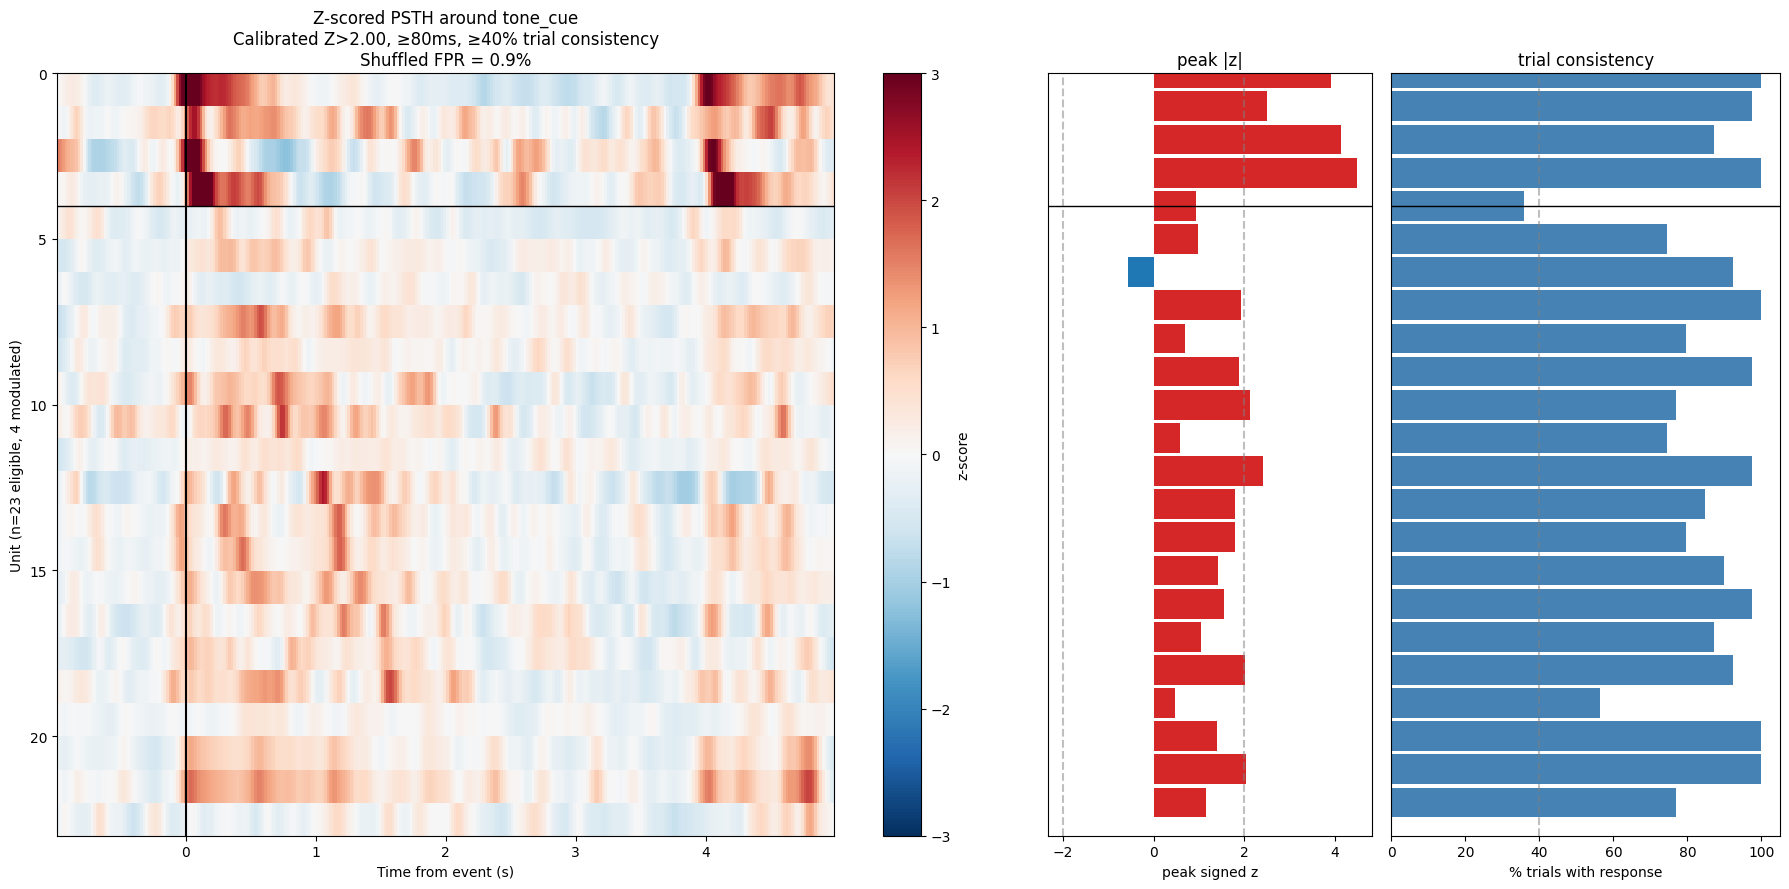


Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\modulation_strict_pin4_tone_cue_2.png

===== INTERPRETATION =====
  Eligible units (≥1.0 Hz):       23 / 36
  Calibrated threshold:                Z > 2.00
  Shuffled FPR at this threshold:      0.9%
  Modulated units (real data):         4
  Excess over chance:                  4 units above expected FPR

These 4 units are your defensible modulated set for tone_cue.

===== CELL H COMPLETE =====



In [25]:
# ============================================================
# CELL H — STRINGENT MODULATION DETECTION (PORTABLE)
# ============================================================
# Replaces the old Cell H + Cell I workflow.
#
# Core principles:
# 1. Session-wide baseline — each unit's null distribution comes
#    from random windows throughout the recording, not the brief
#    pre-event window (which can be contaminated by other events).
# 2. Auto-calibrated threshold — the Z threshold is set so that
#    shuffled-event analysis produces ~5% false positives in this
#    session. This makes the criterion adapt to per-session noise.
# 3. Per-trial consistency — a unit must show the response on
#    ≥CONSISTENCY_FRAC of trials, not just in trial-average.
# 4. Min baseline firing rate — units below this are excluded
#    from analysis (PSTHs are too noisy to be informative).
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL H — STRINGENT MODULATION DETECTION =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN          = 4            # 4=tone, 3=motor, 6=reach, 7=button
WIN_PRE            = 1.0          # seconds before event
WIN_POST           = 5.0          # seconds after event
RESPONSE_WIN       = (-0.5, 5.0)   # window where modulation must occur
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 80          # need this long of |z|>threshold
MIN_BASELINE_HZ    = 1.0          # exclude units firing below this
CONSISTENCY_FRAC   = 0.40         # response must appear on ≥40% of trials
N_SHUFFLES_CALIB   = 100          # shuffles used to calibrate threshold
TARGET_FPR         = 0.10         # target shuffled false-positive rate
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD EVENT TIMES + UNITS
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
n_events = len(event_times)
print(f"Aligning to: {event_label} (pin {EVENT_PIN}), {n_events} events")

good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"Loaded {len(good_units)} good units")

# ------------------------------------------------------------
# FILTER UNITS BY MIN BASELINE FIRING RATE
# ------------------------------------------------------------
unit_rates = np.array([len(all_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible = unit_rates >= MIN_BASELINE_HZ
n_eligible = int(eligible.sum())
print(f"Units with ≥{MIN_BASELINE_HZ} Hz baseline: {n_eligible} / {len(good_units)}")
print(f"Excluding {len(good_units) - n_eligible} low-rate units from analysis")

eligible_units = good_units[eligible]

# ------------------------------------------------------------
# SHARED COMPUTATION HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

# ------------------------------------------------------------
# COMPUTE SESSION-WIDE BASELINE PER UNIT
# ------------------------------------------------------------
# For each unit, sample many random windows of duration matching
# the response window. The mean and std of these "null" rates
# becomes that unit's baseline distribution.
# ------------------------------------------------------------
print("\nComputing session-wide baseline per unit...")
rng = np.random.default_rng(RANDOM_SEED)

resp_dur = RESPONSE_WIN[1] - RESPONSE_WIN[0]
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0
n_null_windows = 500

baseline_mean = np.zeros(len(eligible_units))
baseline_std  = np.zeros(len(eligible_units))

for i, u in enumerate(eligible_units):
    spk = all_spikes[int(u)]
    null_starts = rng.uniform(t_min, t_max - resp_dur, size=n_null_windows)
    null_rates = np.zeros(n_null_windows)
    for j, ts in enumerate(null_starts):
        null_rates[j] = ((spk >= ts) & (spk < ts + resp_dur)).sum() / resp_dur
    baseline_mean[i] = null_rates.mean()
    baseline_std[i]  = null_rates.std()
# floor std at 1% of mean to avoid div-by-zero for very stable units
baseline_std = np.maximum(baseline_std, baseline_mean * 0.01 + 0.1)

print(f"Baseline rates: median={np.median(baseline_mean):.2f} Hz, "
      f"range {baseline_mean.min():.2f} – {baseline_mean.max():.2f} Hz")

# ------------------------------------------------------------
# CORE: compute per-trial PSTH and z-score for a set of events
# ------------------------------------------------------------
def compute_per_trial_z(events):
    """Returns (psth_smooth_per_trial, psth_smooth_mean) z-scored against
    SESSION-WIDE baseline (not per-event baseline).
    Shape: (n_units, n_trials, n_bins) and (n_units, n_bins)"""
    psth_per_trial = np.zeros((len(eligible_units), len(events), n_bins))
    for u_i, u in enumerate(eligible_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    # smooth each trial
    psth_smooth_per_trial = gaussian_filter1d(psth_per_trial,
                                              sigma=SMOOTH_SIGMA_BINS, axis=2)
    psth_smooth_mean = psth_smooth_per_trial.mean(axis=1)
    # z-score against session-wide baseline
    z_mean = ((psth_smooth_mean - baseline_mean[:, None])
              / baseline_std[:, None])
    return psth_smooth_per_trial, psth_smooth_mean, z_mean

# ------------------------------------------------------------
# MODULATION CRITERION (parameterized so we can tune Z threshold)
# ------------------------------------------------------------
def count_modulated(z_mat, z_thresh):
    """Returns boolean array per unit: |z|>thresh for ≥min_consec_bins in
    response window."""
    z_resp = z_mat[:, response_mask]
    out = np.zeros(z_resp.shape[0], dtype=bool)
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > z_thresh, z_resp[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                out[i] = True
                break
    return out

# ------------------------------------------------------------
# CALIBRATE Z THRESHOLD ON SHUFFLED EVENTS
# ------------------------------------------------------------
# Run N_SHUFFLES_CALIB shuffles. For each, compute z-scored PSTHs and
# tally "modulated unit count" at a grid of Z thresholds.
# Pick the lowest Z threshold that gives ≤TARGET_FPR mean shuffled rate.
# ------------------------------------------------------------
print(f"\nCalibrating Z threshold to give {TARGET_FPR*100:.0f}% false-positive rate "
      f"under shuffled events ({N_SHUFFLES_CALIB} iterations)...")

z_thresh_grid = np.arange(2.0, 6.01, 0.25)
shuffled_fpr = np.zeros((N_SHUFFLES_CALIB, len(z_thresh_grid)))

for s in range(N_SHUFFLES_CALIB):
    fake_events = rng.uniform(t_min, t_max, size=n_events)
    fake_events.sort()
    _, _, fake_z = compute_per_trial_z(fake_events)
    for j, thr in enumerate(z_thresh_grid):
        shuffled_fpr[s, j] = count_modulated(fake_z, thr).sum() / len(eligible_units)
    if (s + 1) % 25 == 0:
        print(f"  {s+1}/{N_SHUFFLES_CALIB} done")

mean_fpr_by_thresh = shuffled_fpr.mean(axis=0)
print("\nShuffled FPR by Z threshold:")
for thr, fpr in zip(z_thresh_grid, mean_fpr_by_thresh):
    flag = "  ← target" if (fpr <= TARGET_FPR and (
        len(z_thresh_grid) == 0 or fpr > TARGET_FPR - 0.02)) else ""
    print(f"  Z>{thr:.2f}:  shuffled FPR = {fpr*100:.1f}%{flag}")

# Pick smallest Z that achieves target FPR
viable = np.where(mean_fpr_by_thresh <= TARGET_FPR)[0]
if len(viable) == 0:
    print(f"\nWARNING: no threshold achieves ≤{TARGET_FPR*100:.0f}% FPR even at "
          f"Z=6. Picking Z={z_thresh_grid[-1]} and reporting actual FPR.")
    z_thresh_chosen = float(z_thresh_grid[-1])
else:
    z_thresh_chosen = float(z_thresh_grid[viable[0]])

calibrated_fpr = mean_fpr_by_thresh[
    np.argmin(np.abs(z_thresh_grid - z_thresh_chosen))]
print(f"\nCalibrated Z threshold: {z_thresh_chosen:.2f}  "
      f"(shuffled FPR = {calibrated_fpr*100:.1f}%)")

# ------------------------------------------------------------
# APPLY CALIBRATED CRITERION TO REAL EVENTS
# ------------------------------------------------------------
print(f"\nApplying calibrated criterion to real {event_label} events...")
real_per_trial, real_mean, real_z = compute_per_trial_z(event_times)
modulated_initial = count_modulated(real_z, z_thresh_chosen)
n_initial = int(modulated_initial.sum())
print(f"Units passing Z criterion (trial-averaged): {n_initial} / {len(eligible_units)}")

# ------------------------------------------------------------
# CONSISTENCY FILTER: response must appear on ≥CONSISTENCY_FRAC trials
# ------------------------------------------------------------
# For each unit that passed the trial-averaged criterion, ask: on what
# fraction of individual trials does the unit show ANY bin in the
# response window with rate > baseline_mean + z_thresh*baseline_std?
# ------------------------------------------------------------
print(f"\nApplying consistency filter (≥{CONSISTENCY_FRAC*100:.0f}% of trials)...")

per_trial_z = ((real_per_trial - baseline_mean[:, None, None])
               / baseline_std[:, None, None])
per_trial_z_resp = per_trial_z[:, :, response_mask]

# fraction of trials where the unit has at least one bin |z|>thresh
trial_resp_pos = (per_trial_z_resp > z_thresh_chosen).any(axis=2)
trial_resp_neg = (per_trial_z_resp < -z_thresh_chosen).any(axis=2)
trial_resp_either = trial_resp_pos | trial_resp_neg
trial_consistency = trial_resp_either.mean(axis=1)

modulated_final = modulated_initial & (trial_consistency >= CONSISTENCY_FRAC)
n_final = int(modulated_final.sum())
print(f"Units also passing consistency filter: {n_final} / {len(eligible_units)}")

# ------------------------------------------------------------
# LATENCY + SIGN
# ------------------------------------------------------------
response_centers = centers[response_mask]
z_resp = real_z[:, response_mask]
peak_idx = np.argmax(np.abs(z_resp), axis=1)
peak_latency = response_centers[peak_idx]
peak_z = z_resp[np.arange(len(eligible_units)), peak_idx]

# ------------------------------------------------------------
# SORT FOR PLOTTING
# ------------------------------------------------------------
final_idx = np.where(modulated_final)[0]
excited_mask = peak_z[final_idx] > 0
excited_order = final_idx[excited_mask][np.argsort(peak_latency[final_idx[excited_mask]])]
suppressed_order = final_idx[~excited_mask][np.argsort(peak_latency[final_idx[~excited_mask]])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])

# Non-modulated at bottom (also sorted, just for readability)
non_mod_idx = np.where(~modulated_final)[0]
non_mod_order = non_mod_idx[np.argsort(peak_latency[non_mod_idx])]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_order])

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 9),
                          gridspec_kw={"width_ratios": [3, 1, 1.2]})

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = axes[0]
im = ax.imshow(real_z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(eligible_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel(f"Unit (n={len(eligible_units)} eligible, "
              f"{n_final} modulated)")
ax.set_title(f"Z-scored PSTH around {event_label}\n"
             f"Calibrated Z>{z_thresh_chosen:.2f}, ≥{MIN_CONSECUTIVE_MS}ms, "
             f"≥{CONSISTENCY_FRAC*100:.0f}% trial consistency\n"
             f"Shuffled FPR = {calibrated_fpr*100:.1f}%")
plt.colorbar(im, ax=ax, label="z-score")

# Side: peak signed z
ax = axes[1]
y = np.arange(len(eligible_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("peak signed z")
ax.set_yticks([])
ax.set_title("peak |z|")

# Side: trial consistency
ax = axes[2]
ax.barh(y, trial_consistency[full_sort_idx] * 100,
        color="steelblue", height=0.9)
ax.axvline(CONSISTENCY_FRAC * 100, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("% trials with response")
ax.set_yticks([])
ax.set_title("trial consistency")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------
results = {
    "event_pin": int(EVENT_PIN),
    "event_label": event_label,
    "n_events": int(n_events),
    "n_units_total": int(len(good_units)),
    "n_units_eligible": int(len(eligible_units)),
    "n_modulated": int(n_final),
    "z_threshold_calibrated": float(z_thresh_chosen),
    "shuffled_fpr_at_threshold": float(calibrated_fpr),
    "min_baseline_hz": float(MIN_BASELINE_HZ),
    "consistency_frac": float(CONSISTENCY_FRAC),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "bin_size_s": float(BIN_SIZE),
    "response_win_s": list(RESPONSE_WIN),
    "n_shuffles_calib": int(N_SHUFFLES_CALIB),
    "target_fpr": float(TARGET_FPR),
}
with open(out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez(out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}_arrays.npz",
         eligible_units=eligible_units,
         z_mean=real_z,
         modulated=modulated_final,
         trial_consistency=trial_consistency,
         peak_latency=peak_latency,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers,
         z_threshold=z_thresh_chosen)

print("\n===== INTERPRETATION =====")
print(f"  Eligible units (≥{MIN_BASELINE_HZ} Hz):       {len(eligible_units)} / {len(good_units)}")
print(f"  Calibrated threshold:                Z > {z_thresh_chosen:.2f}")
print(f"  Shuffled FPR at this threshold:      {calibrated_fpr*100:.1f}%")
print(f"  Modulated units (real data):         {n_final}")
print(f"  Excess over chance:                  "
      f"{n_final - len(eligible_units)*calibrated_fpr:.0f} units above expected FPR")
print(f"\nThese {n_final} units are your defensible modulated set for "
      f"{event_label}.")
print("\n===== CELL H COMPLETE =====\n")


===== CELL I — REACH DETECTION DIAGNOSTIC =====

Loaded 53839 frames
Time range: 73.526 → 1049.861 s
Effective FPS (median Δt): 60.00 Hz

Dropped-frame gaps (Δt > 25.0 ms): 10
Total time inside gaps: 78.7 s (7.4% of session)
Gap durations: median=7.988 s, max=8.488 s

Frame validity:
  In range (150-320): 49740 / 53839
  Likelihood ≥ 0.55: 53286 / 53839
  Both (kept for analysis): 49368 / 53839 (91.7%)

Pin 3 (motor): 1062 events
Trials: 531
Trial durations: mean=1.000 s, std=0.000 s, range 1.000 - 1.000 s

Frames outside trial windows (and valid): 24668 / 53839
Non-trial paw X: median=201.5, 5–95th pct=[170.2, 284.4], IQR=18.7
In-trial paw X: median=201.5, 95th pct=284.1, 99th pct=308.0

Computing stability metric (range of paw X in ±250 ms window)...
  Rolling window (30 frames)...
  Frames with valid stability metric: 47243
  Within-window range distribution (pixels):
    10th pct: 0.35
    25th pct: 0.46
    50th pct: 0.70
    75th pct: 1.32
    90th pct: 3.27
  → Recommended stab

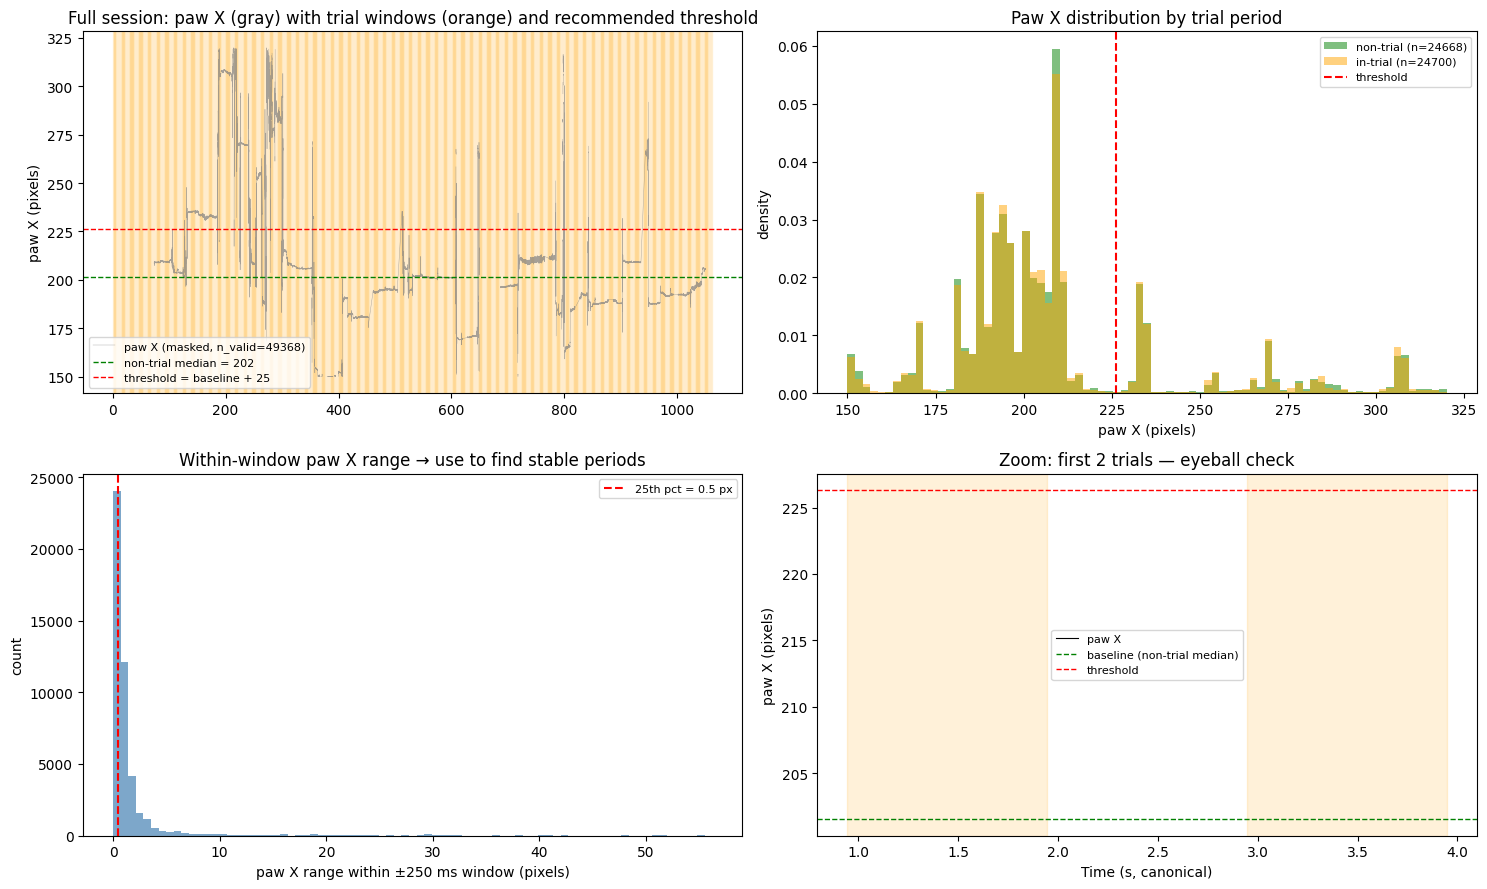


Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\reach_detection_diagnostic_2.png

RECOMMENDED PARAMETERS FOR CELL J
  AMPLITUDE_THRESH      = 24.8   # pixels above baseline
  STABILITY_THRESH      = 0.5   # max within-window range
  STABILITY_WIN_S       = 0.5   # sliding-window width
  PAW_X_VALID           = (150, 320)
  PAW_LIKELIHOOD_MIN    = 0.55
  BASELINE_INIT         = 201.5   # starting baseline X
  PELLET_MOTOR_PIN      = 3

Look at the diagnostic plot, especially the bottom-right zoom panel.
If the red threshold line cleanly separates baseline from reaches,
the recommended values are good. Otherwise tune and re-run.

===== CELL I COMPLETE =====



In [28]:
# ============================================================
# CELL I — REACH DETECTION DIAGNOSTIC (PORTABLE)
# ============================================================
# Examines paw kinematics to recommend detection parameters.
# Does NOT detect reaches — only prints/plots distributions
# that inform what thresholds to use in Cell J.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import uniform_filter1d

print("\n===== CELL I — REACH DETECTION DIAGNOSTIC =====")

# ------------------------------------------------------------
# USER EDIT — sanity bounds for paw X (mask anything outside)
# ------------------------------------------------------------
PAW_X_VALID = (150, 320)   # generous bounds; everything outside = mask out
PAW_LIKELIHOOD_MIN = 0.55  # DLC likelihood threshold
STABILITY_WIN_S = 0.5      # sliding-window width for "is paw stable?"
PELLET_MOTOR_PIN = 3
TRIAL_DURATION_S = 20.0    # expected window between pellet expose & retract
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# Load DLC + frame timing
dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
paw_x   = dlc["paw_x"].astype(float)
paw_y   = dlc["paw_y"].astype(float)
paw_lik = dlc["paw_likelihood"].astype(float)
n_frames = len(frame_t)

print(f"\nLoaded {n_frames} frames")
print(f"Time range: {frame_t[0]:.3f} → {frame_t[-1]:.3f} s")

# Estimate effective FPS from median frame interval
median_dt = float(np.median(np.diff(frame_t)))
fps = 1.0 / median_dt
print(f"Effective FPS (median Δt): {fps:.2f} Hz")

# ------------------------------------------------------------
# DROPPED-FRAME GAP DETECTION
# ------------------------------------------------------------
diffs = np.diff(frame_t)
gap_threshold = 1.5 * median_dt
gap_mask_per_diff = diffs > gap_threshold
n_gaps = int(gap_mask_per_diff.sum())
total_gap_time = float(diffs[gap_mask_per_diff].sum())
print(f"\nDropped-frame gaps (Δt > {gap_threshold*1000:.1f} ms): {n_gaps}")
print(f"Total time inside gaps: {total_gap_time:.1f} s "
      f"({100*total_gap_time/recording_duration:.1f}% of session)")
if n_gaps > 0:
    print(f"Gap durations: median={np.median(diffs[gap_mask_per_diff]):.3f} s, "
          f"max={diffs[gap_mask_per_diff].max():.3f} s")

# ------------------------------------------------------------
# MASKING: out-of-range OR low-likelihood
# ------------------------------------------------------------
valid = ((paw_x >= PAW_X_VALID[0]) & (paw_x <= PAW_X_VALID[1])
         & (paw_lik >= PAW_LIKELIHOOD_MIN))
n_valid = int(valid.sum())
print(f"\nFrame validity:")
print(f"  In range ({PAW_X_VALID[0]}-{PAW_X_VALID[1]}): "
      f"{int(((paw_x >= PAW_X_VALID[0]) & (paw_x <= PAW_X_VALID[1])).sum())} "
      f"/ {n_frames}")
print(f"  Likelihood ≥ {PAW_LIKELIHOOD_MIN}: "
      f"{int((paw_lik >= PAW_LIKELIHOOD_MIN).sum())} / {n_frames}")
print(f"  Both (kept for analysis): {n_valid} / {n_frames} "
      f"({100*n_valid/n_frames:.1f}%)")

# Build masked paw X (NaN where invalid)
paw_x_masked = paw_x.copy()
paw_x_masked[~valid] = np.nan

# ------------------------------------------------------------
# TRIAL WINDOWS FROM PIN 3
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
motor_times = np.load(ttls_dir / f"TTL_Pin_{PELLET_MOTOR_PIN}.npy")
print(f"\nPin {PELLET_MOTOR_PIN} (motor): {len(motor_times)} events")

if len(motor_times) % 2 != 0:
    print(f"  WARNING: odd number of motor events. "
          f"Last event ({motor_times[-1]:.3f} s) will be ignored.")
    motor_times = motor_times[:-1]

trial_starts = motor_times[0::2]   # pellet expose
trial_ends   = motor_times[1::2]   # pellet retract
trial_durs   = trial_ends - trial_starts
print(f"Trials: {len(trial_starts)}")
print(f"Trial durations: mean={trial_durs.mean():.3f} s, "
      f"std={trial_durs.std():.3f} s, "
      f"range {trial_durs.min():.3f} - {trial_durs.max():.3f} s")

if abs(trial_durs.mean() - TRIAL_DURATION_S) > 0.5:
    print(f"  WARNING: mean trial duration ({trial_durs.mean():.2f} s) "
          f"differs from expected ({TRIAL_DURATION_S} s) by >0.5 s. "
          f"Check that pin {PELLET_MOTOR_PIN} is the right pin.")

# ------------------------------------------------------------
# CHARACTERIZE NON-TRIAL "BASELINE-ONLY" PERIODS
# ------------------------------------------------------------
# Find frames that are NOT inside any trial window — these should be
# mostly paw-at-rest periods that characterize the baseline distribution.
# ------------------------------------------------------------
in_trial = np.zeros(n_frames, dtype=bool)
for ts, te in zip(trial_starts, trial_ends):
    in_trial |= (frame_t >= ts) & (frame_t <= te)
non_trial_valid = valid & ~in_trial
print(f"\nFrames outside trial windows (and valid): "
      f"{int(non_trial_valid.sum())} / {n_frames}")

baseline_x_samples = paw_x[non_trial_valid]
if len(baseline_x_samples) > 100:
    bx_median = float(np.median(baseline_x_samples))
    bx_p5  = float(np.percentile(baseline_x_samples, 5))
    bx_p95 = float(np.percentile(baseline_x_samples, 95))
    bx_iqr = float(np.percentile(baseline_x_samples, 75)
                   - np.percentile(baseline_x_samples, 25))
    print(f"Non-trial paw X: median={bx_median:.1f}, "
          f"5–95th pct=[{bx_p5:.1f}, {bx_p95:.1f}], IQR={bx_iqr:.1f}")
else:
    print("Not enough non-trial frames — using full session as baseline reference.")
    baseline_x_samples = paw_x[valid]
    bx_median = float(np.median(baseline_x_samples))
    bx_iqr = float(np.percentile(baseline_x_samples, 75)
                   - np.percentile(baseline_x_samples, 25))

# ------------------------------------------------------------
# IN-TRIAL PAW X DISTRIBUTION (REACHES + REST)
# ------------------------------------------------------------
in_trial_valid = valid & in_trial
trial_x_samples = paw_x[in_trial_valid]
if len(trial_x_samples) > 100:
    tx_median = float(np.median(trial_x_samples))
    tx_p95   = float(np.percentile(trial_x_samples, 95))
    tx_p99   = float(np.percentile(trial_x_samples, 99))
    print(f"In-trial paw X: median={tx_median:.1f}, "
          f"95th pct={tx_p95:.1f}, 99th pct={tx_p99:.1f}")

# ------------------------------------------------------------
# STABILITY WINDOW: distribution of within-window range
# ------------------------------------------------------------
# For each frame, compute the range (max - min) of paw X in a window of
# ±STABILITY_WIN_S/2 around it. Use only valid frames.
# ------------------------------------------------------------
print(f"\nComputing stability metric (range of paw X in ±{STABILITY_WIN_S/2*1000:.0f} ms window)...")
win_frames = max(3, int(round(STABILITY_WIN_S * fps)))
half = win_frames // 2

# For speed, compute rolling max and min on the masked array
# (NaN-aware would be ideal but slow; we replace NaN with a sentinel and
# discard ranges where any NaN appears)
sentinel = np.inf
x_for_range = np.where(valid, paw_x, sentinel)
roll_max = np.empty_like(paw_x)
roll_min = np.empty_like(paw_x)
roll_max[:] = np.nan
roll_min[:] = np.nan
# Brute-force is fine here for ~100k frames
print(f"  Rolling window ({win_frames} frames)...")
for i in range(half, n_frames - half):
    window = x_for_range[i - half : i + half + 1]
    if np.isinf(window).any():
        continue
    roll_max[i] = window.max()
    roll_min[i] = window.min()

roll_range = roll_max - roll_min
valid_range = roll_range[~np.isnan(roll_range)]
print(f"  Frames with valid stability metric: {len(valid_range)}")
if len(valid_range) > 0:
    print(f"  Within-window range distribution (pixels):")
    for pct in [10, 25, 50, 75, 90]:
        print(f"    {pct}th pct: {np.percentile(valid_range, pct):.2f}")
    stable_thresh_recommended = float(np.percentile(valid_range, 25))
    print(f"  → Recommended stability threshold (25th pct): "
          f"{stable_thresh_recommended:.2f} pixels")

# ------------------------------------------------------------
# RECOMMENDED REACH AMPLITUDE THRESHOLD
# ------------------------------------------------------------
# A reach is "X excursion above baseline" where the baseline is the
# resting position. A reasonable threshold: 0.3 × (in-trial 95th pct
# minus non-trial median). This is roughly 30% of the typical reach
# amplitude — large enough to ignore baseline jitter, small enough to
# catch most movements.
# ------------------------------------------------------------
if len(trial_x_samples) > 100 and len(baseline_x_samples) > 100:
    typical_reach_amp = tx_p95 - bx_median
    amp_thresh_recommended = 0.3 * typical_reach_amp
    print(f"\nReach amplitude analysis:")
    print(f"  Non-trial baseline (median X): {bx_median:.1f} pixels")
    print(f"  In-trial 95th pct X:           {tx_p95:.1f} pixels")
    print(f"  Typical reach amplitude:        {typical_reach_amp:.1f} pixels")
    print(f"  → Recommended threshold (0.3 ×): {amp_thresh_recommended:.1f} pixels")
    print(f"     (your old default was +25 pixels)")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# (1) Paw X over full session, color-coded by trial
ax = axes[0, 0]
ax.plot(frame_t, paw_x_masked, lw=0.3, color="gray", alpha=0.7,
        label=f"paw X (masked, n_valid={n_valid})")
for ts, te in zip(trial_starts, trial_ends):
    ax.axvspan(ts, te, alpha=0.15, color="orange")
ax.axhline(bx_median, color="green", lw=1.0, linestyle="--",
           label=f"non-trial median = {bx_median:.0f}")
ax.axhline(bx_median + amp_thresh_recommended, color="red", lw=1.0,
           linestyle="--",
           label=f"threshold = baseline + {amp_thresh_recommended:.0f}")
ax.set_ylabel("paw X (pixels)")
ax.set_title("Full session: paw X (gray) with trial windows (orange) "
             "and recommended threshold")
ax.legend(fontsize=8)

# (2) Histogram of paw X — non-trial vs in-trial
ax = axes[0, 1]
bins = np.linspace(PAW_X_VALID[0], PAW_X_VALID[1], 80)
ax.hist(baseline_x_samples, bins=bins, alpha=0.5, color="green",
        label=f"non-trial (n={len(baseline_x_samples)})", density=True)
ax.hist(trial_x_samples, bins=bins, alpha=0.5, color="orange",
        label=f"in-trial (n={len(trial_x_samples)})", density=True)
ax.axvline(bx_median + amp_thresh_recommended, color="red", lw=1.5,
           linestyle="--", label="threshold")
ax.set_xlabel("paw X (pixels)")
ax.set_ylabel("density")
ax.set_title("Paw X distribution by trial period")
ax.legend(fontsize=8)

# (3) Histogram of within-window range (stability metric)
ax = axes[1, 0]
if len(valid_range) > 0:
    bins = np.linspace(0, np.percentile(valid_range, 99), 80)
    ax.hist(valid_range, bins=bins, color="steelblue", alpha=0.7)
    ax.axvline(stable_thresh_recommended, color="red", lw=1.5, linestyle="--",
               label=f"25th pct = {stable_thresh_recommended:.1f} px")
    ax.set_xlabel(f"paw X range within ±{STABILITY_WIN_S/2*1000:.0f} ms window (pixels)")
    ax.set_ylabel("count")
    ax.set_title("Within-window paw X range → use to find stable periods")
    ax.legend(fontsize=8)

# (4) Zoom on first 2 trials
ax = axes[1, 1]
if len(trial_starts) >= 1:
    ts0 = trial_starts[0] - 3
    te0 = (trial_ends[1] + 3) if len(trial_ends) > 1 else trial_ends[0] + 5
    zoom_mask = (frame_t >= ts0) & (frame_t <= te0)
    ax.plot(frame_t[zoom_mask], paw_x_masked[zoom_mask], lw=0.8, color="black",
            label="paw X")
    for ts, te in zip(trial_starts[:2], trial_ends[:2]):
        ax.axvspan(ts, te, alpha=0.15, color="orange")
    ax.axhline(bx_median, color="green", lw=1.0, linestyle="--",
               label="baseline (non-trial median)")
    ax.axhline(bx_median + amp_thresh_recommended, color="red", lw=1.0,
               linestyle="--", label="threshold")
    ax.set_xlabel("Time (s, canonical)")
    ax.set_ylabel("paw X (pixels)")
    ax.set_title("Zoom: first 2 trials — eyeball check")
    ax.legend(fontsize=8)

plt.tight_layout()

# Save
out_path = analysis_folder / "qc" / "reach_detection_diagnostic.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"reach_detection_diagnostic_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# RECOMMENDATIONS SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RECOMMENDED PARAMETERS FOR CELL J")
print("=" * 60)
print(f"  AMPLITUDE_THRESH      = {amp_thresh_recommended:.1f}   # pixels above baseline")
print(f"  STABILITY_THRESH      = {stable_thresh_recommended:.1f}   # max within-window range")
print(f"  STABILITY_WIN_S       = {STABILITY_WIN_S}   # sliding-window width")
print(f"  PAW_X_VALID           = {PAW_X_VALID}")
print(f"  PAW_LIKELIHOOD_MIN    = {PAW_LIKELIHOOD_MIN}")
print(f"  BASELINE_INIT         = {bx_median:.1f}   # starting baseline X")
print(f"  PELLET_MOTOR_PIN      = {PELLET_MOTOR_PIN}")
print()
print("Look at the diagnostic plot, especially the bottom-right zoom panel.")
print("If the red threshold line cleanly separates baseline from reaches,")
print("the recommended values are good. Otherwise tune and re-run.")
print()
print("===== CELL I COMPLETE =====\n")


===== CELL J — REACH DETECTION (v3) =====
Loaded 53839 frames, FPS=60.0
Trials: 39
IR beam breaks (pin 6): 538

Validity layers:
  In bounds:                49833 / 53839 (92.6%)
  Likelihood ≥ 0.5:         53368 / 53839 (99.1%)
  Jump filter (>50 px from prev good): computing...
  Frames flagged as jumps: 20
  Final valid:              49502 / 53839 (91.9%)

Computing rolling stability (0.5s window, threshold ≤0.5 px)...
Stable frames: 14024 / 53839 (26.0%)

Building running baseline (lookback 3.0s, extending to 10.0s if needed)...
Global fallback baseline (median of stable frames): 201.4 px
Frames with valid local baseline: 39568 / 53839 (73.5%)
Frames using global-fallback baseline: 14271 (26.5%)

Detecting reaches...
Candidate threshold-crossings: 216
Detected reaches: 1032

Clustering into bouts (merge window 0.8s)...
Reaches grouped into 36 bouts
Reaches against global-fallback baseline: 860 / 1032 (check these manually if many)

Saved reaches → G:\Kevin\2026-03-17_14-26-00\Reco

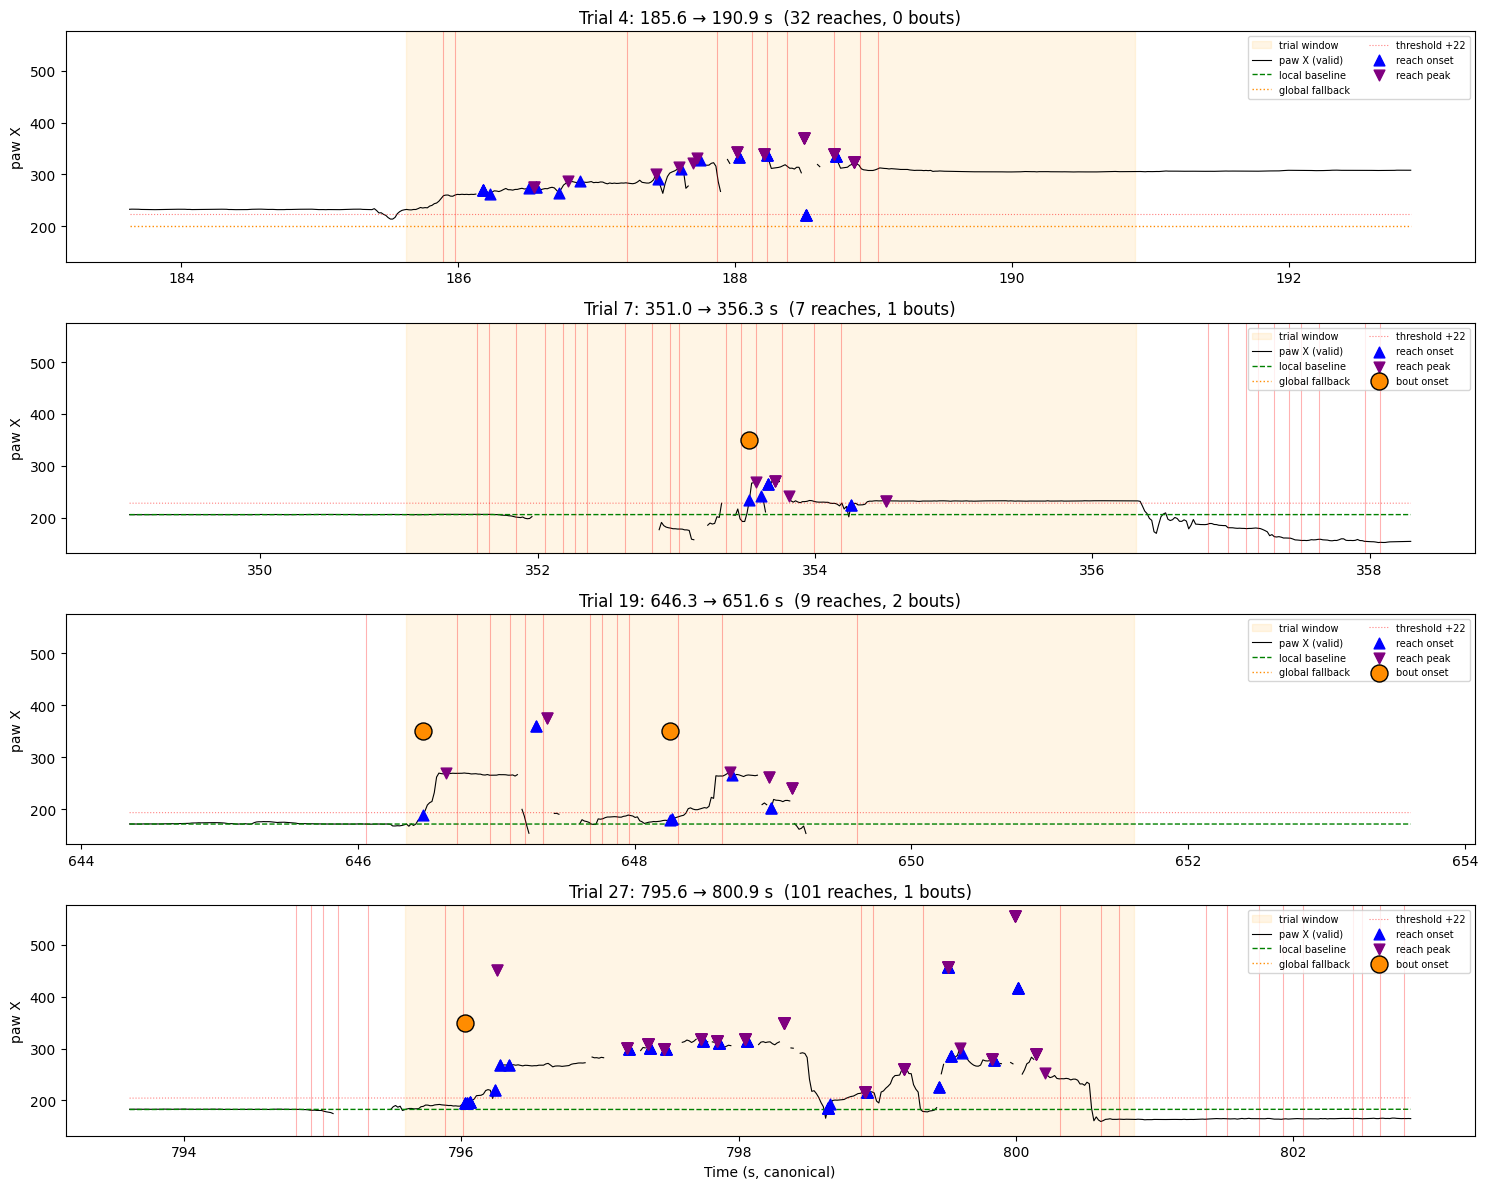

Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\reach_detection_examples_v3_1.png

===== SUMMARY =====
  Likelihood threshold:        ≥ 0.5
  Stability threshold:         ≤ 0.5 px
  Jump filter:                 < 50 px / frame
  Final valid frame %:         91.9%
  Stable frames %:             26.0%
  Local-baseline frames %:     73.5%
  Global-fallback frames %:    26.5%

  Total reaches:               1032
   ...against global baseline: 860
  Bouts:                       36
  Reaches per trial (mean):    4.13
  Bouts per trial (mean):      0.15
  Trials with ≥1 reach:        6 / 39

  In-trial reaches:            161
  Out-of-trial reaches:        871
  Beam-breaking reaches:       957

===== CELL J v3 COMPLETE =====



In [29]:
# ============================================================
# CELL J — REACH DETECTION (PORTABLE) — v3
# ============================================================
# Changes from v2:
#   - Stability threshold raised from 0.7 to 2.0 (tolerates DLC jitter)
#   - BASELINE_MIN_STABLE lowered from 5 to 3 (faster cold-start)
#   - Global-fallback baseline for frames with no nearby stable period
#   - Reaches tagged with whether they used local or global baseline
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL J — REACH DETECTION (v3) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
AMPLITUDE_THRESH    = 22.0      # pixels above local baseline
STABILITY_THRESH    = 0.5       # max within-window range to count as "stable"
STABILITY_WIN_S     = 0.5       # window for stability check
PAW_X_VALID         = (150, 330)
PAW_LIKELIHOOD_MIN  = 0.5
MAX_JUMP_PX         = 50.0

BASELINE_LOOKBACK_S = 3.0
BASELINE_MIN_STABLE = 3
BASELINE_EXTEND_S   = 10.0

MERGE_WINDOW_S      = 0.8
ONSET_FRAC          = 0.10
PEAK_SEARCH_S       = 1.5

PELLET_MOTOR_PIN    = 5
IR_BEAM_PIN         = 6
IR_BEAM_TOLERANCE_S = 0.5
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
paw_x   = dlc["paw_x"].astype(float)
paw_y   = dlc["paw_y"].astype(float)
paw_lik = dlc["paw_likelihood"].astype(float)
n_frames = len(frame_t)
fps = 1.0 / float(np.median(np.diff(frame_t)))
print(f"Loaded {n_frames} frames, FPS={fps:.1f}")

ttls_dir = analysis_folder / "ttls"
motor_times = np.load(ttls_dir / f"TTL_Pin_{PELLET_MOTOR_PIN}.npy")
if len(motor_times) % 2 != 0:
    motor_times = motor_times[:-1]
trial_starts = motor_times[0::2]
trial_ends   = motor_times[1::2]
print(f"Trials: {len(trial_starts)}")

beam_times = np.load(ttls_dir / f"TTL_Pin_{IR_BEAM_PIN}.npy")
print(f"IR beam breaks (pin {IR_BEAM_PIN}): {len(beam_times)}")

# ------------------------------------------------------------
# VALIDITY
# ------------------------------------------------------------
in_bounds     = (paw_x >= PAW_X_VALID[0]) & (paw_x <= PAW_X_VALID[1])
likelihood_ok = paw_lik >= PAW_LIKELIHOOD_MIN

print(f"\nValidity layers:")
print(f"  In bounds:               {int(in_bounds.sum()):6d} / {n_frames} "
      f"({100*in_bounds.sum()/n_frames:.1f}%)")
print(f"  Likelihood ≥ {PAW_LIKELIHOOD_MIN}:        "
      f"{int(likelihood_ok.sum()):6d} / {n_frames} "
      f"({100*likelihood_ok.sum()/n_frames:.1f}%)")
print(f"  Jump filter (>{MAX_JUMP_PX:.0f} px from prev good): computing...")

jump_ok = np.ones(n_frames, dtype=bool)
last_good_idx = None
n_jumps = 0
for i in range(n_frames):
    if not (in_bounds[i] and likelihood_ok[i]):
        jump_ok[i] = False
        continue
    if last_good_idx is None:
        last_good_idx = i
        continue
    dx = paw_x[i] - paw_x[last_good_idx]
    dy = paw_y[i] - paw_y[last_good_idx]
    disp = (dx * dx + dy * dy) ** 0.5
    dt = frame_t[i] - frame_t[last_good_idx]
    max_allowed = MAX_JUMP_PX * max(1.0, dt * fps)
    if disp > max_allowed:
        jump_ok[i] = False
        n_jumps += 1
    else:
        last_good_idx = i

print(f"  Frames flagged as jumps: {n_jumps}")

valid = in_bounds & likelihood_ok & jump_ok
print(f"  Final valid:             {int(valid.sum()):6d} / {n_frames} "
      f"({100*valid.sum()/n_frames:.1f}%)")

# ------------------------------------------------------------
# STABILITY DETECTOR
# ------------------------------------------------------------
print(f"\nComputing rolling stability ({STABILITY_WIN_S}s window, "
      f"threshold ≤{STABILITY_THRESH} px)...")
win_frames = max(3, int(round(STABILITY_WIN_S * fps)))
half = win_frames // 2

sentinel = np.inf
x_safe = np.where(valid, paw_x, sentinel)

is_stable = np.zeros(n_frames, dtype=bool)
for i in range(half, n_frames - half):
    window = x_safe[i - half : i + half + 1]
    if np.isinf(window).any():
        continue
    if (window.max() - window.min()) <= STABILITY_THRESH:
        is_stable[i] = True

n_stable = int(is_stable.sum())
print(f"Stable frames: {n_stable} / {n_frames} ({100*n_stable/n_frames:.1f}%)")

# ------------------------------------------------------------
# RUNNING LOCAL BASELINE (with global fallback)
# ------------------------------------------------------------
print(f"\nBuilding running baseline (lookback {BASELINE_LOOKBACK_S}s, "
      f"extending to {BASELINE_EXTEND_S}s if needed)...")

stable_indices = np.where(is_stable)[0]
stable_times = frame_t[stable_indices]
stable_x = paw_x[stable_indices]

# Global fallback = median of all stable frames
if len(stable_x) >= BASELINE_MIN_STABLE:
    global_baseline = float(np.median(stable_x))
    print(f"Global fallback baseline (median of stable frames): "
          f"{global_baseline:.1f} px")
else:
    global_baseline = float(np.median(paw_x[valid]))
    print(f"Not enough stable frames for global fallback. "
          f"Using median of valid frames: {global_baseline:.1f} px")

baseline = np.full(n_frames, np.nan)

for i in range(n_frames):
    t_now = frame_t[i]
    lo = t_now - BASELINE_LOOKBACK_S
    mask = (stable_times >= lo) & (stable_times <= t_now)
    if mask.sum() < BASELINE_MIN_STABLE:
        lo = t_now - BASELINE_EXTEND_S
        mask = (stable_times >= lo) & (stable_times <= t_now)
    if mask.sum() >= BASELINE_MIN_STABLE:
        baseline[i] = np.median(stable_x[mask])

n_with_local = int(np.sum(~np.isnan(baseline)))
print(f"Frames with valid local baseline: {n_with_local} / {n_frames} "
      f"({100*n_with_local/n_frames:.1f}%)")

# Fill NaNs with global fallback (and mark them)
baseline_is_global = np.isnan(baseline)
baseline[baseline_is_global] = global_baseline
n_using_global = int(baseline_is_global.sum())
print(f"Frames using global-fallback baseline: {n_using_global} "
      f"({100*n_using_global/n_frames:.1f}%)")

# ------------------------------------------------------------
# REACH DETECTION
# ------------------------------------------------------------
print("\nDetecting reaches...")

excursion = paw_x - baseline
above_threshold = (excursion > AMPLITUDE_THRESH) & valid

padded = np.concatenate([[False], above_threshold, [False]])
diffs = np.diff(padded.astype(int))
run_starts = np.where(diffs == 1)[0]
run_ends   = np.where(diffs == -1)[0] - 1

print(f"Candidate threshold-crossings: {len(run_starts)}")

reach_onset_t, reach_peak_t = [], []
reach_amp, reach_baseline_at_onset = [], []
reach_frame_onset, reach_frame_peak = [], []

from scipy.signal import find_peaks

reach_onset_t, reach_peak_t = [], []
reach_amp, reach_baseline_at_onset = [], []
reach_frame_onset, reach_frame_peak = [], []

# Minimum prominence for a peak to count as a separate reach (in pixels above
# the surrounding minima). Higher → fewer detected sub-peaks within a run.
MIN_PEAK_PROMINENCE_PX = 8.0
# Minimum separation between adjacent peaks (in frames)
MIN_PEAK_SEPARATION_S  = 0.10
min_peak_sep_frames = max(1, int(round(MIN_PEAK_SEPARATION_S * fps)))

for r_start, r_end in zip(run_starts, run_ends):
    extend_frames = int(round(PEAK_SEARCH_S * fps))
    search_end = min(n_frames - 1, max(r_end, r_start + extend_frames))
    seg = excursion[r_start:search_end + 1]
    seg_clean = np.where(np.isnan(seg), -np.inf, seg)
    if seg_clean.size == 0:
        continue

    # Find ALL prominent peaks within this run
    peak_offsets, props = find_peaks(seg_clean,
                                      prominence=MIN_PEAK_PROMINENCE_PX,
                                      distance=min_peak_sep_frames)
    # Always include the global argmax even if it didn't pass prominence
    # (handles small isolated reaches with no flanking dips)
    global_argmax = int(np.argmax(seg_clean))
    if global_argmax not in peak_offsets:
        peak_offsets = np.append(peak_offsets, global_argmax)
        peak_offsets.sort()

    for peak_offset in peak_offsets:
        peak_idx = r_start + int(peak_offset)
        peak_amp_val = excursion[peak_idx]
        if not np.isfinite(peak_amp_val) or peak_amp_val < AMPLITUDE_THRESH:
            continue

        # Walk back to onset, but stop at the previous detected peak
        # within this run if there is one (don't walk through it)
        prev_peaks_in_run = [r_start + int(p) for p in peak_offsets
                              if p < peak_offset]
        walk_floor = max(0, peak_idx - int(2.0 * fps))
        if prev_peaks_in_run:
            walk_floor = max(walk_floor, prev_peaks_in_run[-1] + 1)

        onset_thresh = ONSET_FRAC * peak_amp_val
        onset_idx = peak_idx
        for j in range(peak_idx, walk_floor - 1, -1):
            if np.isnan(excursion[j]) or excursion[j] < onset_thresh:
                onset_idx = j + 1
                break
            onset_idx = j

        reach_onset_t.append(float(frame_t[onset_idx]))
        reach_peak_t.append(float(frame_t[peak_idx]))
        reach_amp.append(float(peak_amp_val))
        reach_baseline_at_onset.append(float(baseline[onset_idx]))
        reach_frame_onset.append(int(onset_idx))
        reach_frame_peak.append(int(peak_idx))

reach_onset_t = np.array(reach_onset_t)
reach_peak_t  = np.array(reach_peak_t)
reach_amp     = np.array(reach_amp)
reach_baseline_at_onset = np.array(reach_baseline_at_onset)
reach_frame_onset = np.array(reach_frame_onset)
reach_frame_peak  = np.array(reach_frame_peak)

print(f"Detected reaches: {len(reach_onset_t)}")

# ------------------------------------------------------------
# BOUT CLUSTERING
# ------------------------------------------------------------
print(f"\nClustering into bouts (merge window {MERGE_WINDOW_S}s)...")

if len(reach_onset_t) > 0:
    bout_id = np.zeros(len(reach_onset_t), dtype=int)
    for i in range(1, len(reach_onset_t)):
        if reach_onset_t[i] - reach_peak_t[i - 1] <= MERGE_WINDOW_S:
            bout_id[i] = bout_id[i - 1]
        else:
            bout_id[i] = bout_id[i - 1] + 1
    n_bouts = int(bout_id.max()) + 1
else:
    bout_id = np.array([], dtype=int)
    n_bouts = 0

print(f"Reaches grouped into {n_bouts} bouts")

# ------------------------------------------------------------
# TRIAL TAGGING
# ------------------------------------------------------------
reach_trial_id = np.full(len(reach_onset_t), -1, dtype=int)
for t_i, (ts, te) in enumerate(zip(trial_starts, trial_ends)):
    in_trial = (reach_onset_t >= ts) & (reach_onset_t <= te)
    reach_trial_id[in_trial] = t_i

# ------------------------------------------------------------
# BEAM TAGGING
# ------------------------------------------------------------
reach_broke_beam = np.zeros(len(reach_peak_t), dtype=bool)
for i, t_peak in enumerate(reach_peak_t):
    if len(beam_times) and np.any(np.abs(beam_times - t_peak) < IR_BEAM_TOLERANCE_S):
        reach_broke_beam[i] = True

# ------------------------------------------------------------
# FLAG REACHES DETECTED AGAINST GLOBAL-FALLBACK BASELINE
# ------------------------------------------------------------
if len(reach_frame_onset) > 0:
    reach_baseline_was_global = baseline_is_global[reach_frame_onset]
else:
    reach_baseline_was_global = np.array([], dtype=bool)
n_global_baseline_reaches = int(reach_baseline_was_global.sum())
print(f"Reaches against global-fallback baseline: "
      f"{n_global_baseline_reaches} / {len(reach_onset_t)} "
      f"(check these manually if many)")

# ------------------------------------------------------------
# BOUT-LEVEL SUMMARY
# ------------------------------------------------------------
bout_onset_t    = np.zeros(n_bouts)
bout_peak_t     = np.zeros(n_bouts)
bout_max_amp    = np.zeros(n_bouts)
bout_n_reaches  = np.zeros(n_bouts, dtype=int)
bout_trial_id   = np.full(n_bouts, -1, dtype=int)
bout_broke_beam = np.zeros(n_bouts, dtype=bool)
bout_used_global_baseline = np.zeros(n_bouts, dtype=bool)

for b in range(n_bouts):
    mask = bout_id == b
    bout_onset_t[b]   = reach_onset_t[mask].min()
    bout_max_amp[b]   = reach_amp[mask].max()
    bout_peak_t[b]    = reach_peak_t[mask][np.argmax(reach_amp[mask])]
    bout_n_reaches[b] = int(mask.sum())
    bout_trial_id[b]  = reach_trial_id[mask][0]
    bout_broke_beam[b] = bool(reach_broke_beam[mask].any())
    bout_used_global_baseline[b] = bool(reach_baseline_was_global[mask].any())

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
reaches_dir = analysis_folder / "peak_detection"
reaches_dir.mkdir(exist_ok=True)

np.savez(reaches_dir / "reaches.npz",
         onset_t=reach_onset_t,
         peak_t=reach_peak_t,
         amplitude=reach_amp,
         baseline_at_onset=reach_baseline_at_onset,
         frame_onset=reach_frame_onset,
         frame_peak=reach_frame_peak,
         bout_id=bout_id,
         trial_id=reach_trial_id,
         broke_beam=reach_broke_beam,
         baseline_was_global=reach_baseline_was_global)

np.savez(reaches_dir / "bouts.npz",
         onset_t=bout_onset_t,
         peak_t=bout_peak_t,
         max_amplitude=bout_max_amp,
         n_reaches=bout_n_reaches,
         trial_id=bout_trial_id,
         broke_beam=bout_broke_beam,
         used_global_baseline=bout_used_global_baseline)

np.save(reaches_dir / "running_baseline.npy", baseline)
np.save(reaches_dir / "baseline_is_global.npy", baseline_is_global)
np.save(reaches_dir / "frame_valid.npy", valid)

meta = {
    "n_reaches":                int(len(reach_onset_t)),
    "n_bouts":                  int(n_bouts),
    "n_in_trial":               int((reach_trial_id >= 0).sum()),
    "n_out_of_trial":           int((reach_trial_id == -1).sum()),
    "n_beam_breaking":          int(reach_broke_beam.sum()),
    "n_global_baseline":        int(n_global_baseline_reaches),
    "n_bouts_in_trial":         int((bout_trial_id >= 0).sum()),
    "n_bouts_out_of_trial":     int((bout_trial_id == -1).sum()),
    "n_bouts_beam_breaking":    int(bout_broke_beam.sum()),
    "trial_count":              int(len(trial_starts)),
    "trials_with_reaches":      int(len(np.unique(reach_trial_id[reach_trial_id >= 0]))),
    "params": {
        "amplitude_thresh_px":   float(AMPLITUDE_THRESH),
        "stability_thresh_px":   float(STABILITY_THRESH),
        "stability_win_s":       float(STABILITY_WIN_S),
        "paw_x_valid":           list(PAW_X_VALID),
        "paw_likelihood_min":    float(PAW_LIKELIHOOD_MIN),
        "max_jump_px":           float(MAX_JUMP_PX),
        "baseline_lookback_s":   float(BASELINE_LOOKBACK_S),
        "baseline_extend_s":     float(BASELINE_EXTEND_S),
        "baseline_min_stable":   int(BASELINE_MIN_STABLE),
        "merge_window_s":        float(MERGE_WINDOW_S),
        "onset_frac":            float(ONSET_FRAC),
        "peak_search_s":         float(PEAK_SEARCH_S),
        "ir_beam_tolerance_s":   float(IR_BEAM_TOLERANCE_S),
    }
}
with open(reaches_dir / "reaches_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"\nSaved reaches → {reaches_dir / 'reaches.npz'}")
print(f"Saved bouts   → {reaches_dir / 'bouts.npz'}")

# ------------------------------------------------------------
# DIAGNOSTIC PLOTS
# ------------------------------------------------------------
print("\nPlotting diagnostics...")

trials_with_reaches = np.unique(reach_trial_id[reach_trial_id >= 0])
if len(trials_with_reaches) > 0:
    plot_trial_idx = trials_with_reaches[
        np.linspace(0, len(trials_with_reaches) - 1,
                    min(4, len(trials_with_reaches))).astype(int)
    ]
else:
    plot_trial_idx = np.arange(min(4, len(trial_starts)))

fig, axes = plt.subplots(len(plot_trial_idx), 1,
                         figsize=(15, 3 * len(plot_trial_idx)),
                         sharey=True)
if len(plot_trial_idx) == 1:
    axes = [axes]

paw_x_masked = paw_x.copy()
paw_x_masked[~valid] = np.nan

for ax, t_i in zip(axes, plot_trial_idx):
    ts, te = trial_starts[t_i], trial_ends[t_i]
    pad = 2.0
    mask = (frame_t >= ts - pad) & (frame_t <= te + pad)

    ax.axvspan(ts, te, alpha=0.10, color="orange", label="trial window")
    ax.plot(frame_t[mask], paw_x_masked[mask], lw=0.8, color="black",
            label="paw X (valid)")
    # baseline: solid where local, dotted where global
    bl = baseline[mask].copy()
    bg = baseline_is_global[mask]
    bl_local = bl.copy();  bl_local[bg]  = np.nan
    bl_global = bl.copy(); bl_global[~bg] = np.nan
    ax.plot(frame_t[mask], bl_local, lw=1.0, color="green",
            linestyle="--", label="local baseline")
    ax.plot(frame_t[mask], bl_global, lw=1.0, color="darkorange",
            linestyle=":", label="global fallback")
    ax.plot(frame_t[mask], baseline[mask] + AMPLITUDE_THRESH, lw=0.8,
            color="red", linestyle=":", alpha=0.5,
            label=f"threshold +{AMPLITUDE_THRESH:.0f}")

    in_this = reach_trial_id == t_i
    if in_this.any():
        ax.scatter(reach_onset_t[in_this],
                   paw_x[reach_frame_onset[in_this]],
                   marker="^", color="blue", s=60, zorder=10, label="reach onset")
        ax.scatter(reach_peak_t[in_this],
                   paw_x[reach_frame_peak[in_this]],
                   marker="v", color="purple", s=60, zorder=10, label="reach peak")

    bouts_in_trial = np.where(bout_trial_id == t_i)[0]
    if len(bouts_in_trial):
        ax.scatter(bout_onset_t[bouts_in_trial],
                   np.full(len(bouts_in_trial), 350),
                   marker="o", color="darkorange", s=150, zorder=11,
                   edgecolor="black", label="bout onset")

    beam_in_window = beam_times[(beam_times >= ts - pad) & (beam_times <= te + pad)]
    for bt in beam_in_window:
        ax.axvline(bt, color="red", alpha=0.3, lw=0.8)

    n_b = len(bouts_in_trial)
    n_r = int(in_this.sum())
    ax.set_title(f"Trial {t_i}: {ts:.1f} → {te:.1f} s  "
                 f"({n_r} reaches, {n_b} bouts)")
    ax.set_ylabel("paw X")
    ax.legend(fontsize=7, loc="upper right", ncol=2)

axes[-1].set_xlabel("Time (s, canonical)")
plt.tight_layout()
out_path = analysis_folder / "qc" / "reach_detection_examples_v3.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"reach_detection_examples_v3_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"  Likelihood threshold:        ≥ {PAW_LIKELIHOOD_MIN}")
print(f"  Stability threshold:         ≤ {STABILITY_THRESH} px")
print(f"  Jump filter:                 < {MAX_JUMP_PX:.0f} px / frame")
print(f"  Final valid frame %:         {100*valid.sum()/n_frames:.1f}%")
print(f"  Stable frames %:             {100*n_stable/n_frames:.1f}%")
print(f"  Local-baseline frames %:     {100*n_with_local/n_frames:.1f}%")
print(f"  Global-fallback frames %:    {100*n_using_global/n_frames:.1f}%")
print(f"")
print(f"  Total reaches:               {len(reach_onset_t)}")
print(f"   ...against global baseline: {n_global_baseline_reaches}")
print(f"  Bouts:                       {n_bouts}")
print(f"  Reaches per trial (mean):    {(reach_trial_id >= 0).sum() / max(len(trial_starts), 1):.2f}")
print(f"  Bouts per trial (mean):      {(bout_trial_id >= 0).sum() / max(len(trial_starts), 1):.2f}")
print(f"  Trials with ≥1 reach:        {len(trials_with_reaches)} / {len(trial_starts)}")
print(f"")
print(f"  In-trial reaches:            {(reach_trial_id >= 0).sum()}")
print(f"  Out-of-trial reaches:        {(reach_trial_id == -1).sum()}")
print(f"  Beam-breaking reaches:       {reach_broke_beam.sum()}")

print("\n===== CELL J v3 COMPLETE =====\n")


===== CELL K — REACH-ALIGNED KINEMATIC AVERAGE =====
Loaded 36 bouts

Subset sizes:
  all                 : 36
  in_trial            : 6
  out_of_trial        : 30
  beam_breaking       : 29
  in_trial_first      : 5

Building aligned traces (2.0s pre to 5.0s post, resampled to 60.0 fps)...

Usable traces per subset:
  all                 : 33 / 36
  in_trial            : 4 / 6
  out_of_trial        : 29 / 30
  beam_breaking       : 26 / 29
  in_trial_first      : 4 / 5

Plotting...


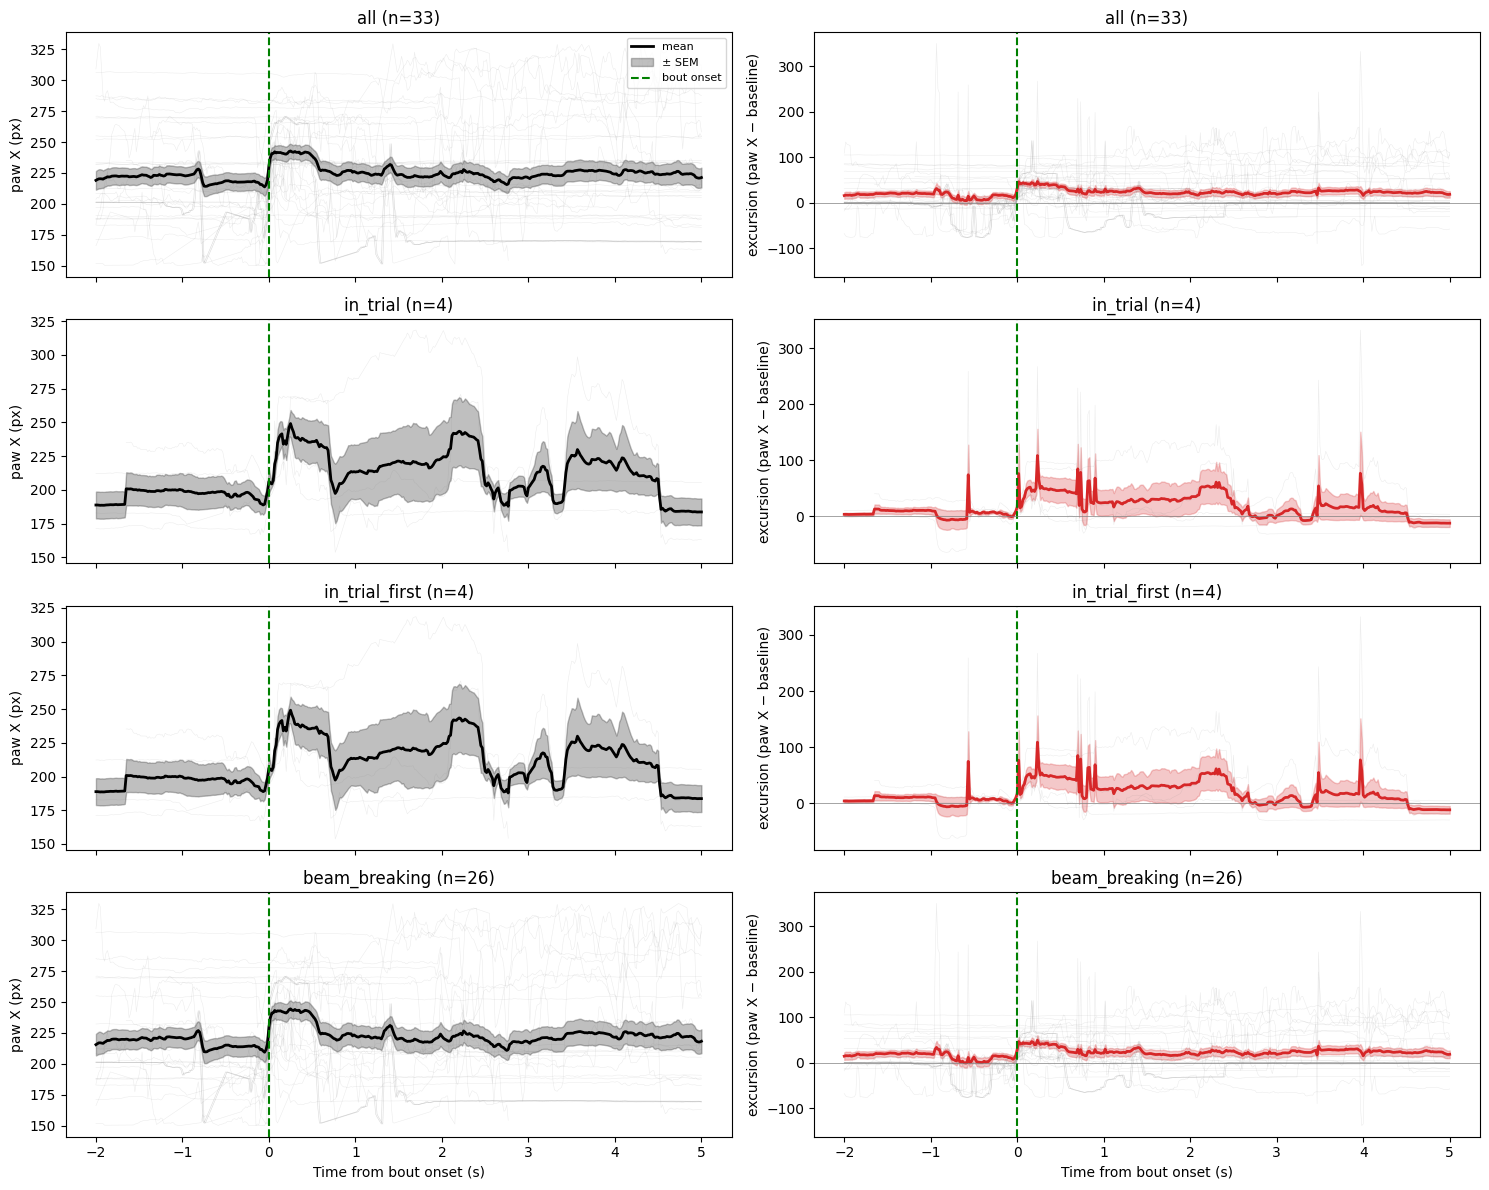

Saved → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\kinematic_average.png
Saved kinematic traces → G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis\peak_detection\kinematic_traces.npz

===== CELL K COMPLETE =====



In [30]:
# ============================================================
# CELL K — REACH-ALIGNED KINEMATIC AVERAGE (PORTABLE)
# ============================================================
# For each subset of bouts, plot the average paw kinematic trace
# around bout onset (mean ± SEM, with overlay of all individual
# traces in faint gray). This is the diagnostic that tells us if
# bouts are stereotyped enough for clean neural alignment.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL K — REACH-ALIGNED KINEMATIC AVERAGE =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
WIN_PRE         = 2.0          # seconds before bout onset
WIN_POST        = 5.0          # seconds after
RESAMPLE_FPS    = 60.0         # interpolate to this grid (matches video)
MAX_TRACE_GAP_S = 0.5          # tolerate gaps up to this; longer → drop trace
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
paw_x   = dlc["paw_x"].astype(float)
paw_y   = dlc["paw_y"].astype(float)

valid = np.load(analysis_folder / "peak_detection" / "frame_valid.npy")
baseline = np.load(analysis_folder / "peak_detection" / "running_baseline.npy")

bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t   = bouts["onset_t"]
bout_trial_id  = bouts["trial_id"]
bout_broke_beam = bouts["broke_beam"]

print(f"Loaded {len(bout_onset_t)} bouts")

# Subset definitions
subsets = {
    "all":             np.ones(len(bout_onset_t), dtype=bool),
    "in_trial":        bout_trial_id >= 0,
    "out_of_trial":    bout_trial_id == -1,
    "beam_breaking":   bout_broke_beam,
    "in_trial_first":  np.zeros(len(bout_onset_t), dtype=bool),  # filled below
}

# "first bout per trial" — earliest bout for each trial
for t_i in np.unique(bout_trial_id):
    if t_i == -1:
        continue
    in_trial_idx = np.where(bout_trial_id == t_i)[0]
    first = in_trial_idx[np.argmin(bout_onset_t[in_trial_idx])]
    subsets["in_trial_first"][first] = True

print("\nSubset sizes:")
for name, mask in subsets.items():
    print(f"  {name:<20s}: {int(mask.sum())}")

# ------------------------------------------------------------
# BUILD ALIGNED KINEMATIC TRACES
# ------------------------------------------------------------
print(f"\nBuilding aligned traces ({WIN_PRE}s pre to {WIN_POST}s post, "
      f"resampled to {RESAMPLE_FPS} fps)...")

regular_t = np.arange(-WIN_PRE, WIN_POST + 1.0/RESAMPLE_FPS, 1.0/RESAMPLE_FPS)
n_t = len(regular_t)

paw_x_masked = np.where(valid, paw_x, np.nan)
paw_y_masked = np.where(valid, paw_y, np.nan)
excursion = paw_x - baseline

def aligned_trace(t_event, signal):
    t0, t1 = t_event - WIN_PRE, t_event + WIN_POST
    mask = (frame_t >= t0 - 0.1) & (frame_t <= t1 + 0.1)
    if mask.sum() < 5:
        return None
    rel_t = frame_t[mask] - t_event
    sig = signal[mask]
    if np.isfinite(sig).sum() < 0.5 * len(sig):
        return None
    finite_mask = np.isfinite(sig)
    if finite_mask.sum() < 5:
        return None
    finite_t = rel_t[finite_mask]
    finite_v = sig[finite_mask]
    gaps = np.diff(finite_t)
    if gaps.size and gaps.max() > MAX_TRACE_GAP_S:
        return None
    interp = np.full(n_t, np.nan)
    in_range = (regular_t >= finite_t[0]) & (regular_t <= finite_t[-1])
    interp[in_range] = np.interp(regular_t[in_range], finite_t, finite_v)
    return interp

trace_matrices_x   = {}
trace_matrices_y   = {}
trace_matrices_exc = {}
n_kept = {}

for name, mask in subsets.items():
    onsets = bout_onset_t[mask]
    x_rows, y_rows, exc_rows = [], [], []
    for t_evt in onsets:
        tx = aligned_trace(t_evt, paw_x_masked)
        ty = aligned_trace(t_evt, paw_y_masked)
        te = aligned_trace(t_evt, excursion)
        if tx is None or ty is None or te is None:
            continue
        x_rows.append(tx)
        y_rows.append(ty)
        exc_rows.append(te)
    if x_rows:
        trace_matrices_x[name]   = np.stack(x_rows)
        trace_matrices_y[name]   = np.stack(y_rows)
        trace_matrices_exc[name] = np.stack(exc_rows)
    else:
        trace_matrices_x[name]   = np.zeros((0, n_t))
        trace_matrices_y[name]   = np.zeros((0, n_t))
        trace_matrices_exc[name] = np.zeros((0, n_t))
    n_kept[name] = len(x_rows)

print("\nUsable traces per subset:")
for name in subsets:
    print(f"  {name:<20s}: {n_kept[name]} / {int(subsets[name].sum())}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
print("\nPlotting...")

plot_subsets = ["all", "in_trial", "in_trial_first", "beam_breaking"]
fig, axes = plt.subplots(len(plot_subsets), 2, figsize=(15, 3 * len(plot_subsets)),
                         sharex=True)
if len(plot_subsets) == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(plot_subsets):
    mat_x = trace_matrices_x[name]
    mat_e = trace_matrices_exc[name]
    n = mat_x.shape[0]

    # Paw X panel
    ax = axes[row, 0]
    if n > 0:
        for i in range(min(n, 100)):
            ax.plot(regular_t, mat_x[i], color="gray", alpha=0.15, lw=0.4)
        mean_x = np.nanmean(mat_x, axis=0)
        sem_x  = np.nanstd(mat_x, axis=0) / np.sqrt(np.sum(~np.isnan(mat_x), axis=0).clip(min=1))
        ax.plot(regular_t, mean_x, color="black", lw=2.0, label="mean")
        ax.fill_between(regular_t, mean_x - sem_x, mean_x + sem_x,
                        color="black", alpha=0.25, label="± SEM")
    ax.axvline(0, color="green", lw=1.5, linestyle="--", label="bout onset")
    ax.set_ylabel("paw X (px)")
    ax.set_title(f"{name} (n={n})")
    if row == 0:
        ax.legend(fontsize=8, loc="upper right")

    # Excursion panel
    ax = axes[row, 1]
    if n > 0:
        for i in range(min(n, 100)):
            ax.plot(regular_t, mat_e[i], color="gray", alpha=0.15, lw=0.4)
        mean_e = np.nanmean(mat_e, axis=0)
        sem_e  = np.nanstd(mat_e, axis=0) / np.sqrt(np.sum(~np.isnan(mat_e), axis=0).clip(min=1))
        ax.plot(regular_t, mean_e, color="C3", lw=2.0)
        ax.fill_between(regular_t, mean_e - sem_e, mean_e + sem_e,
                        color="C3", alpha=0.25)
    ax.axvline(0, color="green", lw=1.5, linestyle="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel("excursion (paw X − baseline)")
    ax.set_title(f"{name} (n={n})")

axes[-1, 0].set_xlabel("Time from bout onset (s)")
axes[-1, 1].set_xlabel("Time from bout onset (s)")

plt.tight_layout()

out_path = analysis_folder / "qc" / "kinematic_average.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"kinematic_average_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# SAVE the trace matrices for downstream use
# ------------------------------------------------------------
out_npz = analysis_folder / "peak_detection" / "kinematic_traces.npz"
save_dict = {"time_s": regular_t}
for name in plot_subsets:
    save_dict[f"{name}_x"]   = trace_matrices_x[name]
    save_dict[f"{name}_y"]   = trace_matrices_y[name]
    save_dict[f"{name}_exc"] = trace_matrices_exc[name]
np.savez(out_npz, **save_dict)
print(f"Saved kinematic traces → {out_npz}")

print("\n===== CELL K COMPLETE =====\n")

In [31]:
# ============================================================
# CELL L — REACH-LOCKED MODULATION ANALYSIS (PORTABLE) — v2
# ============================================================
# Fixed null: shuffled events are now drawn with the SAME structure
# as real events (n_events random times, trial-averaged), so the
# null distribution matches the analysis pipeline.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL L — REACH-LOCKED MODULATION (v2) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSET_NAME        = "in_trial_first"
WIN_PRE            = 2.0
WIN_POST           = 4.0
RESPONSE_WIN       = (-0.5, 2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ    = 1.0
CONSISTENCY_FRAC   = 0.30
N_SHUFFLES_CALIB   = 200
TARGET_FPR         = 0.05
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD BOUT EVENT TIMES
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t   = bouts["onset_t"]
bout_trial_id  = bouts["trial_id"]
bout_broke_beam = bouts["broke_beam"]

if SUBSET_NAME == "all":
    mask = np.ones(len(bout_onset_t), dtype=bool)
elif SUBSET_NAME == "in_trial":
    mask = bout_trial_id >= 0
elif SUBSET_NAME == "out_of_trial":
    mask = bout_trial_id == -1
elif SUBSET_NAME == "beam_breaking":
    mask = bout_broke_beam
elif SUBSET_NAME == "in_trial_first":
    mask = np.zeros(len(bout_onset_t), dtype=bool)
    for t_i in np.unique(bout_trial_id):
        if t_i == -1:
            continue
        in_trial_idx = np.where(bout_trial_id == t_i)[0]
        first = in_trial_idx[np.argmin(bout_onset_t[in_trial_idx])]
        mask[first] = True
else:
    raise ValueError(f"Unknown SUBSET_NAME: {SUBSET_NAME}")

event_times = np.sort(bout_onset_t[mask])
n_events = len(event_times)
print(f"Aligning to bout subset: {SUBSET_NAME}")
print(f"  N events: {n_events}")
print(f"  Time range: {event_times[0]:.2f} → {event_times[-1]:.2f} s")

if n_events < 10:
    raise RuntimeError(f"Too few events ({n_events}) for meaningful analysis.")

# ------------------------------------------------------------
# LOAD UNITS + FILTER BY MIN BASELINE RATE
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}

unit_rates = np.array([len(all_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible = unit_rates >= MIN_BASELINE_HZ
eligible_units = good_units[eligible]
print(f"\nUnits with ≥{MIN_BASELINE_HZ} Hz baseline: "
      f"{len(eligible_units)} / {len(good_units)}")

# ------------------------------------------------------------
# COMPUTATION HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# CORE: trial-averaged smoothed PSTHs (and per-trial array)
# ------------------------------------------------------------
def compute_psth(events):
    """Returns (psth_smooth_per_trial, psth_smooth_mean)."""
    psth_per_trial = np.zeros((len(eligible_units), len(events), n_bins))
    for u_i, u in enumerate(eligible_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    psth_smooth_per_trial = gaussian_filter1d(psth_per_trial,
                                              sigma=SMOOTH_SIGMA_BINS, axis=2)
    psth_smooth_mean = psth_smooth_per_trial.mean(axis=1)
    return psth_smooth_per_trial, psth_smooth_mean

def count_modulated(z_mat, z_thresh):
    z_resp = z_mat[:, response_mask]
    out = np.zeros(z_resp.shape[0], dtype=bool)
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > z_thresh, z_resp[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                out[i] = True
                break
    return out

# ------------------------------------------------------------
# BUILD NULL DISTRIBUTION (PROPERLY): for each shuffle, draw
# n_events random times, compute their trial-averaged PSTH,
# then we'll z-score it against itself.
# ------------------------------------------------------------
print(f"\nBuilding shuffled-events null distribution "
      f"({N_SHUFFLES_CALIB} shuffles, each averaging {n_events} random events)...")

t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

# For each unit, collect the shuffled trial-averaged PSTHs.
# We use ALL the shuffles to estimate (mean, std) per bin per unit.
# This gives us a per-unit, per-bin "expected variability under chance",
# which is what we then z-score against.

shuffled_psths = np.zeros((N_SHUFFLES_CALIB, len(eligible_units), n_bins))

for s in range(N_SHUFFLES_CALIB):
    fake_events = rng.uniform(t_min, t_max, size=n_events)
    fake_events.sort()
    _, fake_mean = compute_psth(fake_events)
    shuffled_psths[s] = fake_mean
    if (s + 1) % 25 == 0:
        print(f"  {s+1}/{N_SHUFFLES_CALIB} shuffles done.")

# Per-unit, per-bin null statistics
null_mean = shuffled_psths.mean(axis=0)   # (n_units, n_bins)
null_std  = shuffled_psths.std(axis=0)
null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)   # floor

print(f"\nNull-distribution rate stats (averaged across bins):")
print(f"  median null_mean: {np.median(null_mean):.2f} Hz")
print(f"  median null_std:  {np.median(null_std):.2f} Hz")

# ------------------------------------------------------------
# CALIBRATE Z THRESHOLD: how often do shuffled events exceed each
# threshold WHEN Z-SCORED AGAINST THE NULL?
# ------------------------------------------------------------
print("\nCalibrating Z threshold using matched null...")

# Z-score each shuffle against the null. Count modulated units per shuffle.
z_thresh_grid = np.arange(2.0, 6.01, 0.25)
shuffled_fpr = np.zeros((N_SHUFFLES_CALIB, len(z_thresh_grid)))

for s in range(N_SHUFFLES_CALIB):
    # Leave-one-out z-scoring would be most rigorous, but
    # for speed we use the full null mean/std and accept tiny
    # under-estimate of variance (we have 200 shuffles)
    z_s = (shuffled_psths[s] - null_mean) / null_std
    for j, thr in enumerate(z_thresh_grid):
        shuffled_fpr[s, j] = count_modulated(z_s, thr).sum() / len(eligible_units)

mean_fpr = shuffled_fpr.mean(axis=0)
print("\nShuffled FPR by Z threshold (proper null):")
for thr, fpr in zip(z_thresh_grid, mean_fpr):
    marker = "  ← target" if (fpr <= TARGET_FPR
                              and (j == 0 or mean_fpr[max(0, np.where(z_thresh_grid==thr)[0][0]-1)] > TARGET_FPR)) else ""
    print(f"  Z>{thr:.2f}:  {fpr*100:.1f}%{marker}")

viable = np.where(mean_fpr <= TARGET_FPR)[0]
if len(viable) == 0:
    z_thresh_chosen = float(z_thresh_grid[-1])
    print(f"\nWARNING: no threshold reaches ≤{TARGET_FPR*100:.0f}% FPR. "
          f"Using Z={z_thresh_chosen}.")
else:
    z_thresh_chosen = float(z_thresh_grid[viable[0]])

calibrated_fpr = mean_fpr[np.argmin(np.abs(z_thresh_grid - z_thresh_chosen))]
print(f"\nCalibrated Z threshold: {z_thresh_chosen:.2f}  "
      f"(shuffled FPR = {calibrated_fpr*100:.1f}%)")

# ------------------------------------------------------------
# APPLY TO REAL EVENTS (z-score against the SAME null)
# ------------------------------------------------------------
print(f"\nComputing real {SUBSET_NAME} PSTHs and z-scoring against null...")
real_per_trial, real_mean = compute_psth(event_times)
real_z = (real_mean - null_mean) / null_std

modulated_initial = count_modulated(real_z, z_thresh_chosen)
n_initial = int(modulated_initial.sum())
print(f"  Units passing Z criterion (trial-averaged): "
      f"{n_initial} / {len(eligible_units)}")

# ------------------------------------------------------------
# CONSISTENCY FILTER
# ------------------------------------------------------------
# Per-trial z: use null mean/std to z each trial. A trial counts as
# "responsive" if it has |z|>thresh in the response window.
per_trial_z = (real_per_trial - null_mean[:, None, :]) / null_std[:, None, :]
per_trial_z_resp = per_trial_z[:, :, response_mask]
trial_resp_pos = (per_trial_z_resp > z_thresh_chosen).any(axis=2)
trial_resp_neg = (per_trial_z_resp < -z_thresh_chosen).any(axis=2)
trial_resp_either = trial_resp_pos | trial_resp_neg
trial_consistency = trial_resp_either.mean(axis=1)

modulated_final = modulated_initial & (trial_consistency >= CONSISTENCY_FRAC)
n_final = int(modulated_final.sum())
print(f"  Units also passing consistency (≥{CONSISTENCY_FRAC*100:.0f}% of trials): "
      f"{n_final} / {len(eligible_units)}")

# ------------------------------------------------------------
# LATENCY + SORT
# ------------------------------------------------------------
response_centers = centers[response_mask]
z_resp = real_z[:, response_mask]
peak_idx = np.argmax(np.abs(z_resp), axis=1)
peak_latency = response_centers[peak_idx]
peak_z = z_resp[np.arange(len(eligible_units)), peak_idx]

final_idx = np.where(modulated_final)[0]
excited_mask = peak_z[final_idx] > 0
excited_order = final_idx[excited_mask][np.argsort(peak_latency[final_idx[excited_mask]])]
suppressed_order = final_idx[~excited_mask][np.argsort(peak_latency[final_idx[~excited_mask]])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])
non_mod_idx = np.where(~modulated_final)[0]
non_mod_order = non_mod_idx[np.argsort(peak_latency[non_mod_idx])]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_order])

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 9),
                         gridspec_kw={"width_ratios": [3, 1, 1.2]})

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = axes[0]
im = ax.imshow(real_z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(eligible_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from bout onset (s)")
ax.set_ylabel(f"Unit (n={len(eligible_units)} eligible, {n_final} modulated)")
ax.set_title(f"Z-scored PSTH around reach bout onset ({SUBSET_NAME}, n={n_events})\n"
             f"Calibrated Z>{z_thresh_chosen:.2f}, ≥{MIN_CONSECUTIVE_MS}ms, "
             f"≥{CONSISTENCY_FRAC*100:.0f}% trial consistency\n"
             f"Shuffled FPR (matched null) = {calibrated_fpr*100:.1f}%")
plt.colorbar(im, ax=ax, label="z-score")

ax = axes[1]
y = np.arange(len(eligible_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("peak signed z")
ax.set_yticks([])
ax.set_title("peak |z|")

ax = axes[2]
ax.barh(y, trial_consistency[full_sort_idx] * 100,
        color="steelblue", height=0.9)
ax.axvline(CONSISTENCY_FRAC * 100, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("% trials with response")
ax.set_yticks([])
ax.set_title("trial consistency")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_reach_{SUBSET_NAME}_v2.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_reach_{SUBSET_NAME}_v2_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
results = {
    "subset_name": SUBSET_NAME,
    "n_events": int(n_events),
    "n_units_total": int(len(good_units)),
    "n_units_eligible": int(len(eligible_units)),
    "n_modulated": int(n_final),
    "z_threshold_calibrated": float(z_thresh_chosen),
    "shuffled_fpr_at_threshold": float(calibrated_fpr),
    "min_baseline_hz": float(MIN_BASELINE_HZ),
    "consistency_frac": float(CONSISTENCY_FRAC),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "bin_size_s": float(BIN_SIZE),
    "response_win_s": list(RESPONSE_WIN),
    "n_shuffles_calib": int(N_SHUFFLES_CALIB),
    "target_fpr": float(TARGET_FPR),
    "null_method": "matched-structure: trial-averaged shuffled PSTHs",
}
with open(out_dir / f"modulation_reach_{SUBSET_NAME}_v2.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez(out_dir / f"modulation_reach_{SUBSET_NAME}_v2_arrays.npz",
         eligible_units=eligible_units,
         z_mean=real_z,
         modulated=modulated_final,
         trial_consistency=trial_consistency,
         peak_latency=peak_latency,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers,
         z_threshold=z_thresh_chosen,
         event_times=event_times,
         null_mean=null_mean,
         null_std=null_std)

print("\n===== INTERPRETATION =====")
print(f"  Subset:                       {SUBSET_NAME}")
print(f"  N reach bout events:          {n_events}")
print(f"  Eligible units:               {len(eligible_units)}")
print(f"  Calibrated Z threshold:       {z_thresh_chosen:.2f}")
print(f"  Shuffled FPR at threshold:    {calibrated_fpr*100:.1f}%")
print(f"  Modulated units (real):       {n_final}")
print(f"  Expected by chance:           "
      f"{len(eligible_units) * calibrated_fpr:.1f} units")
print(f"  Excess over chance:           "
      f"{n_final - len(eligible_units) * calibrated_fpr:.1f} units")
print(f"\nThese {n_final} units are reliably reach-modulated.")
print("\n===== CELL L v2 COMPLETE =====\n")


===== CELL L — REACH-LOCKED MODULATION (v2) =====
Aligning to bout subset: in_trial_first
  N events: 5
  Time range: 353.53 → 796.03 s


RuntimeError: Too few events (5) for meaningful analysis.

In [33]:
import numpy as np
from pathlib import Path
import pandas as pd

analysis_folder = Path(
    r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis"
)

# Load tone events
tone_times = np.load(analysis_folder / "ttls" / "TTL_Pin_4.npy")
print(f"Tone events: {len(tone_times)}")
print(f"Tone times: {tone_times[:10]} ...")

# Load opto onset times — recompute from camera TTLs + video"G:\Kevin\2026-03-17_14-26-00\Results.csv"
# (reuse the logic from the blanking cell)
RESULTS_CSV = r"G:\Kevin\2026-03-17_14-26-00\Results.csv"
CAMERA_TTL_PIN = 1
LED_THRESHOLD = 200

df = pd.read_csv(RESULTS_CSV)
fluor = df['Mean1'].values
opto_on = fluor > LED_THRESHOLD
transitions = np.diff(opto_on.astype(int))
onset_frames = np.where(transitions == 1)[0] + 1

camera_ttls = np.load(analysis_folder / "ttls" / f"TTL_Pin_{CAMERA_TTL_PIN}.npy")
# Skip stray TTLs before main block
ipi_all = np.diff(camera_ttls)
first_block_idx = np.argmax(ipi_all > 1.0) + 1 if (ipi_all > 1.0).any() else 0
camera_ttls_block = camera_ttls[first_block_idx:]

opto_onset_times = camera_ttls_block[onset_frames[onset_frames < len(camera_ttls_block)]]
print(f"\nOpto onset times (canonical): {opto_onset_times}")

# For each opto onset, find the nearest tone
print(f"\nOpto-to-nearest-tone distances:")
for t_opto in opto_onset_times:
    dists = tone_times - t_opto
    nearest_idx = np.argmin(np.abs(dists))
    print(f"  Opto at {t_opto:.2f}s → nearest tone at {tone_times[nearest_idx]:.2f}s "
          f"(Δ = {dists[nearest_idx]:+.3f}s)")

Tone events: 39
Tone times: [ 83.91919391 100.34149391 146.76520448 162.54711565 185.36426058
 311.07029391 330.00497142 350.79249391 365.27222725 400.45262725] ...

Opto onset times (canonical): [437.34382725 513.68966058 615.26729391 630.50979391 898.68749391]

Opto-to-nearest-tone distances:
  Opto at 437.34s → nearest tone at 437.08s (Δ = -0.265s)
  Opto at 513.69s → nearest tone at 513.23s (Δ = -0.456s)
  Opto at 615.27s → nearest tone at 646.09s (Δ = +30.825s)
  Opto at 630.51s → nearest tone at 646.09s (Δ = +15.582s)
  Opto at 898.69s → nearest tone at 907.77s (Δ = +9.087s)


In [34]:
import numpy as np
import pandas as pd
from pathlib import Path

analysis_folder = Path(
    r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis"
)
RESULTS_CSV = r"G:\Kevin\2026-03-17_14-26-00\Results.csv"
CAMERA_TTL_PIN = 0

# Video frames
df = pd.read_csv(RESULTS_CSV)
n_video_frames = len(df)
print(f"Video frames in CSV: {n_video_frames}")

# Camera TTLs
camera_ttls = np.load(analysis_folder / "ttls" / f"TTL_Pin_{CAMERA_TTL_PIN}.npy")
ipi_all = np.diff(camera_ttls)
first_block_idx = np.argmax(ipi_all > 1.0) + 1 if (ipi_all > 1.0).any() else 0
camera_ttls_block = camera_ttls[first_block_idx:]
print(f"Camera TTLs (after stray removal): {len(camera_ttls_block)}")
print(f"Difference (video - TTLs): {n_video_frames - len(camera_ttls_block)}")

# Check for frame drops: look for gaps in camera TTL intervals
ipi_block = np.diff(camera_ttls_block)
expected_ipi = np.median(ipi_block)
print(f"\nExpected inter-frame interval: {expected_ipi*1000:.2f} ms "
      f"({1/expected_ipi:.1f} fps)")

# Find gaps larger than 1.5x expected (= dropped frames)
gap_mask = ipi_block > expected_ipi * 1.5
n_gaps = gap_mask.sum()
print(f"Gaps suggesting dropped frames: {n_gaps}")
if n_gaps > 0:
    gap_locs = np.where(gap_mask)[0]
    total_dropped = 0
    print(f"\nFirst 20 gaps:")
    for g in gap_locs[:20]:
        n_dropped = int(round(ipi_block[g] / expected_ipi)) - 1
        total_dropped += n_dropped
        print(f"  After TTL #{g} (t={camera_ttls_block[g]:.2f}s): "
              f"gap={ipi_block[g]*1000:.1f}ms (~{n_dropped} frames dropped)")
    # Estimate total
    all_dropped = sum(int(round(ipi_block[g]/expected_ipi))-1 for g in gap_locs)
    print(f"\nEstimated total dropped frames across session: {all_dropped}")

# Now the critical check: cumulative TTL count vs video frame at opto times
LED_THRESHOLD = 200
fluor = df['Mean1'].values
opto_on = fluor > LED_THRESHOLD
transitions = np.diff(opto_on.astype(int))
onset_frames = np.where(transitions == 1)[0] + 1
print(f"\nOpto onset VIDEO frame indices: {onset_frames}")
print(f"Total camera TTLs available: {len(camera_ttls_block)}")
print(f"Max opto frame index: {onset_frames.max()} "
      f"(within TTL range: {onset_frames.max() < len(camera_ttls_block)})")

Video frames in CSV: 53839
Camera TTLs (after stray removal): 58548
Difference (video - TTLs): -4709

Expected inter-frame interval: 16.67 ms (60.0 fps)
Gaps suggesting dropped frames: 0

Opto onset VIDEO frame indices: [21816 26394 32485 33399 49480]
Total camera TTLs available: 58548
Max opto frame index: 49480 (within TTL range: True)


In [35]:
from pathlib import Path
import numpy as np
analysis_folder = Path(r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis")
cam_dir = analysis_folder / "camera_alignment"
print("Files in camera_alignment:")
for f in sorted(cam_dir.glob("*")):
    print(f"  {f.name}")

# If frame_canonical_times exists, check its length
fct_files = sorted(cam_dir.glob("frame_canonical_times_block*.npy"))
for f in fct_files:
    arr = np.load(f)
    print(f"\n{f.name}: {len(arr)} frames, range {arr[0]:.2f} → {arr[-1]:.2f}s")

Files in camera_alignment:
  frame_canonical_times_block0.npy
  frame_cnt_block0.npy
  sanity_overview.png
  sanity_overview_1.png
  ttl_times_block0.npy
  ttl_times_block1.npy

frame_canonical_times_block0.npy: 53839 frames, range 73.53 → 1049.86s


In [36]:
import numpy as np
import pandas as pd
from pathlib import Path

analysis_folder = Path(
    r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis"
)
RESULTS_CSV = r"G:\Kevin\2026-03-17_14-26-00\Results.csv"
TONE_PIN = 4
LED_THRESHOLD = 200
OPTO_TONE_MATCH_TOL_S = 0.5

# Opto onsets from video (CSV row indices)
df = pd.read_csv(RESULTS_CSV)
fluor = df['Mean1'].values
opto_on = fluor > LED_THRESHOLD
transitions = np.diff(opto_on.astype(int))
onset_frames = np.where(transitions == 1)[0] + 1

# DROP-ROBUST: use Cell B's frame_canonical_times (saved frame → canonical time)
frame_canonical_times = np.load(
    analysis_folder / "camera_alignment" / "frame_canonical_times_block0.npy"
)
print(f"frame_canonical_times: {len(frame_canonical_times)} frames")
print(f"CSV frames: {len(df)}")
assert len(frame_canonical_times) == len(df), "Frame count mismatch!"

# Map opto onset CSV rows → canonical time via Cell B alignment
opto_onset_times = frame_canonical_times[onset_frames]
print(f"\nOpto onset canonical times (drop-robust): {opto_onset_times}")

# Match each to nearest tone
tone_times = np.sort(np.load(analysis_folder / "ttls" / f"TTL_Pin_{TONE_PIN}.npy"))
print(f"\nOpto-to-nearest-tone distances (CORRECTED):")
for t_opto in opto_onset_times:
    dists = tone_times - t_opto
    nearest = np.argmin(np.abs(dists))
    print(f"  Opto at {t_opto:.2f}s → nearest tone at {tone_times[nearest]:.2f}s "
          f"(Δ = {dists[nearest]:+.3f}s)")

frame_canonical_times: 53839 frames
CSV frames: 53839

Opto onset canonical times (drop-robust): [437.34382725 530.09949391 646.35258415 661.59517133 969.41322725]

Opto-to-nearest-tone distances (CORRECTED):
  Opto at 437.34s → nearest tone at 437.08s (Δ = -0.265s)
  Opto at 530.10s → nearest tone at 529.84s (Δ = -0.262s)
  Opto at 646.35s → nearest tone at 646.09s (Δ = -0.261s)
  Opto at 661.60s → nearest tone at 661.33s (Δ = -0.263s)
  Opto at 969.41s → nearest tone at 969.14s (Δ = -0.273s)



===== OPTO vs CONTROL TONE COMPARISON =====
Total tones (pin 4): 39
Opto trials: 5
Control trials: 15
Good units: 36


C:\Users\kkost\AppData\Local\Temp\ipykernel_17524\3210665510.py:199: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\kkost\AppData\Local\Temp\ipykernel_17524\3210665510.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


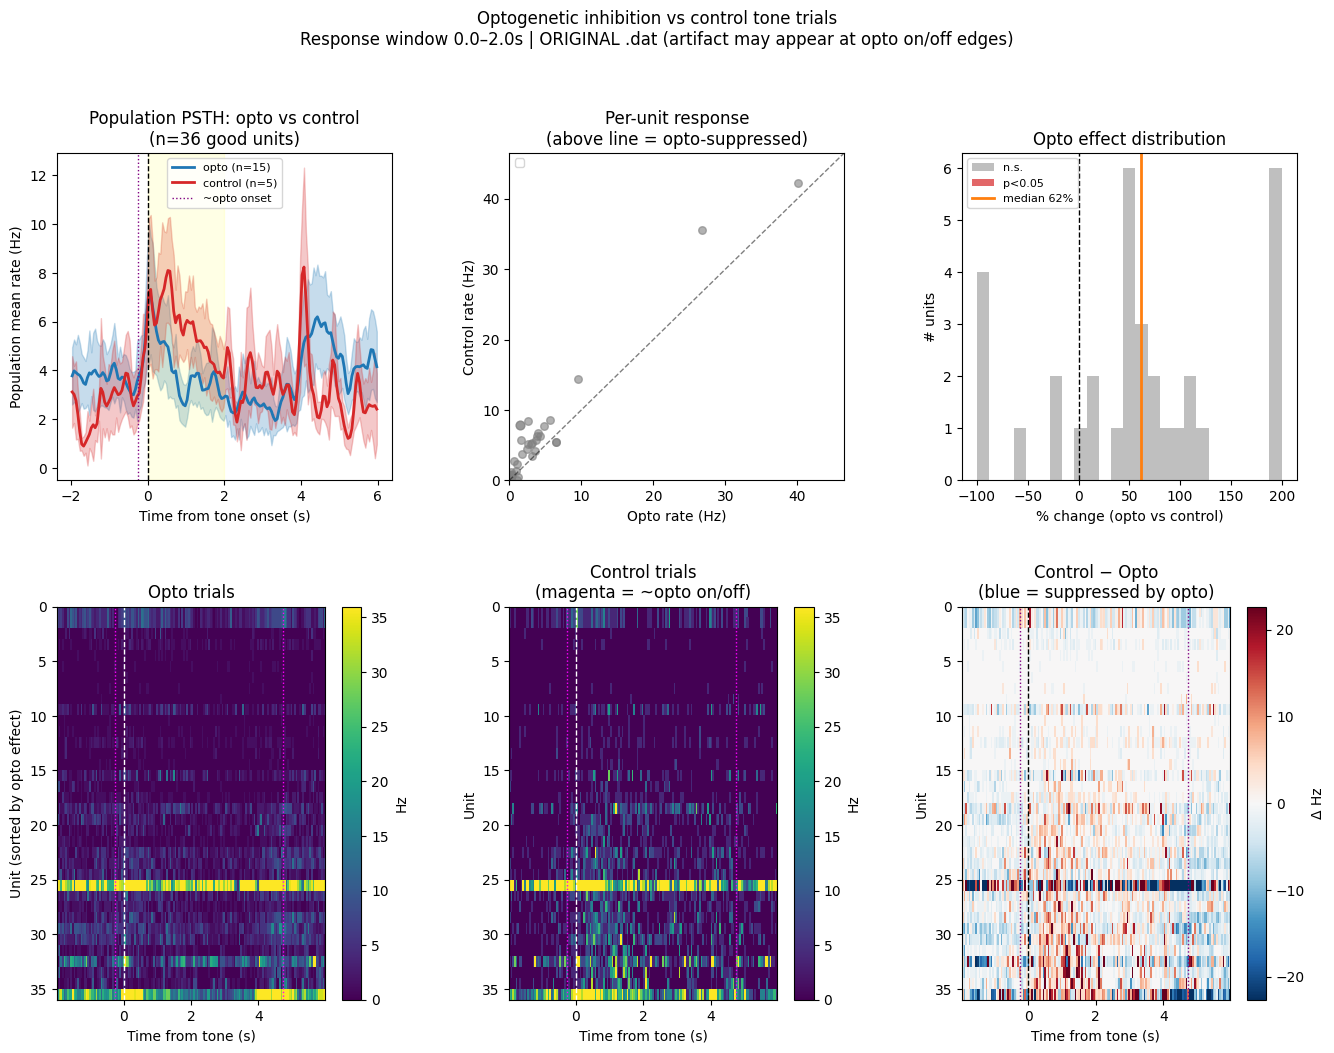


Saved → opto_vs_control_tone_9.png

===== SUMMARY =====
Opto: 5 trials, Control: 15 trials
Good units: 36
Sig. suppressed by opto (p<0.05): 0
Sig. enhanced by opto (p<0.05):   3
Median % change: 61.5%
Mean Δ rate: +1.711 Hz

NOTE: original .dat — edge transients at ~-0.26s and ~+4.74s
may be opto artifact, not spiking. Sustained dip between = real.

===== OPTO COMPARISON COMPLETE =====



In [47]:
# ============================================================
# OPTO vs CONTROL TONE-TRIAL FIRING COMPARISON
# ============================================================
# Compares per-unit firing around tone onset: 5 opto trials vs
# all 34 control (non-opto) tones. Uses drop-robust opto timing
# via Cell B's frame_canonical_times.
#
# Runs on ORIGINAL continuous.dat sort (artifact may be visible).
# Visualizations: (1) population mean PSTH, (2) per-unit heatmap.
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy import stats

print("\n===== OPTO vs CONTROL TONE COMPARISON =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
analysis_folder = Path(
    r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\2026-03-17_14-26-00_experiment1_recording1_analysis"
)
RESULTS_CSV = r"G:\Kevin\2026-03-17_14-26-00\Results.csv"

TONE_PIN = 4
LED_THRESHOLD = 200
OPTO_TONE_MATCH_TOL_S = 0.5
CAMERA_BLOCK = 0   # Cell B saved this as block0

# Windows relative to TONE onset
WIN_PRE   = 2.0
WIN_POST  = 6.0     # past the 5s opto pulse to capture recovery
RESPONSE_WIN = (0.0, 2.0)    # quantification window (matches 5s opto)
BASELINE_WIN = (-2.0, -0.5)  # pre-opto baseline (opto starts ~-0.26s)
BIN_SIZE  = 0.050
SMOOTH_SIGMA_BINS = 1

N_CONTROL = 15  # None = use all control tones
# ------------------------------------------------------------

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# 1. IDENTIFY OPTO TRIALS (drop-robust)
# ------------------------------------------------------------
tone_times = np.sort(np.load(analysis_folder / "ttls" / f"TTL_Pin_{TONE_PIN}.npy"))
print(f"Total tones (pin {TONE_PIN}): {len(tone_times)}")

df = pd.read_csv(RESULTS_CSV)
fluor = df['Mean1'].values
opto_on = fluor > LED_THRESHOLD
transitions = np.diff(opto_on.astype(int))
onset_frames = np.where(transitions == 1)[0] + 1

frame_canonical_times = np.load(
    analysis_folder / "camera_alignment" / f"frame_canonical_times_block{CAMERA_BLOCK}.npy"
)
assert len(frame_canonical_times) == len(df), \
    f"Frame mismatch: {len(frame_canonical_times)} vs {len(df)}"
opto_onset_times = frame_canonical_times[onset_frames[onset_frames < len(frame_canonical_times)]]

# Match opto onsets → nearest tone
opto_tone_idx = []
for t_opto in opto_onset_times:
    dists = np.abs(tone_times - t_opto)
    nearest = np.argmin(dists)
    if dists[nearest] <= OPTO_TONE_MATCH_TOL_S:
        opto_tone_idx.append(nearest)
opto_tone_idx = np.array(sorted(set(opto_tone_idx)))
opto_tone_times = tone_times[opto_tone_idx]

control_tone_idx = np.array([i for i in range(len(tone_times))
                             if i not in set(opto_tone_idx)])
control_tone_times = tone_times[control_tone_idx]

if N_CONTROL is not None and N_CONTROL < len(control_tone_times):
    # nearest-in-time to opto trials
    keep = []
    for t_opto in opto_tone_times:
        order = np.argsort(np.abs(control_tone_times - t_opto))
        for idx in order:
            if idx not in keep:
                keep.append(idx)
                break
    while len(keep) < N_CONTROL:
        remaining = [i for i in range(len(control_tone_times)) if i not in keep]
        # add the control trial closest to any opto trial
        best = min(remaining,
                   key=lambda i: np.min(np.abs(opto_tone_times - control_tone_times[i])))
        keep.append(best)
    control_tone_times = control_tone_times[sorted(keep)]

print(f"Opto trials: {len(opto_tone_times)}")
print(f"Control trials: {len(control_tone_times)}")

# ------------------------------------------------------------
# 2. LOAD GOOD UNITS
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"Good units: {len(good_units)}")

# ------------------------------------------------------------
# 3. PER-TRIAL PSTH
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])

def psth_per_trial(spk, events):
    out = np.zeros((len(events), len(centers)))
    for e_i, t in enumerate(events):
        rel = spk[(spk >= t - WIN_PRE) & (spk < t + WIN_POST)] - t
        h, _ = np.histogram(rel, bins=edges)
        out[e_i] = h / BIN_SIZE
    return out

opto_psth_by_unit = np.zeros((len(good_units), len(centers)))
ctrl_psth_by_unit = np.zeros((len(good_units), len(centers)))
opto_resp_means = np.zeros(len(good_units))
ctrl_resp_means = np.zeros(len(good_units))
diffs = np.zeros(len(good_units))
pct_changes = np.zeros(len(good_units))
pvals = np.zeros(len(good_units))

for ui, u in enumerate(good_units):
    spk = good_spikes[int(u)]
    opto_psth = psth_per_trial(spk, opto_tone_times)
    ctrl_psth = psth_per_trial(spk, control_tone_times)

    opto_psth_by_unit[ui] = opto_psth.mean(axis=0)
    ctrl_psth_by_unit[ui] = ctrl_psth.mean(axis=0)

    opto_resp = opto_psth[:, response_mask].mean(axis=1)
    ctrl_resp = ctrl_psth[:, response_mask].mean(axis=1)
    opto_resp_means[ui] = opto_resp.mean()
    ctrl_resp_means[ui] = ctrl_resp.mean()
    diffs[ui] = opto_resp.mean() - ctrl_resp.mean()
    pct_changes[ui] = (diffs[ui] / (ctrl_resp.mean() + 1e-9)) * 100

    if len(opto_resp) >= 2 and len(ctrl_resp) >= 2:
        try:
            _, pvals[ui] = stats.mannwhitneyu(opto_resp, ctrl_resp,
                                              alternative='two-sided')
        except ValueError:
            pvals[ui] = np.nan
    else:
        pvals[ui] = np.nan

# ------------------------------------------------------------
# 4. FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35,
                      height_ratios=[1, 1.2])

# --- Panel A: population mean PSTH ---
ax = fig.add_subplot(gs[0, 0])
opto_pop = gaussian_filter1d(opto_psth_by_unit.mean(axis=0), SMOOTH_SIGMA_BINS)
ctrl_pop = gaussian_filter1d(ctrl_psth_by_unit.mean(axis=0), SMOOTH_SIGMA_BINS)
opto_sem = opto_psth_by_unit.std(axis=0) / np.sqrt(len(good_units))
ctrl_sem = ctrl_psth_by_unit.std(axis=0) / np.sqrt(len(good_units))
ax.plot(centers, ctrl_pop, color="C0", lw=2,
        label=f"opto (n={len(control_tone_times)})")
ax.fill_between(centers, ctrl_pop - ctrl_sem, ctrl_pop + ctrl_sem,
                color="C0", alpha=0.25)
ax.plot(centers, opto_pop, color="C3", lw=2,
        label=f"control (n={len(opto_tone_times)})")
ax.fill_between(centers, opto_pop - opto_sem, opto_pop + opto_sem,
                color="C3", alpha=0.25)
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.axvline(-0.26, color="purple", lw=1, linestyle=":", label="~opto onset")
ax.axvspan(RESPONSE_WIN[0], RESPONSE_WIN[1], color="yellow", alpha=0.1)
ax.set_xlabel("Time from tone onset (s)")
ax.set_ylabel("Population mean rate (Hz)")
ax.set_title(f"Population PSTH: opto vs control\n(n={len(good_units)} good units)")
ax.legend(fontsize=8)

# --- Panel B: per-unit scatter ---
ax = fig.add_subplot(gs[0, 1])
sig = pvals < 0.05
ax.scatter(ctrl_resp_means[~sig], opto_resp_means[~sig], s=30,
           color="gray", alpha=0.6)
ax.scatter(ctrl_resp_means[sig], opto_resp_means[sig], s=40,
           color="gray", alpha=0.8)
lim = max(ctrl_resp_means.max(), opto_resp_means.max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5)
ax.set_xlabel("Opto rate (Hz)")
ax.set_ylabel("Control rate (Hz)")
ax.set_title("Per-unit response\n(above line = opto-suppressed)")
ax.legend(fontsize=8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)

# --- Panel C: % change distribution ---
ax = fig.add_subplot(gs[0, 2])
pc = np.clip(pct_changes, -100, 200)
ax.hist(pc[~sig], bins=25, color="gray", alpha=0.5, label="n.s.")
ax.hist(pc[sig], bins=25, color="C3", alpha=0.7, label="p<0.05")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.axvline(np.median(pct_changes), color="C1", lw=2,
           label=f"median {np.median(pct_changes):.0f}%")
ax.set_xlabel("% change (opto vs control)")
ax.set_ylabel("# units")
ax.set_title("Opto effect distribution")
ax.legend(fontsize=8)

# --- Panel D + E: per-unit heatmaps (sorted by opto effect) ---
order = np.argsort(diffs)
vmax = np.percentile(np.abs(np.concatenate([opto_psth_by_unit.ravel(),
                                            ctrl_psth_by_unit.ravel()])), 98)

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(ctrl_psth_by_unit[order], aspect="auto",
               extent=[centers[0], centers[-1], len(good_units), 0],
               cmap="viridis", vmin=0, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="white", lw=1, linestyle="--")
ax.axvline(-0.26, color="magenta", lw=1, linestyle=":")
ax.axvline(4.74, color="magenta", lw=1, linestyle=":")
ax.set_xlabel("Time from tone (s)")
ax.set_ylabel("Unit (sorted by opto effect)")
ax.set_title("Opto trials")
plt.colorbar(im, ax=ax, label="Hz")

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(opto_psth_by_unit[order], aspect="auto",
               extent=[centers[0], centers[-1], len(good_units), 0],
               cmap="viridis", vmin=0, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="white", lw=1, linestyle="--")
ax.axvline(-0.26, color="magenta", lw=1, linestyle=":")
ax.axvline(4.74, color="magenta", lw=1, linestyle=":")
ax.set_xlabel("Time from tone (s)")
ax.set_ylabel("Unit")
ax.set_title("Control trials\n(magenta = ~opto on/off)")
plt.colorbar(im, ax=ax, label="Hz")

# --- Panel F: difference heatmap ---
ax = fig.add_subplot(gs[1, 2])
diff_psth = opto_psth_by_unit - ctrl_psth_by_unit
dmax = np.percentile(np.abs(diff_psth), 98)
im = ax.imshow(diff_psth[order], aspect="auto",
               extent=[centers[0], centers[-1], len(good_units), 0],
               cmap="RdBu_r", vmin=-dmax, vmax=dmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.axvline(-0.26, color="purple", lw=1, linestyle=":")
ax.axvline(4.74, color="purple", lw=1, linestyle=":")
ax.set_xlabel("Time from tone (s)")
ax.set_ylabel("Unit")
ax.set_title("Control − Opto\n(blue = suppressed by opto)")
plt.colorbar(im, ax=ax, label="Δ Hz")

plt.suptitle(
    f"Optogenetic inhibition vs control tone trials\n"
    f"Response window {RESPONSE_WIN[0]}–{RESPONSE_WIN[1]}s | "
    f"ORIGINAL .dat (artifact may appear at opto on/off edges)",
    fontsize=12, y=1.01
)
plt.tight_layout()

out_path = analysis_folder / "qc" / "opto_vs_control_tone.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"opto_vs_control_tone_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path.name}")

# ------------------------------------------------------------
# 5. SAVE + SUMMARY
# ------------------------------------------------------------
np.savez(
    analysis_folder / "qc" / "opto_vs_control_results.npz",
    units=good_units,
    opto_resp_mean=opto_resp_means,
    ctrl_resp_mean=ctrl_resp_means,
    diff=diffs,
    pct_change=pct_changes,
    pval=pvals,
    opto_tone_times=opto_tone_times,
    control_tone_times=control_tone_times,
    opto_psth=opto_psth_by_unit,
    ctrl_psth=ctrl_psth_by_unit,
    centers=centers,
    response_win=np.array(RESPONSE_WIN),
)

n_supp = int(((pvals < 0.05) & (diffs < 0)).sum())
n_enh = int(((pvals < 0.05) & (diffs > 0)).sum())
print(f"\n===== SUMMARY =====")
print(f"Opto: {len(opto_tone_times)} trials, Control: {len(control_tone_times)} trials")
print(f"Good units: {len(good_units)}")
print(f"Sig. suppressed by opto (p<0.05): {n_supp}")
print(f"Sig. enhanced by opto (p<0.05):   {n_enh}")
print(f"Median % change: {np.median(pct_changes):.1f}%")
print(f"Mean Δ rate: {diffs.mean():+.3f} Hz")
print(f"\nNOTE: original .dat — edge transients at ~-0.26s and ~+4.74s")
print(f"may be opto artifact, not spiking. Sustained dip between = real.")

print("\n===== OPTO COMPARISON COMPLETE =====\n")